In [1]:
from __future__ import print_function
import sys, os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

import ROOT
from ROOT import gROOT, gStyle, gDirectory, gPad

import filepath 
import portROOT2pd
from pdgid import pdgid_dict
import plot_utils
import constants
import log_parser

geometry = "nucap"
tag = "MuBeamStopVD"
pklname = geometry+"_MuBeamStopVD_genealogy_2file_no_genealogy.pkl"

In [2]:
ROOT.EnableImplicitMT()
fileList = ['/pnfs/mu2e/scratch/users/yongyiwu/workflow/nucap.MDC2020s11r0000.s2_ana_MuBeamStopVD/outstage/26050774/00/00000/nts.yongyiwu.MDC2020s21r0000.nucap.001218_00000000.root',
            '/pnfs/mu2e/scratch/users/yongyiwu/workflow/nucap.MDC2020s11r0000.s2_ana_MuBeamStopVD/outstage/26050774/00/00001/nts.yongyiwu.MDC2020s21r0000.nucap.001218_00000001.root']
df_particles = pd.DataFrame()
df_source = pd.DataFrame()
for ii, filename in enumerate(fileList):
    rdfp_ = ROOT.RDataFrame("ParticleBackTracer/ttree", filename)
    dfp_ = pd.DataFrame(rdfp_.AsNumpy())
    # adding "tag" "fileno" "r" "weight", all p's and E multiply by 1000
    dfp_.insert(0, 'tag', tag)
    dfp_.insert(1, 'fileno', ii)
    dfp_['weight'] = 1
    dfp_['r'] = np.sqrt((dfp_['x']-constants.VD101_X)**2+(dfp_['y'])**2)
    dfp_['px'] = dfp_['px']*1000 # so in keV
    dfp_['py'] = dfp_['py']*1000 # so in keV
    dfp_['pz'] = dfp_['pz']*1000 # so in keV
    dfp_['startpx'] = dfp_['startpx']*1000 # so in keV
    dfp_['startpy'] = dfp_['startpy']*1000 # so in keV
    dfp_['startpz'] = dfp_['startpz']*1000 # so in keV
    dfp_['E'] = dfp_['E']*1000 # so in keV
    df_particles = pd.concat([df_particles,dfp_], ignore_index=True)
    
    rdfs_ = ROOT.RDataFrame("ParticleBackTracer/ttree_source", filename)
    dfs_ = pd.DataFrame(rdfs_.AsNumpy())
    dfs_.insert(0, 'tag', tag)
    dfs_.insert(1, 'fileno', ii)
    dfs_['pdgId'] = dfp_['pdgId']
    df_source = pd.concat([df_source,dfs_], ignore_index=True)
with open(pklname, 'wb') as f:
    pickle.dump(df_particles, f)
    pickle.dump(df_source, f)    

In [3]:
with open(pklname, 'rb') as f:
    df_particles = pickle.load(f)
    df_source = pickle.load(f)
display(df_particles)
display(df_source)
print("weights:", np.sort(df_particles['weight'].unique()))
print("VDs:", np.sort(df_particles['virtualdetectorId'].unique()))
print("z coordinates of events:", np.sort(df_particles['z'].unique()))
print("creation codes:", np.sort(df_particles['creationCode'].unique()))

,tag,fileno,E,creationCode,index,pdgId,px,py,pz,startpx,...,startx,starty,startz,time,virtualdetectorId,x,y,z,weight,r
0,MuBeamStopVD,0,34341.532141,114,0,11,-16580.750923,-23635.737233,19515.850610,14112.775803,...,-3939.036814,55.235475,5782.095412,1232.642128,10,-3933.613708,130.337364,6275.999996,1,133.659269
1,MuBeamStopVD,0,150.740021,115,1,22,46.576419,-52.075978,133.571268,-52.178711,...,-3916.298522,-52.651725,5804.370459,1994.657141,10,-3617.490884,-3.861366,6275.999996,1,286.535136
2,MuBeamStopVD,0,36306.940524,114,2,11,-18212.200348,-20979.757865,24155.021481,-4309.432507,...,-3830.922256,15.389102,5515.403713,250.925552,10,-3946.728227,40.788481,6275.999996,1,59.071157
3,MuBeamStopVD,0,70.330664,16,3,22,-54.864345,-0.787680,43.996426,-54.864343,...,-3896.851433,64.013094,6226.539819,250.938575,10,-3958.529175,63.127595,6275.999996,1,83.417769
4,MuBeamStopVD,0,200.580737,115,4,22,131.212512,-77.893057,130.186713,131.212518,...,-3888.537476,25.372653,6204.293379,797.327901,10,-3816.265851,-17.530709,6275.999996,1,89.468468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174552,MuBeamStopVD,1,65.728641,113,85208,22,-49.154658,-25.694524,35.268474,-49.154658,...,-3897.724783,-37.938517,6137.613903,287.004796,10,-4090.597347,-138.758439,6275.999996,1,232.534888
174553,MuBeamStopVD,1,93.642559,115,85209,22,-36.736903,-20.652255,83.623042,-36.736902,...,-3879.377674,-17.433343,5515.401381,614.583902,10,-4213.520474,-205.277219,6275.999996,1,371.404981
174554,MuBeamStopVD,1,44525.898641,114,85210,11,18557.080641,-6367.315591,40535.824543,-19418.581009,...,-3861.959361,-30.458247,6004.286931,1689.960348,10,-3873.110645,-123.532309,6275.999996,1,127.335712
174555,MuBeamStopVD,1,199.558262,113,85211,22,99.208670,-3.628220,173.112610,-207.005039,...,-3861.959361,-30.458247,6004.286931,196.763457,10,-4252.450016,450.498830,6275.999996,1,569.531921


,tag,fileno,creationCode,index,parentendtime,parentpdgId,starttime,x,y,z,pdgId
0,MuBeamStopVD,0,114,0,341.781525,13,1229.544312,-3939.036814,55.235475,5782.095412,11
1,MuBeamStopVD,0,115,1,201.226135,13,1986.679688,-3916.298522,-52.651725,5804.370459,22
2,MuBeamStopVD,0,114,2,211.825836,13,246.623245,-3830.922256,15.389102,5515.403713,11
3,MuBeamStopVD,0,16,3,294.270355,11,250.674850,-3896.851433,64.013094,6226.539819,22
4,MuBeamStopVD,0,115,4,159.197998,13,796.959351,-3888.537476,25.372653,6204.293379,22
...,...,...,...,...,...,...,...,...,...,...,...
174552,MuBeamStopVD,1,113,85208,286.144501,13,286.144501,-3897.724783,-37.938517,6137.613903,22
174553,MuBeamStopVD,1,115,85209,331.248749,13,611.742859,-3879.377674,-17.433343,5515.401381,22
174554,MuBeamStopVD,1,114,85210,194.322601,13,1688.953857,-3861.959361,-30.458247,6004.286931,11
174555,MuBeamStopVD,1,113,85211,194.322601,13,194.322601,-3861.959361,-30.458247,6004.286931,22


weights: [1]
VDs: [10]
z coordinates of events: [6275.999996   6276.01708439 6276.01767821 6276.019996   6276.019996  ]
creation codes: [  2  12  13  16  17  21  31  35  40  58  68  72  74  97 101 109 113 114
 115]



$e^{+}$ from MuBeamStopVD:  30
$e^{-}$ from MuBeamStopVD:  35989
$\gamma$ from MuBeamStopVD:  108512
$n$ from MuBeamStopVD:  28205
$p$ from MuBeamStopVD:  1666
$D$ from MuBeamStopVD:  93
$T$ from MuBeamStopVD:  19
$^{4}He$ from MuBeamStopVD:  42
$^{27}Mg$ from MuBeamStopVD:  1


/exp/mu2e/data/users/yongyiwu/stm_analysis/plot_utils.py:22: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(4,3))


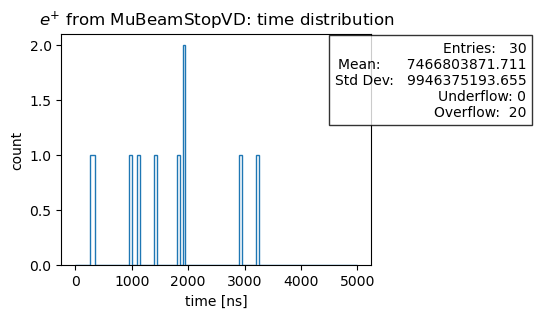

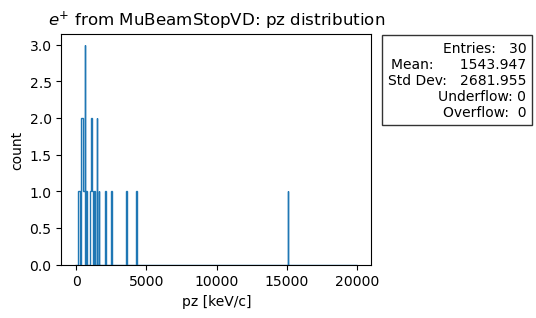

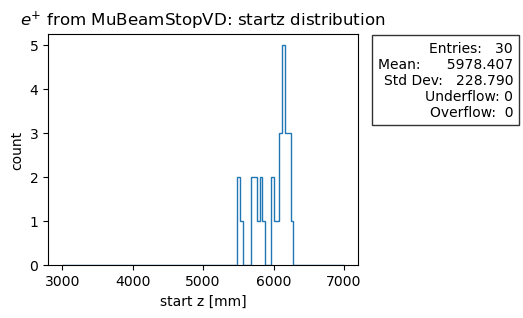

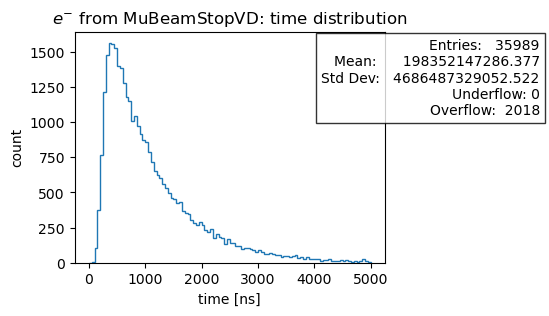

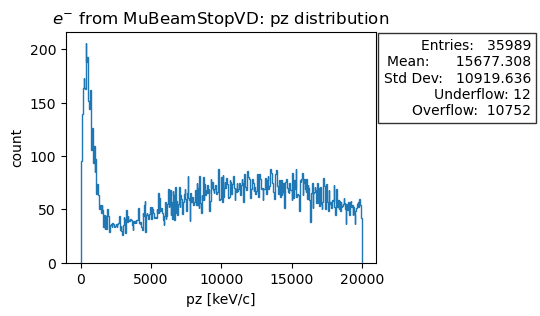

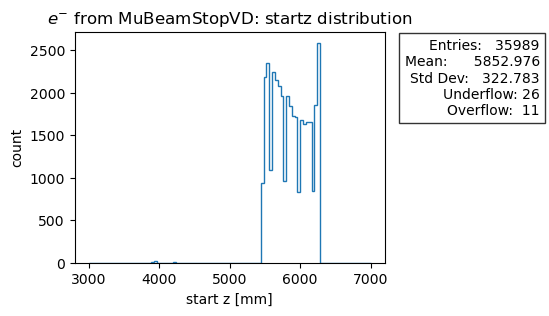

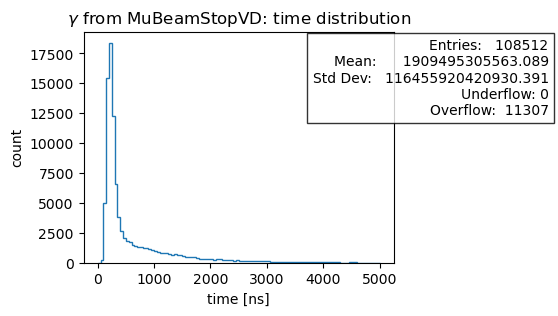

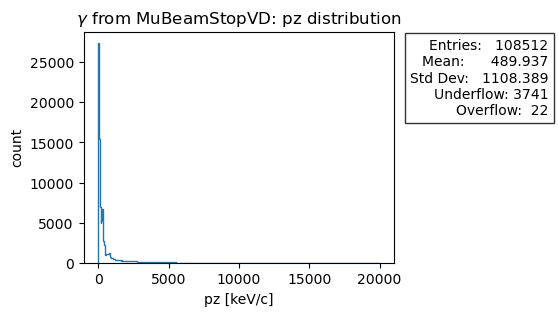

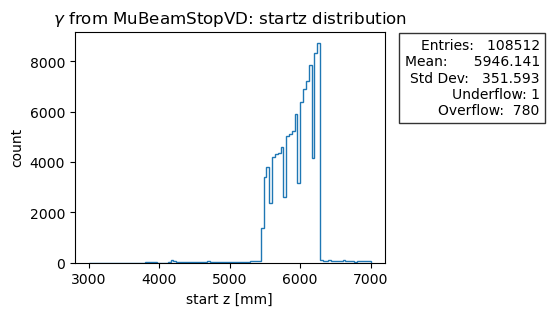

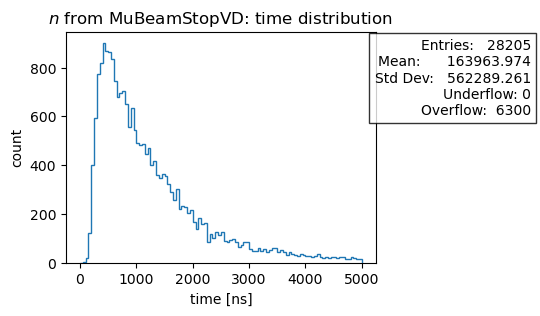

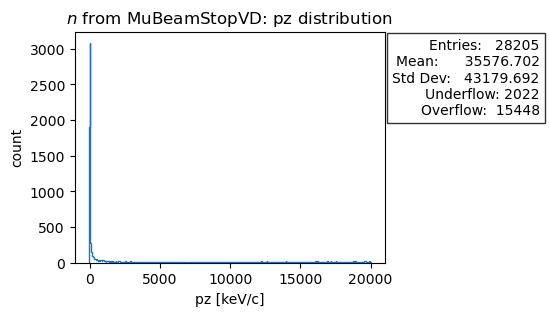

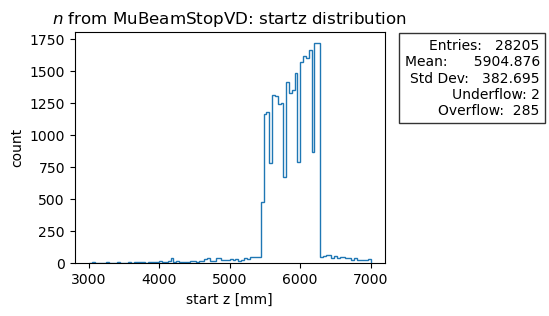

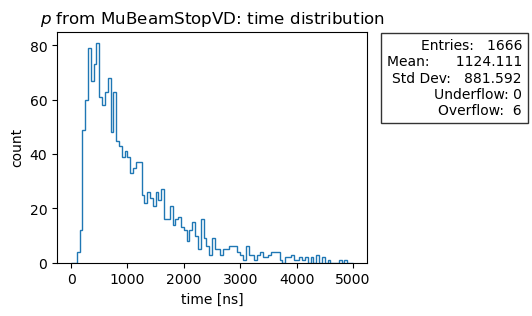

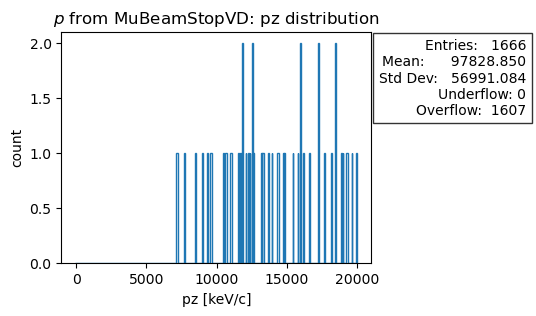

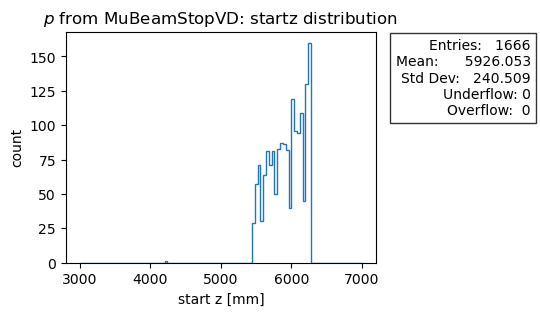

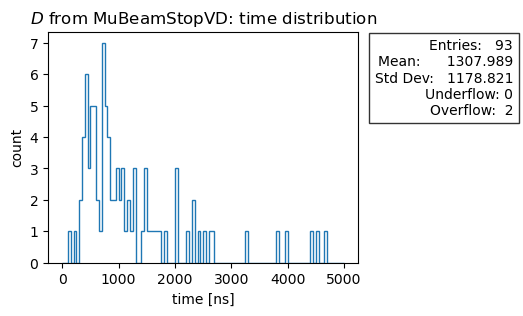

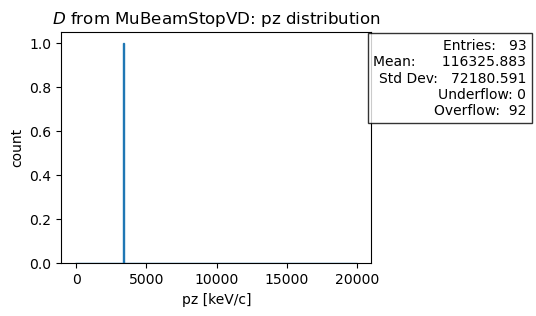

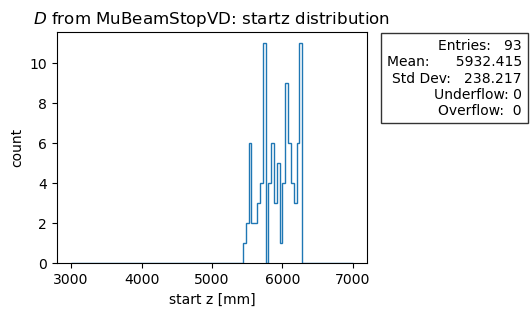

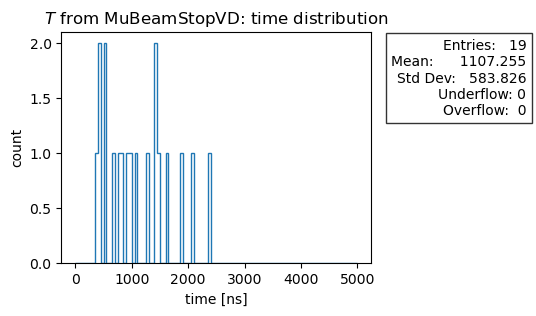

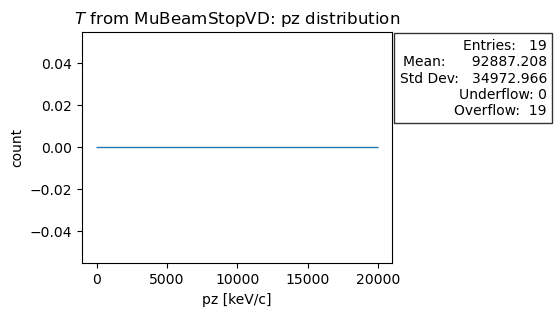

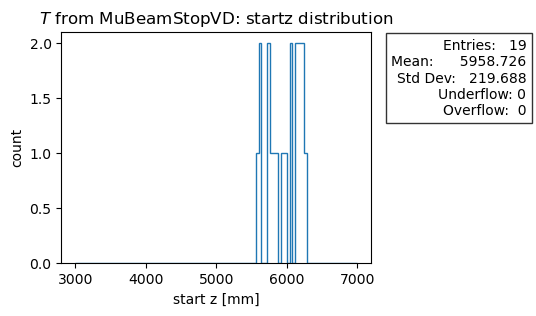

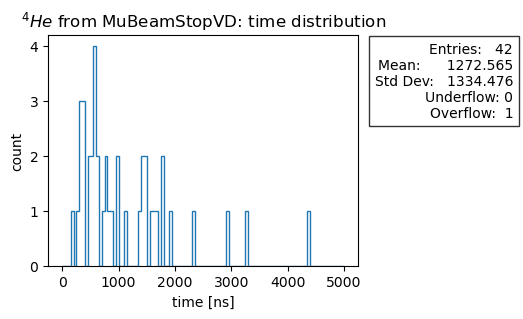

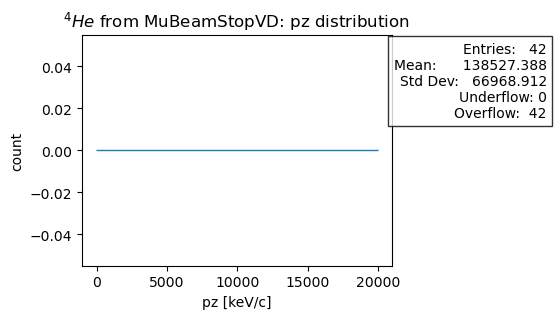

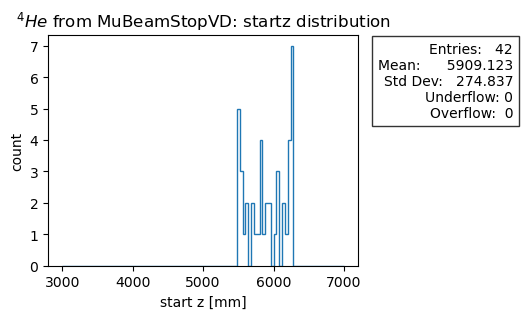

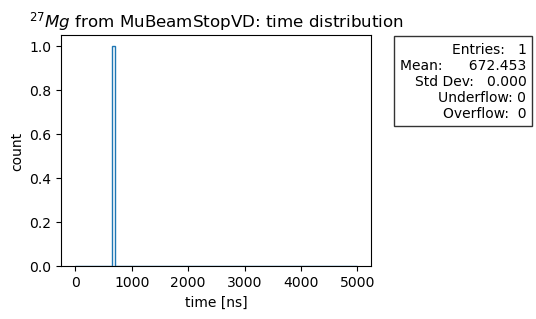

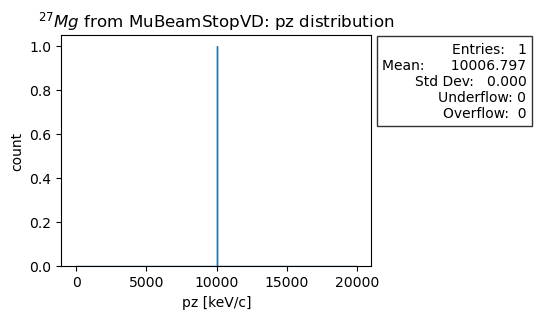

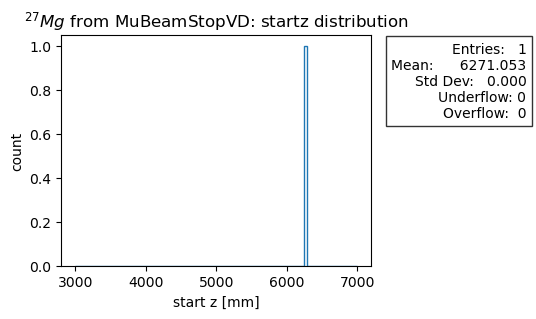

In [4]:
item_list = ['time', 'pz', 'startz']
title_list = [item+' distribution' for item in item_list]
xlabel_list = ['time [ns]', 'pz [keV/c]', 'start z [mm]']
ylabel_list = ['count' for item in item_list]

df_by_pdgid = {}

print("")
list_of_pdgId = np.sort(df_particles['pdgId'].unique())
for pdgId in list_of_pdgId:
    mydf1 = df_particles.query("pdgId==%i"%(pdgId)).reset_index(drop=True)
    mydf2 = df_source.query("pdgId==%i"%(pdgId)).reset_index(drop=True)
    df_by_pdgid.update({pdgId:[mydf1, mydf2]})
    group_name = pdgid_dict[pdgId]+' from '+tag+': '
    print(group_name, len(mydf1))
    for index, item in enumerate(item_list):
        fig, ax = plot_utils.single_hist(mydf1, item, [group_name+title_list[index], xlabel_list[index], ylabel_list[index]]) 

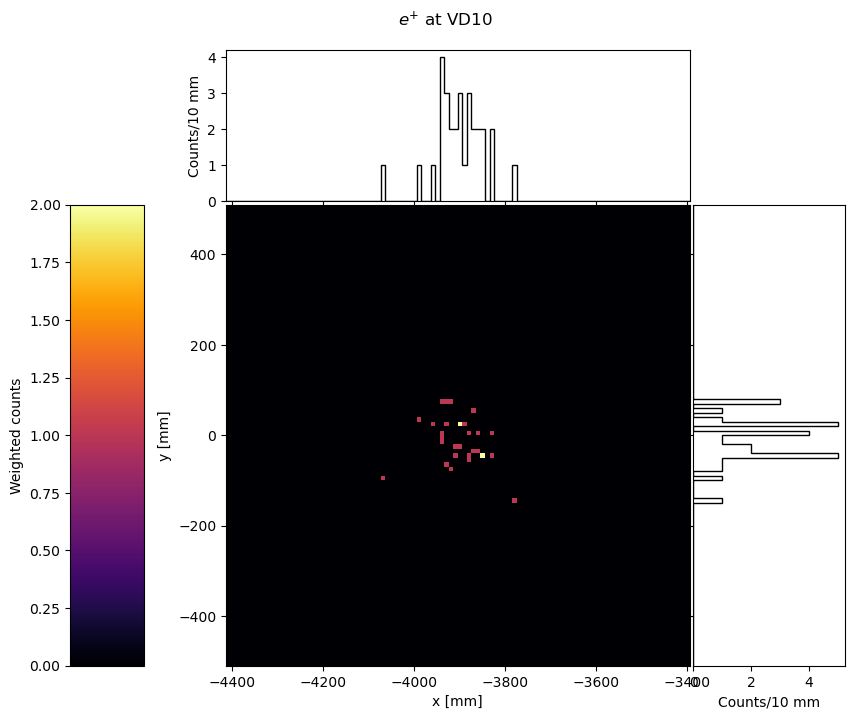

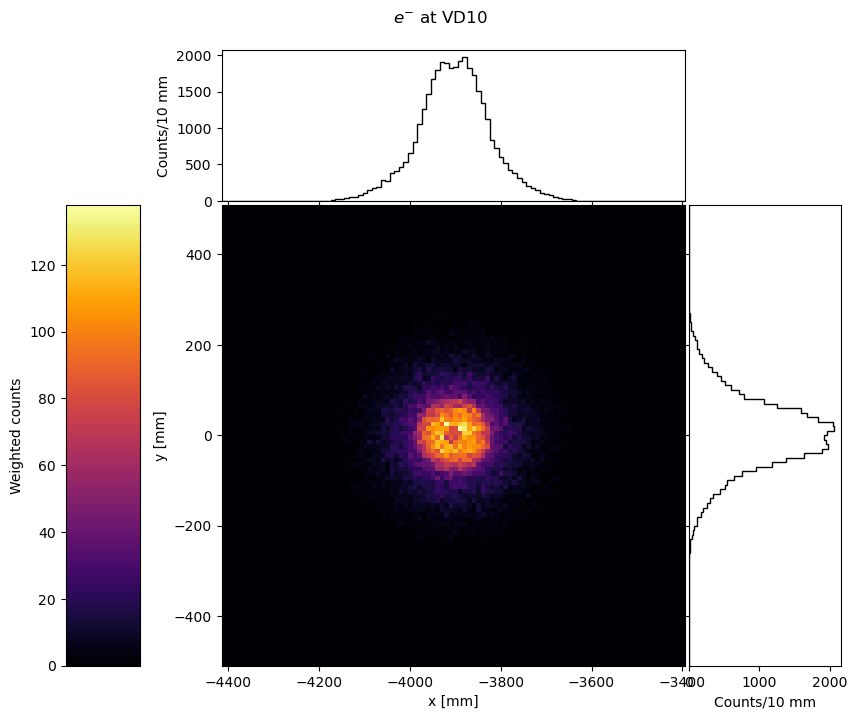

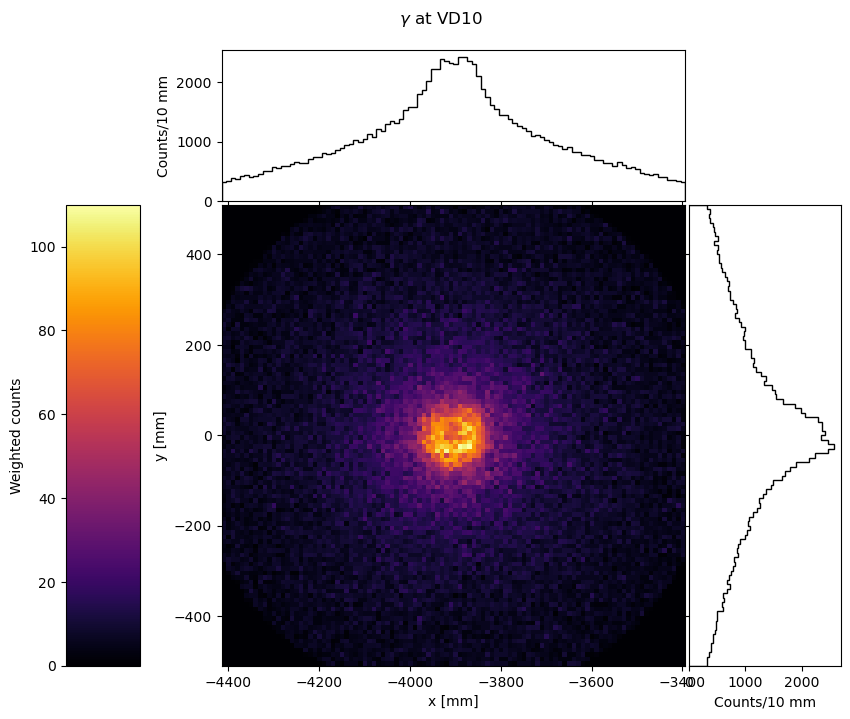

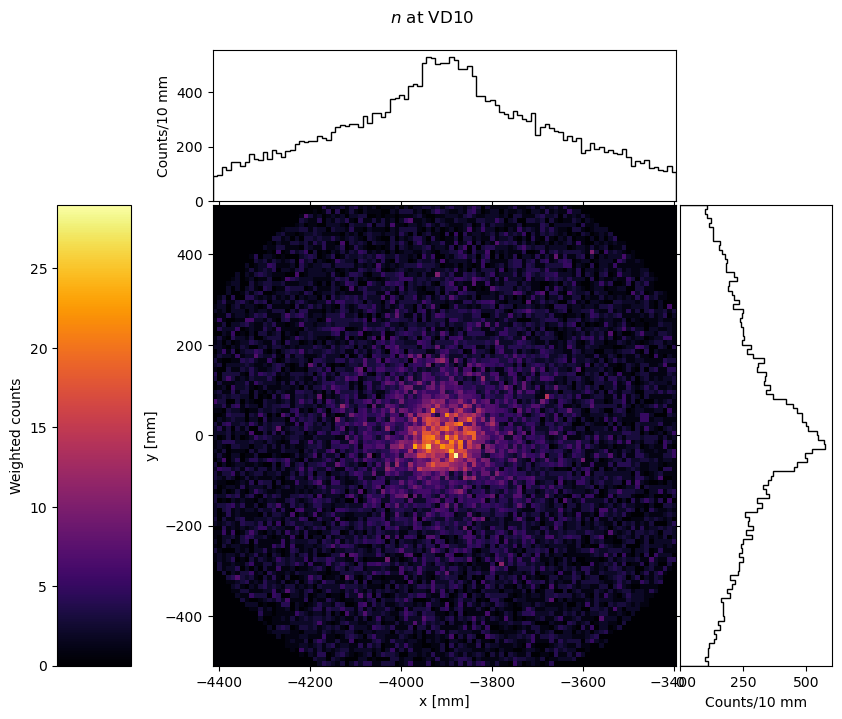

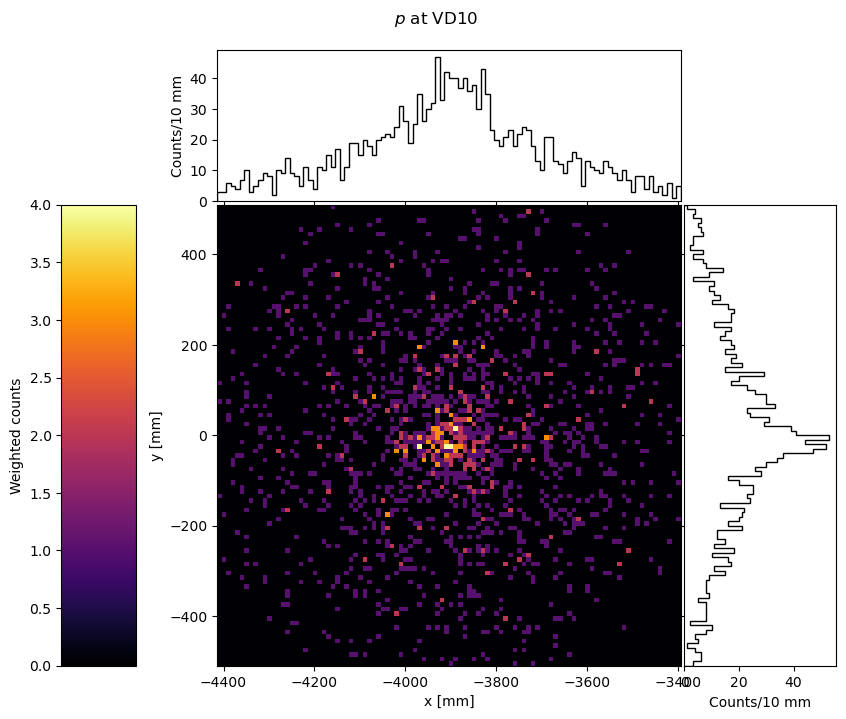

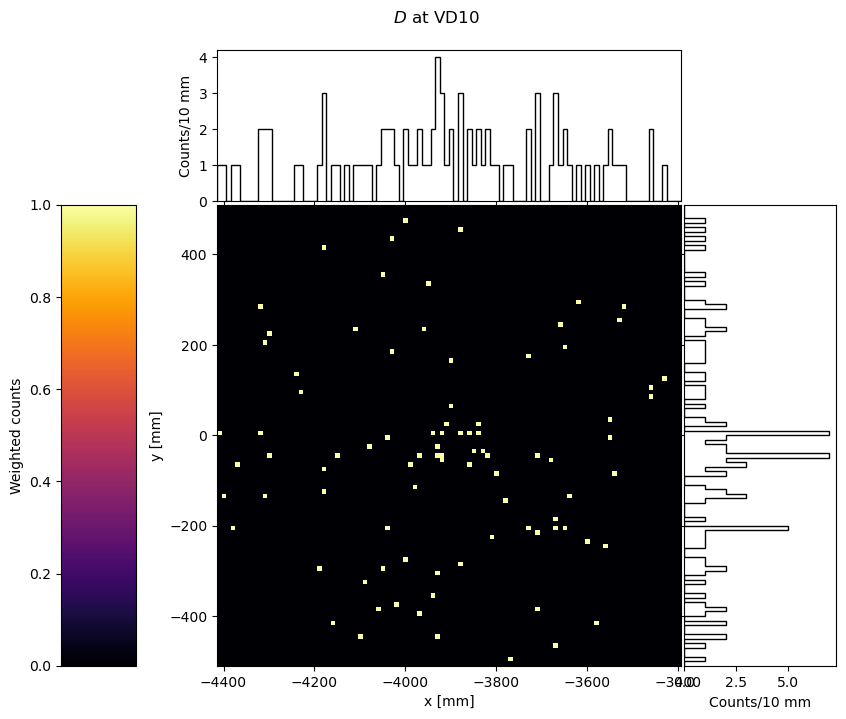

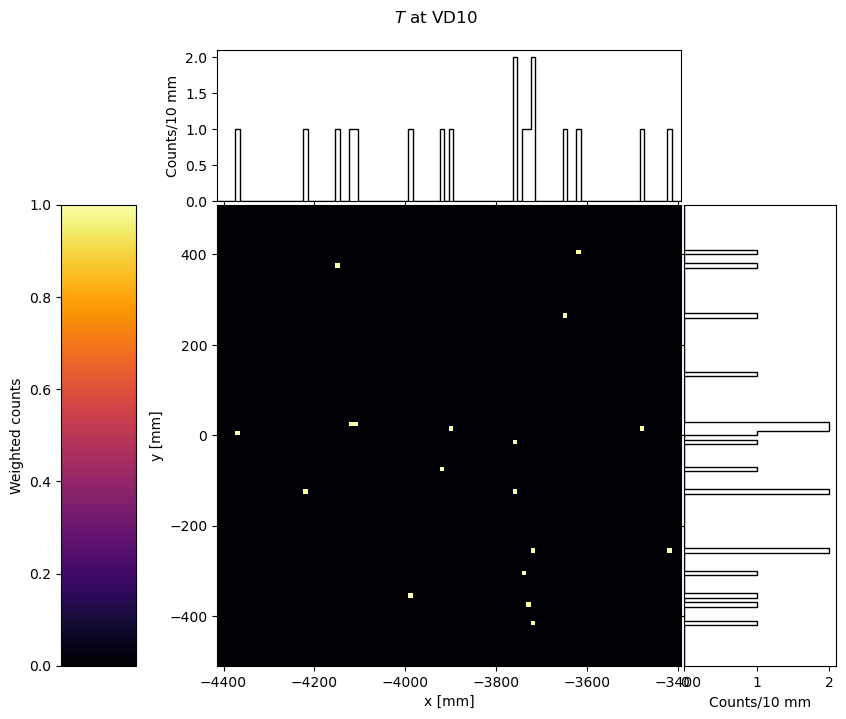

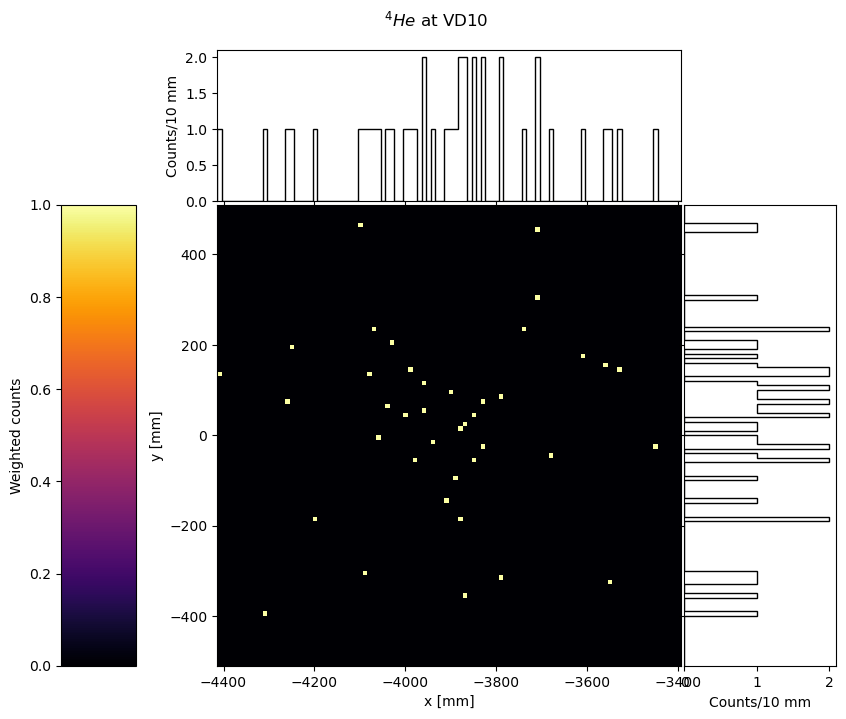

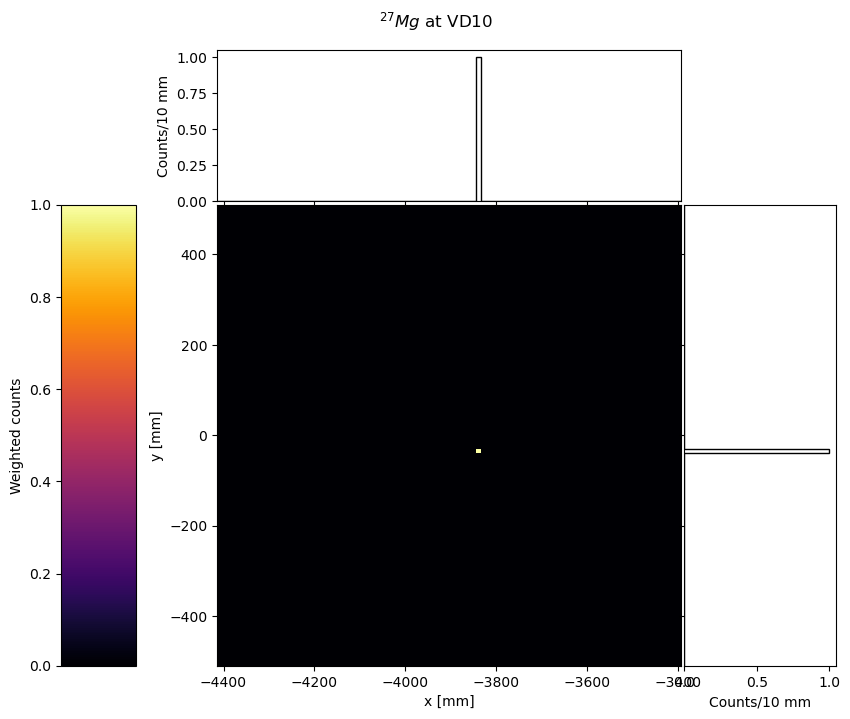

In [5]:
for pdgId in list_of_pdgId:
    fig, ax2d, axX, axY = plot_utils.particle_space_dist(df_by_pdgid[pdgId][0], pdgid_dict[pdgId]+" at VD10") 
    plt.show()

===================== -11 30
------------------------------------------------------------------------------


tag                       MuBeamStopVD
fileno                               0
E                          1373.666405
creationCode                        74
index                              206
pdgId                              -11
px                          -802.68367
py                          728.103702
pz                         1454.787747
startpx                   -1192.455888
startpy                   -1556.008339
startpz                    2062.471867
starttime                 3677507840.0
startx                    -3932.397923
starty                       -0.113484
startz                     6159.840442
time                 3677507748.295743
virtualdetectorId                   10
x                         -3941.925851
y                            -0.815301
z                          6275.999996
weight                               1
r                            37.934614
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode               74
index                     206
parentendtime     1830.592407
parentpdgId        1000120230
starttime        3677507840.0
x                -3932.397923
y                   -0.113484
z                 6159.840442
pdgId                     -11
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,1000120230,-3932.398315,-0.114008,6159.841157
1,13,-3893.720248,60.045408,4179.000000
2,13,3859.765402,-16.782904,-4851.900731
3,-211,3918.076681,-0.118421,-6109.909616
4,2212,3930.858542,-0.426420,-6057.829087


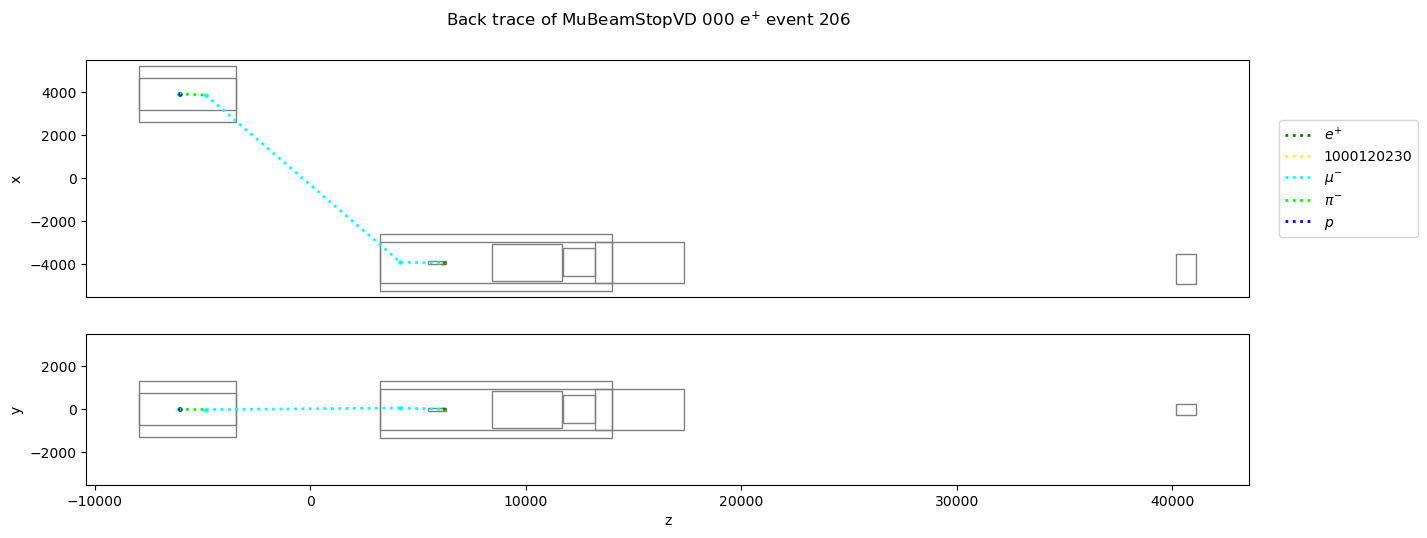

===================== 11 35989
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    34341.532141
creationCode                  114
index                           0
pdgId                          11
px                  -16580.750923
py                  -23635.737233
pz                    19515.85061
startpx              14112.775803
startpy             -27029.922485
startpz              18074.073792
starttime             1229.544312
startx               -3939.036814
starty                  55.235475
startz                5782.095412
time                  1232.642128
virtualdetectorId              10
x                    -3933.613708
y                      130.337364
z                     6275.999996
weight                          1
r                      133.659269
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              114
index                       0
parentendtime      341.781525
parentpdgId                13
starttime         1229.544312
x                -3939.036814
y                   55.235475
z                 5782.095412
pdgId                      11
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3930.180050,2.647638,4179.000000
1,13,3908.092899,-8.814348,-5817.207173
2,-211,3912.589980,-1.034086,-6128.268982
3,2212,3930.267800,-0.941995,-6057.681799


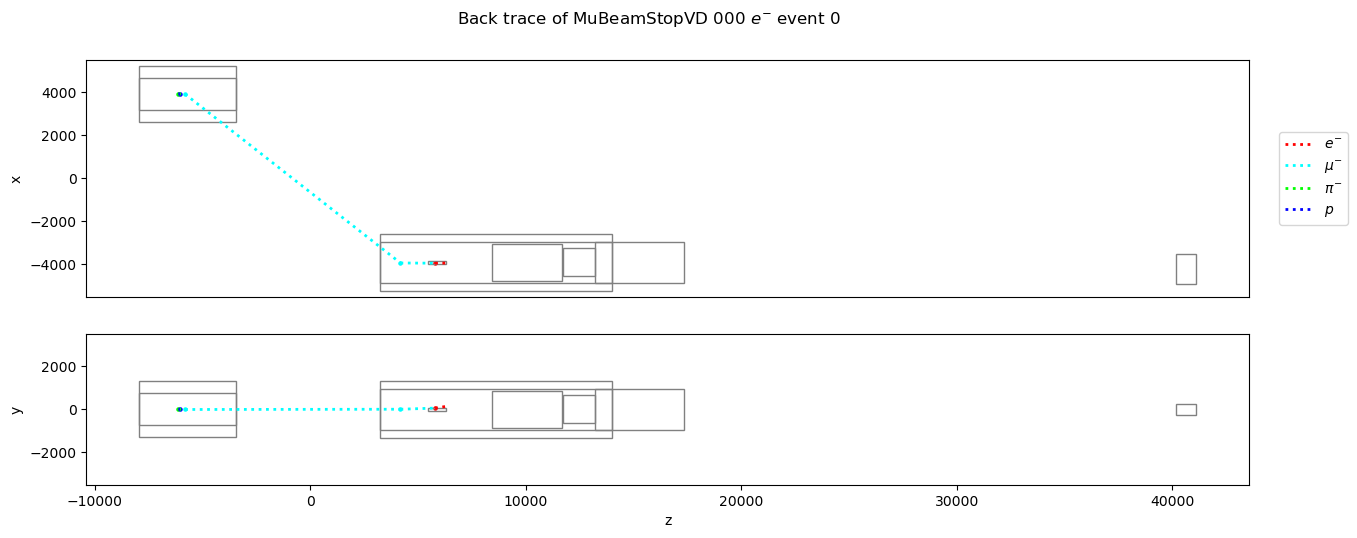

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3703.952504
creationCode                  114
index                       19911
pdgId                          11
px                    -1844.15178
py                   -3583.972685
pz                    1122.024748
startpx              -7761.821747
startpy             -21134.872437
startpz               2000.804424
starttime             3470.422119
startx               -3962.897345
starty                  23.491265
startz                5759.916196
time                  3494.587829
virtualdetectorId              10
x                     -3897.61371
y                       32.626099
z                     6275.999996
weight                          1
r                       33.245256
Name: 4000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              114
index                   19911
parentendtime      188.458908
parentpdgId                13
starttime         3470.422119
x                -3962.897345
y                   23.491265
z                 5759.916196
pdgId                      11
Name: 4000, dtype: object

,pdgId,startx,starty,startz
0,13,-3912.805928,18.437794,4179.000000
1,13,3883.987932,5.021917,-4164.792119
2,-211,3889.577064,1.541473,-6228.219539
3,2212,3930.404879,0.553485,-6057.715977


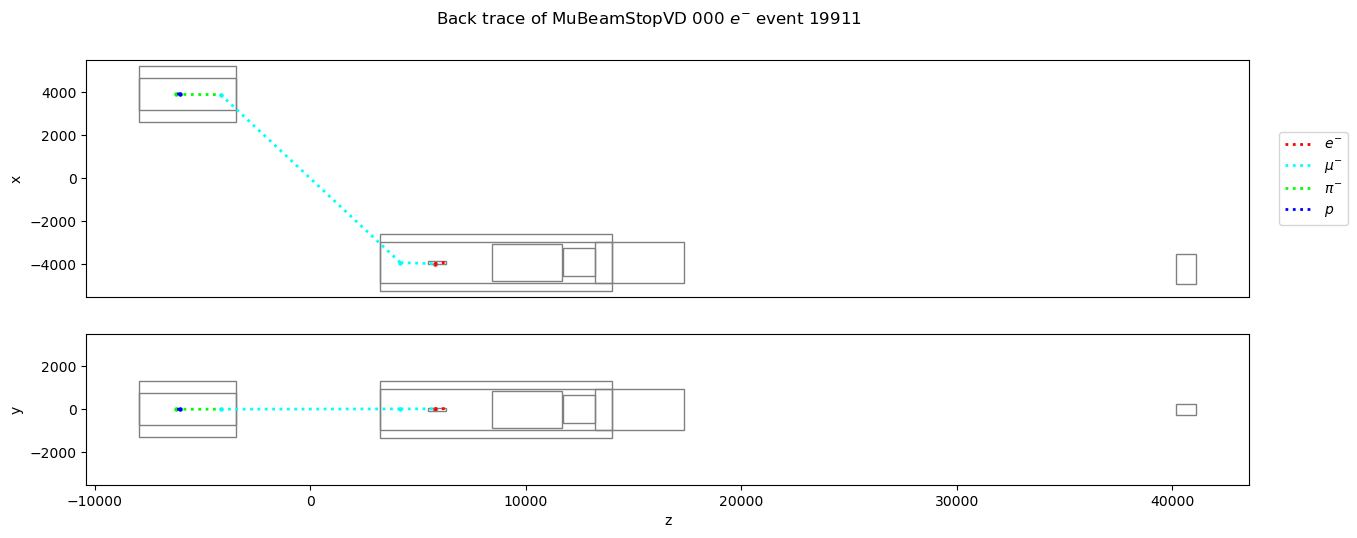

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     44666.90212
creationCode                  114
index                       39262
pdgId                          11
px                    3255.095139
py                   30906.988717
pz                    32786.33901
startpx             -35927.589417
startpy               -5701.38073
startpz              28199.048996
starttime             1960.525269
startx               -3873.098912
starty                  42.874913
startz                5537.626009
time                  1964.206157
virtualdetectorId              10
x                    -3789.803588
y                      -41.544491
z                     6275.999996
weight                          1
r                       121.51858
Name: 8000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              114
index                   39262
parentendtime      256.300751
parentpdgId                13
starttime         1960.525269
x                -3873.098912
y                   42.874913
z                 5537.626009
pdgId                      11
Name: 8000, dtype: object

,pdgId,startx,starty,startz
0,13,-3859.405729,55.431494,4179.000000
1,13,3950.896858,9.949491,-5592.881195
2,-211,3894.598711,0.462336,-6196.576056
3,2212,3929.391020,0.346034,-6057.463193


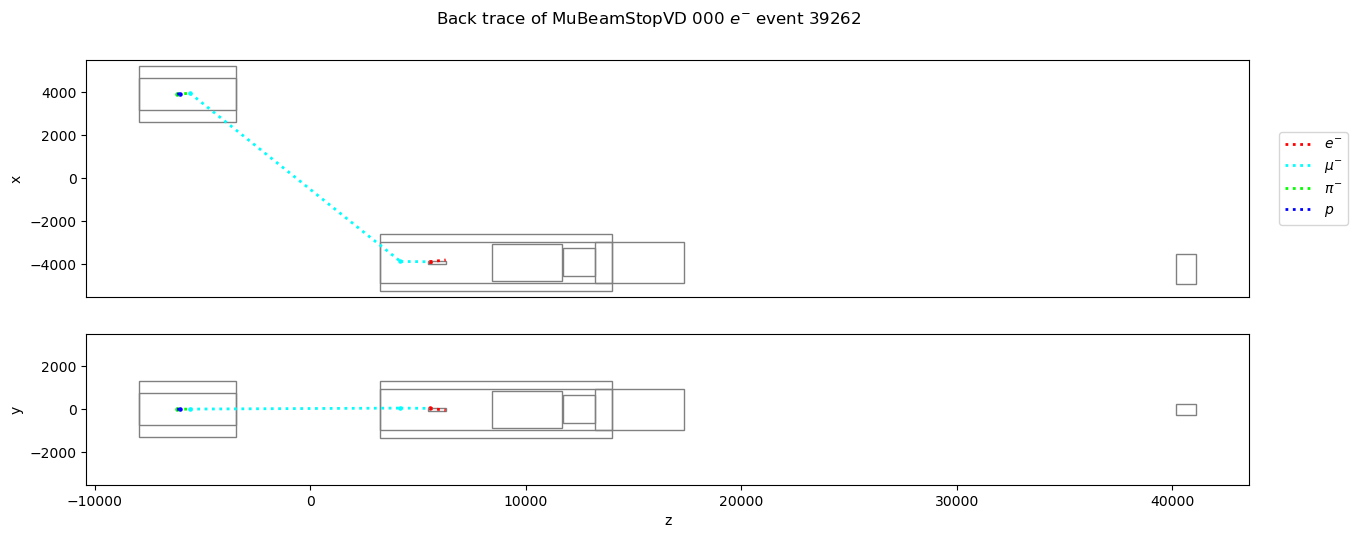

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    22799.653274
creationCode                  114
index                       58184
pdgId                          11
px                    13114.00121
py                   12434.233893
pz                   14715.236494
startpx              16506.633759
startpy             -12075.016975
startpz             -13602.155685
starttime               691.38324
startx               -3868.965909
starty                  -4.741077
startz                5648.737219
time                   756.774368
virtualdetectorId              10
x                    -3808.892711
y                      -27.971275
z                     6275.999996
weight                          1
r                       99.135204
Name: 12000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              114
index                   58184
parentendtime      330.290924
parentpdgId                13
starttime           691.38324
x                -3868.965909
y                   -4.741077
z                 5648.737219
pdgId                      11
Name: 12000, dtype: object

,pdgId,startx,starty,startz
0,13,-3938.628555,17.048081,4179.000000
1,13,3880.792634,22.925824,-5291.933592
2,-211,3923.971083,1.064920,-6078.533568
3,2212,3929.321774,1.063417,-6057.445928


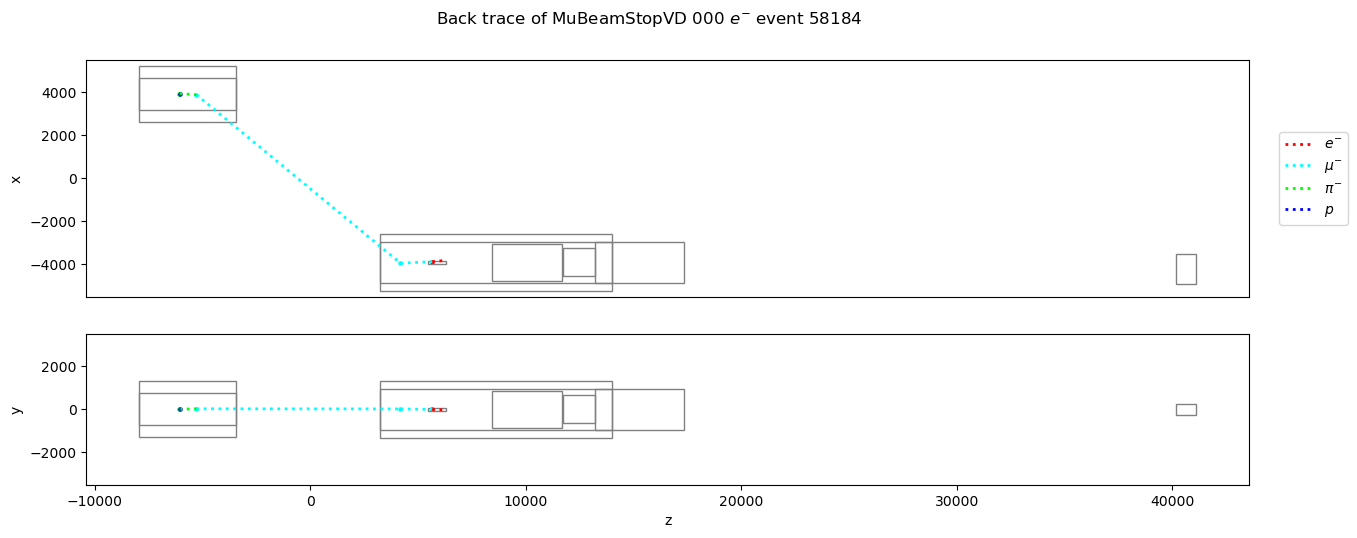

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                    26535.429969
creationCode                  114
index                       77855
pdgId                          11
px                   14940.325988
py                    -6851.97083
pz                   21472.898041
startpx              14714.755058
startpy              14350.561142
startpz              18454.820633
starttime             1300.695679
startx               -3953.049546
starty                 -20.404125
startz                5493.254898
time                  1304.306778
virtualdetectorId              10
x                    -3999.594258
y                      -24.211033
z                     6275.999996
weight                          1
r                       98.612557
Name: 16000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              114
index                   77855
parentendtime       391.14621
parentpdgId                13
starttime         1300.695679
x                -3953.049546
y                  -20.404125
z                 5493.254898
pdgId                      11
Name: 16000, dtype: object

,pdgId,startx,starty,startz
0,13,-3996.339498,-7.296510,4179.000000
1,13,3881.057872,-30.581551,-5967.161994
2,-211,3904.127059,2.523418,-6162.104154
3,2112,3910.158511,-1.467794,-6137.399014
4,2212,3929.718719,-0.860665,-6057.544898


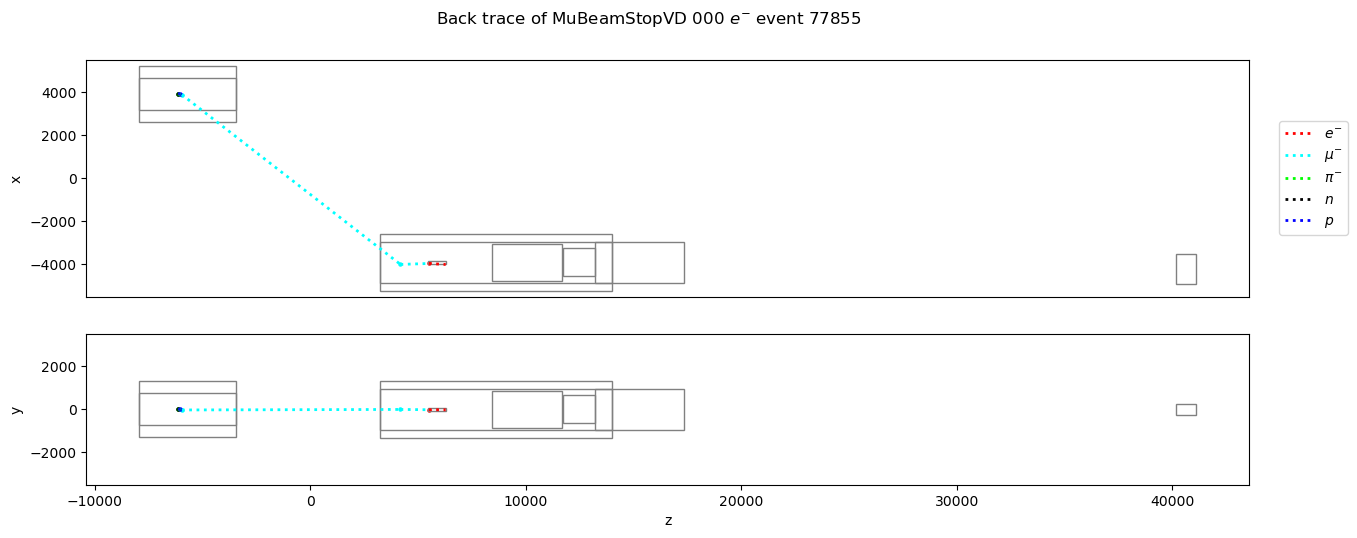

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                     3887.875589
creationCode                   17
index                        8205
pdgId                          11
px                   -4215.701745
py                     825.891183
pz                     796.705418
startpx               -527.474105
startpy              -4893.862247
startpz               1817.430496
starttime              2251.06665
startx               -3857.934171
starty                  15.881079
startz                6115.400566
time                  2252.665214
virtualdetectorId              10
x                     -3841.41616
y                        29.48616
z                     6275.999996
weight                          1
r                       69.182155
Name: 20000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              114
index                    8205
parentendtime      119.471832
parentpdgId                13
starttime         2251.058105
x                -3857.501058
y                    18.41984
z                 6115.453099
pdgId                      11
Name: 20000, dtype: object

,pdgId,startx,starty,startz
0,11,-3857.501058,18.419840,6115.453099
1,13,-3878.347160,27.143193,4179.000000
2,13,3927.396808,-16.930920,-3304.976364
3,-211,3916.100498,0.176626,-6118.065449
4,2212,3931.087736,0.241165,-6057.886232


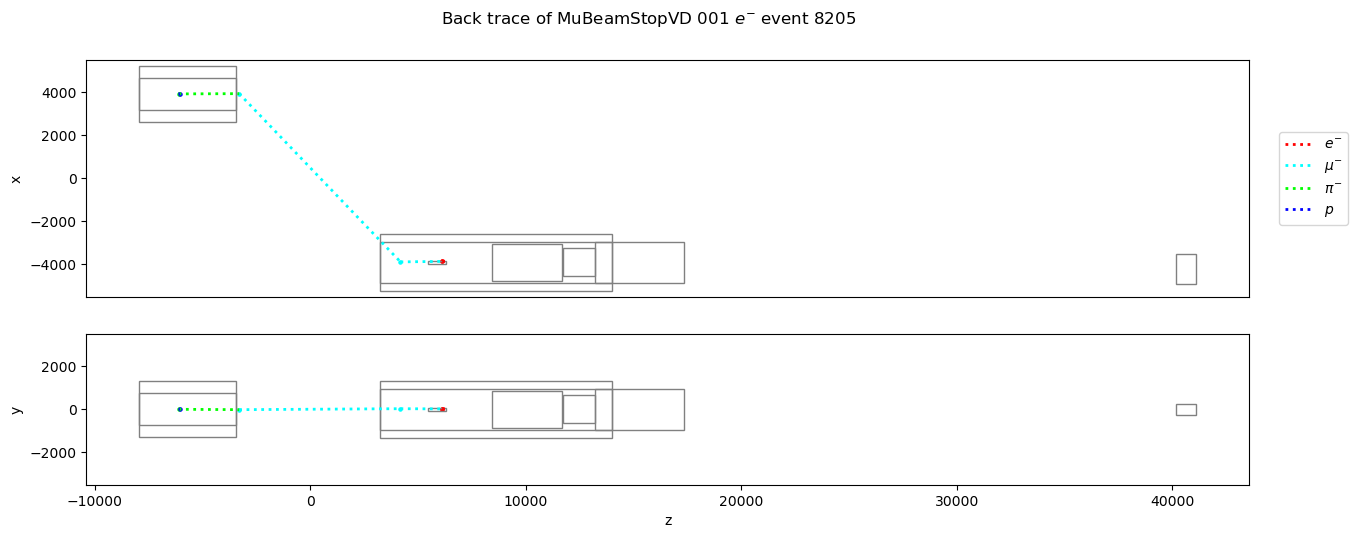

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                    37832.734229
creationCode                  114
index                       27105
pdgId                          11
px                    9740.479147
py                   36899.947081
pz                     3673.92468
startpx               2084.574699
startpy             -40022.628784
startpz               -602.388203
starttime             3342.765625
startx               -3868.506217
starty                  31.402897
startz                 6248.82437
time                  3349.391233
virtualdetectorId              10
x                    -3687.984653
y                       16.883258
z                     6275.999996
weight                          1
r                      216.674121
Name: 24000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              114
index                   27105
parentendtime      150.979645
parentpdgId                13
starttime         3342.765625
x                -3868.506217
y                   31.402897
z                  6248.82437
pdgId                      11
Name: 24000, dtype: object

,pdgId,startx,starty,startz
0,13,-3887.646439,18.845769,4179.000000
1,13,3922.565667,22.246015,-3571.434622
2,-211,3911.824268,0.248401,-6138.705107
3,2212,3931.495629,-0.169413,-6057.987931


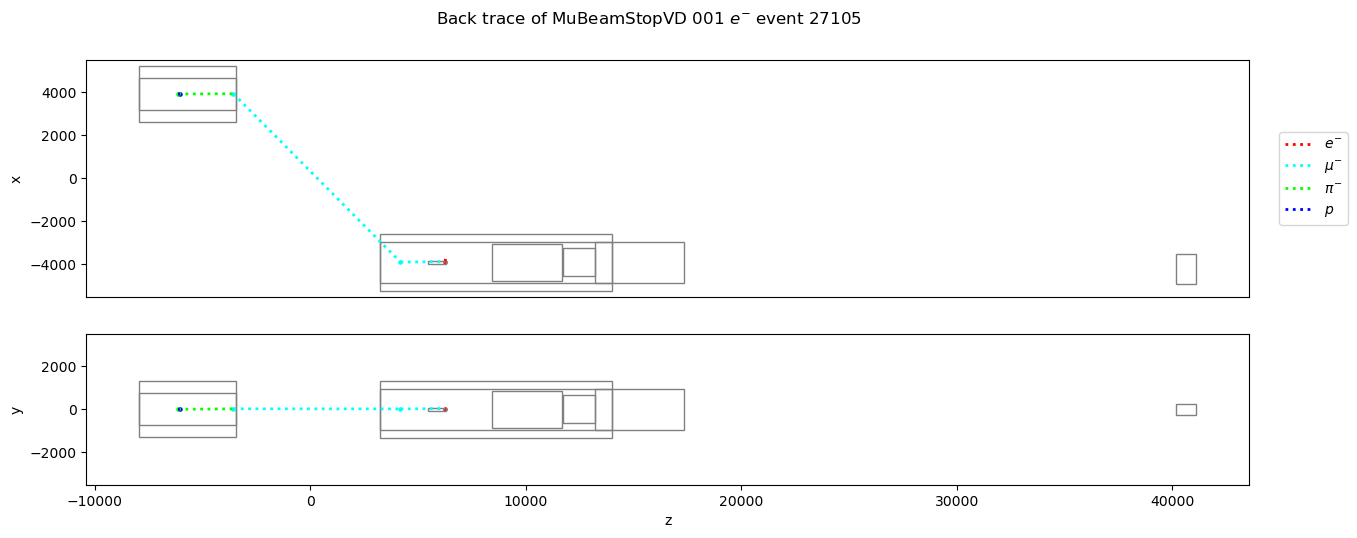

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                    29187.924983
creationCode                  114
index                       46131
pdgId                          11
px                  -26467.101187
py                   -8884.652107
pz                   10115.358236
startpx               7524.171829
startpy             -30014.196396
startpz              -6146.286011
starttime              925.864563
startx               -3853.226653
starty                  47.207851
startz                5982.073409
time                   944.197688
virtualdetectorId              10
x                    -3804.493567
y                      124.026161
z                     6275.999996
weight                          1
r                      159.009493
Name: 28000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              114
index                   46131
parentendtime      210.304962
parentpdgId                13
starttime          925.864563
x                -3853.226653
y                   47.207851
z                 5982.073409
pdgId                      11
Name: 28000, dtype: object

,pdgId,startx,starty,startz
0,13,-3859.006083,57.671543,4179.000000
1,13,3933.349380,25.812798,-4434.475430
2,-211,3926.206046,0.570695,-6074.120704
3,2212,3930.271455,0.537876,-6057.682710


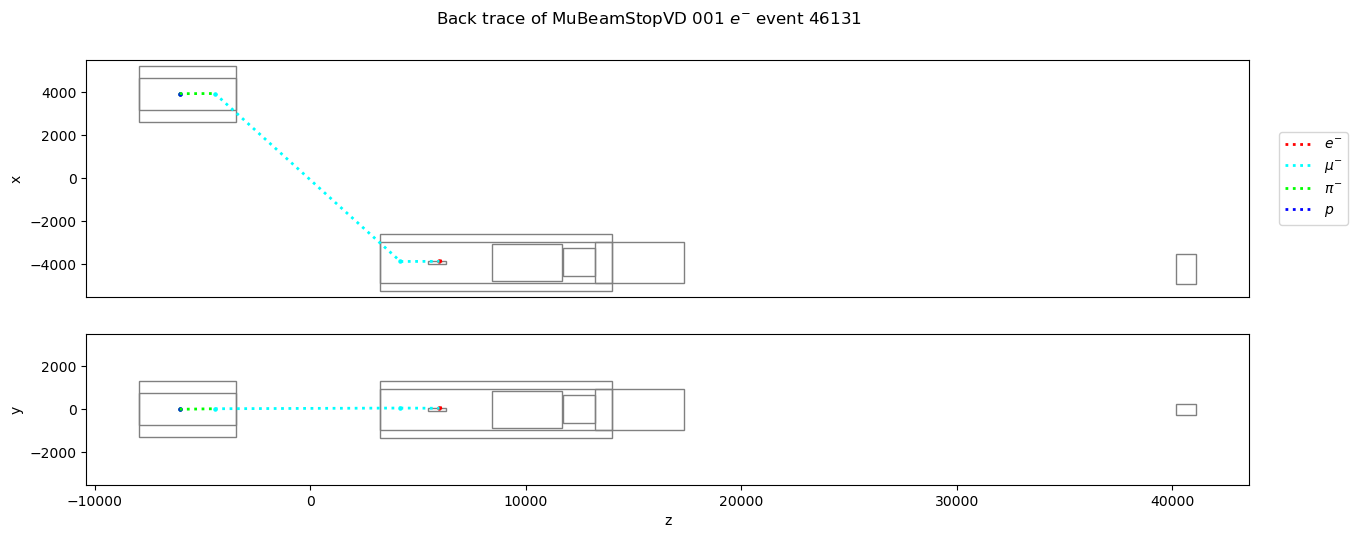

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                     37110.84067
creationCode                  114
index                       65746
pdgId                          11
px                   27886.092724
py                   15086.304748
pz                   20246.257312
startpx              -6518.409729
startpy              32993.942261
startpz              17678.844452
starttime             1195.642578
startx                 -3871.7602
starty                 -38.467468
startz                5782.126811
time                  1198.935628
virtualdetectorId              10
x                    -3911.875662
y                      -120.90425
z                     6275.999996
weight                          1
r                      121.160488
Name: 32000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              114
index                   65746
parentendtime      330.110321
parentpdgId                13
starttime         1195.642578
x                  -3871.7602
y                  -38.467468
z                 5782.126811
pdgId                      11
Name: 32000, dtype: object

,pdgId,startx,starty,startz
0,13,-3903.148934,-56.320369,4179.000000
1,13,3233.845988,46.500337,-985.931543
2,-211,3903.886044,0.970128,-6167.667711
3,2212,3931.613578,0.717146,-6058.017339


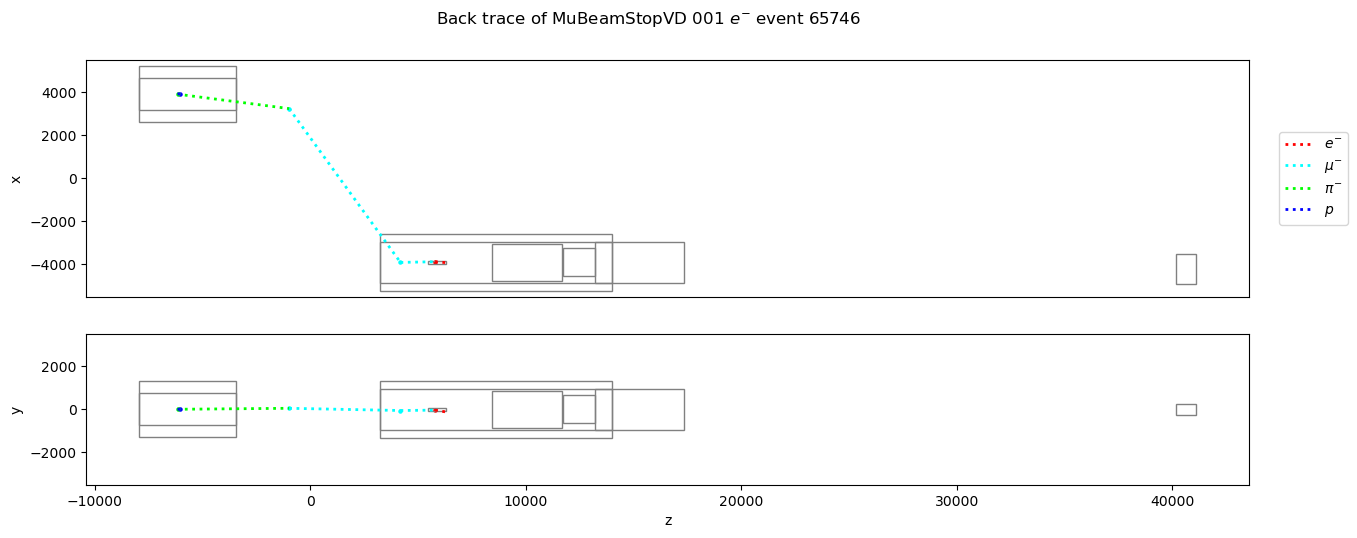

===================== 22 108512
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      150.740021
creationCode                  115
index                           1
pdgId                          22
px                      46.576419
py                     -52.075978
pz                     133.571268
startpx                -52.178711
startpy                199.879855
startpz               -292.067438
starttime             1986.679688
startx               -3916.298522
starty                 -52.651725
startz                5804.370459
time                  1994.657141
virtualdetectorId              10
x                    -3617.490884
y                       -3.861366
z                     6275.999996
weight                          1
r                      286.535136
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                       1
parentendtime      201.226135
parentpdgId                13
starttime         1986.679688
x                -3916.298522
y                  -52.651725
z                 5804.370459
pdgId                      22
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3859.130626,-4.022822,4179.000000
1,13,3928.696081,-8.328269,-4534.467849
2,-211,3927.367844,0.709328,-6069.680945
3,2212,3930.350600,0.714403,-6057.702443


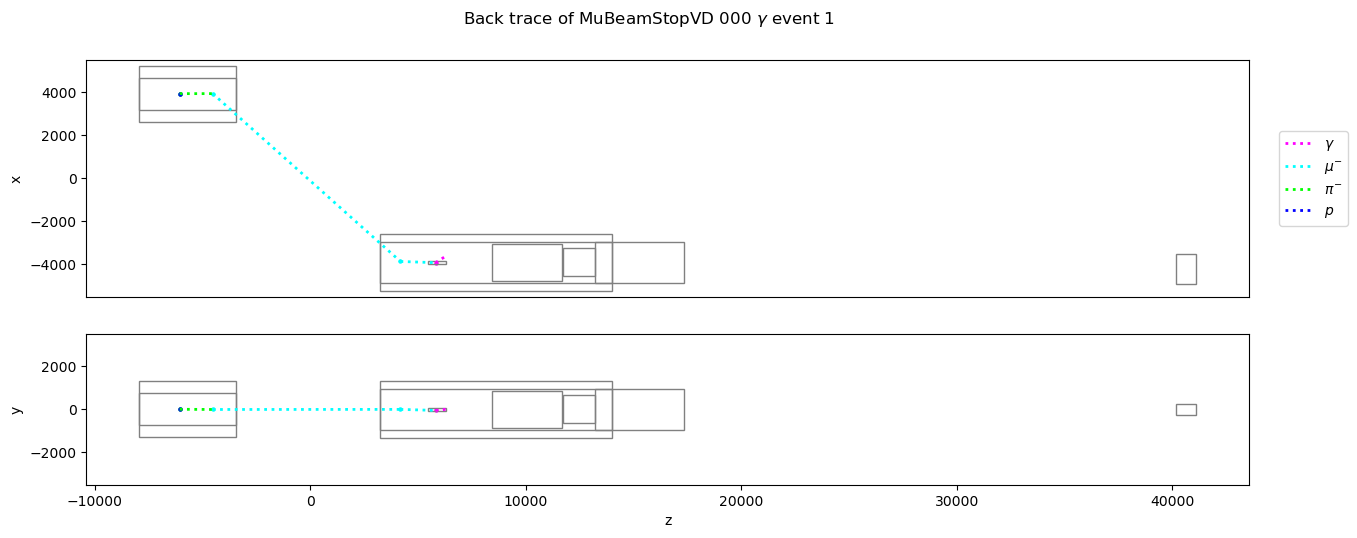

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       1314.0068
creationCode                  115
index                        6321
pdgId                          22
px                    -625.481831
py                     359.519226
pz                    1098.240537
startpx               -625.481844
startpy                359.519213
startpz               1098.240495
starttime             4869.192871
startx                 -3881.5843
starty                 -41.149736
startz                5626.506104
time                  4871.784753
virtualdetectorId              10
x                    -4251.491087
y                      171.468114
z                     6275.999996
weight                          1
r                      387.493703
Name: 4000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                    6321
parentendtime      224.253326
parentpdgId                13
starttime         4869.192871
x                  -3881.5843
y                  -41.149736
z                 5626.506104
pdgId                      22
Name: 4000, dtype: object

,pdgId,startx,starty,startz
0,13,-3905.295596,-55.947075,4179.000000
1,13,3931.084016,-30.358358,-4814.646170
2,-211,3928.790411,1.040480,-6057.461771
3,2212,3928.825251,1.040496,-6057.322131


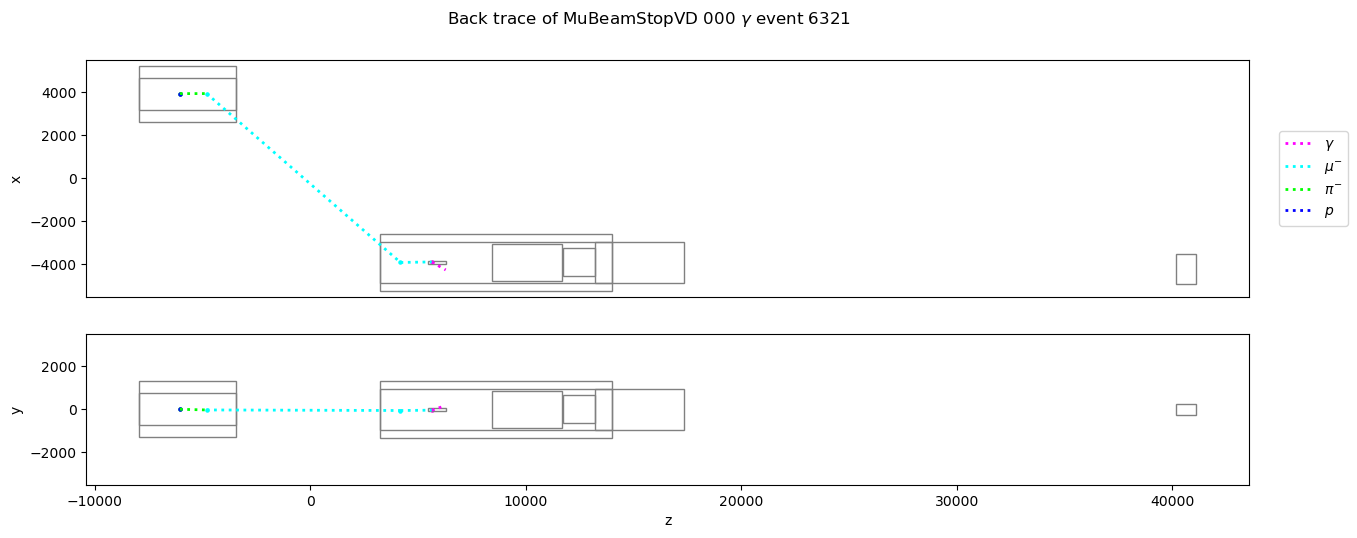

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       23.005024
creationCode                  113
index                       12709
pdgId                          22
px                       3.713599
py                       -9.65483
pz                      20.548104
startpx                  3.713599
startpy                  -9.65483
startpz                 20.548103
starttime              245.116592
startx               -3894.645086
starty                 -71.834718
startz                5693.238946
time                   247.292908
virtualdetectorId              10
x                    -3789.324368
y                     -345.653605
z                     6275.999996
weight                          1
r                      364.179784
Name: 8000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   12709
parentendtime      245.116592
parentpdgId                13
starttime          245.116592
x                -3894.645086
y                  -71.834718
z                 5693.238946
pdgId                      22
Name: 8000, dtype: object

,pdgId,startx,starty,startz
0,13,-3867.098672,-82.526354,4179.000000
1,13,3926.552361,-23.562234,-4686.477981
2,-211,3929.159467,0.762043,-6058.675661
3,2212,3929.458905,0.762493,-6057.480119


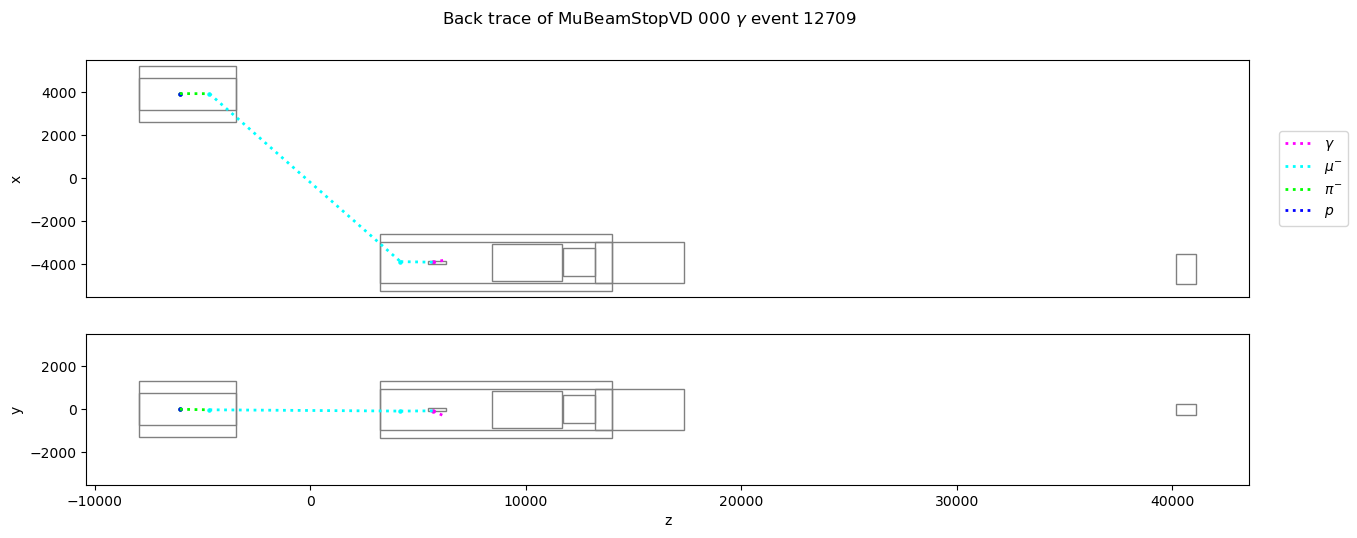

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      334.673436
creationCode                  113
index                       19033
pdgId                          22
px                     239.761095
py                     -38.335648
pz                     230.328686
startpx                239.761099
startpy                -38.335647
startpz                230.328679
starttime               193.98645
startx               -3884.103004
starty                  37.667895
startz                 5915.47511
time                   195.733829
virtualdetectorId              10
x                    -3508.813921
y                      -22.337462
z                     6275.999996
weight                          1
r                      395.816876
Name: 12000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   19033
parentendtime       193.98645
parentpdgId                13
starttime           193.98645
x                -3884.103004
y                   37.667895
z                  5915.47511
pdgId                      22
Name: 12000, dtype: object

,pdgId,startx,starty,startz
0,13,-3911.840883,83.036132,4179.000000
1,13,3909.970645,11.903721,-5548.355823
2,-211,3922.010180,-1.932000,-6086.440862
3,2212,3929.112823,-2.077289,-6057.393831


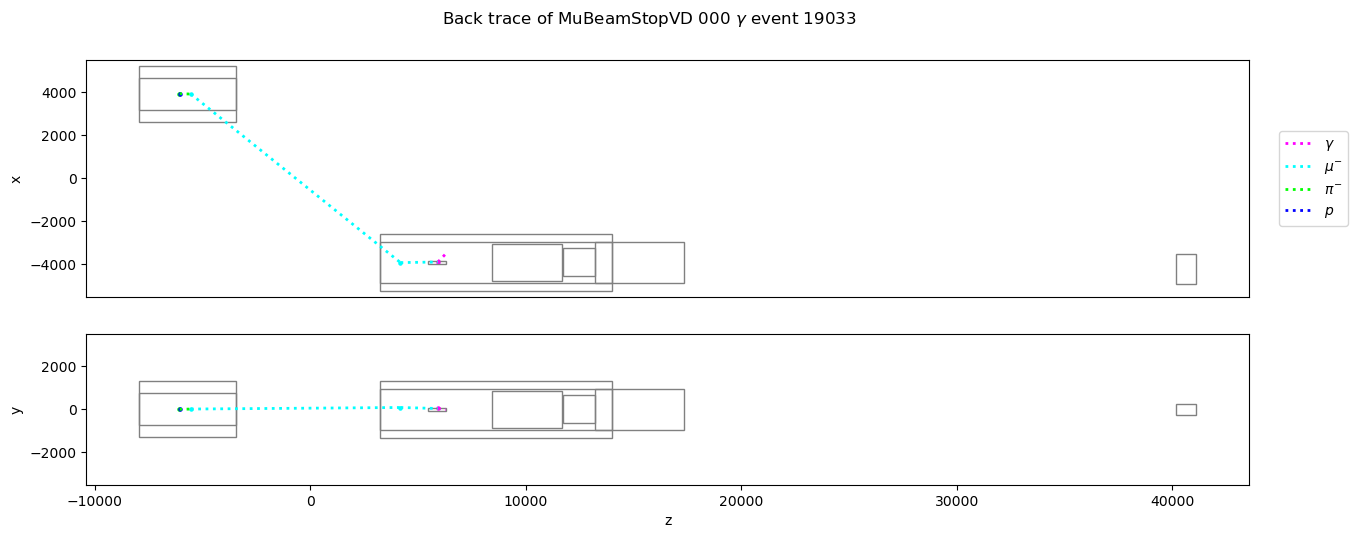

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       71.959692
creationCode                  113
index                       25531
pdgId                          22
px                     -21.764246
py                     -15.926107
pz                      66.714871
startpx                 50.107107
startpy                  3.035936
startpz                -85.771695
starttime              189.144348
startx               -3938.070186
starty                 -55.736618
startz                5959.873678
time                   197.239244
virtualdetectorId              10
x                    -3800.701883
y                     -320.758744
z                     6275.999996
weight                          1
r                       336.98171
Name: 16000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   25531
parentendtime      189.144348
parentpdgId                13
starttime          189.144348
x                -3938.070186
y                  -55.736618
z                 5959.873678
pdgId                      22
Name: 16000, dtype: object

,pdgId,startx,starty,startz
0,13,-3941.192330,-59.150816,4179.000000
1,13,3876.951297,-40.392940,-5275.797493
2,-211,3928.094541,-1.635085,-6070.653478
3,2212,3931.268877,-1.649707,-6057.931395


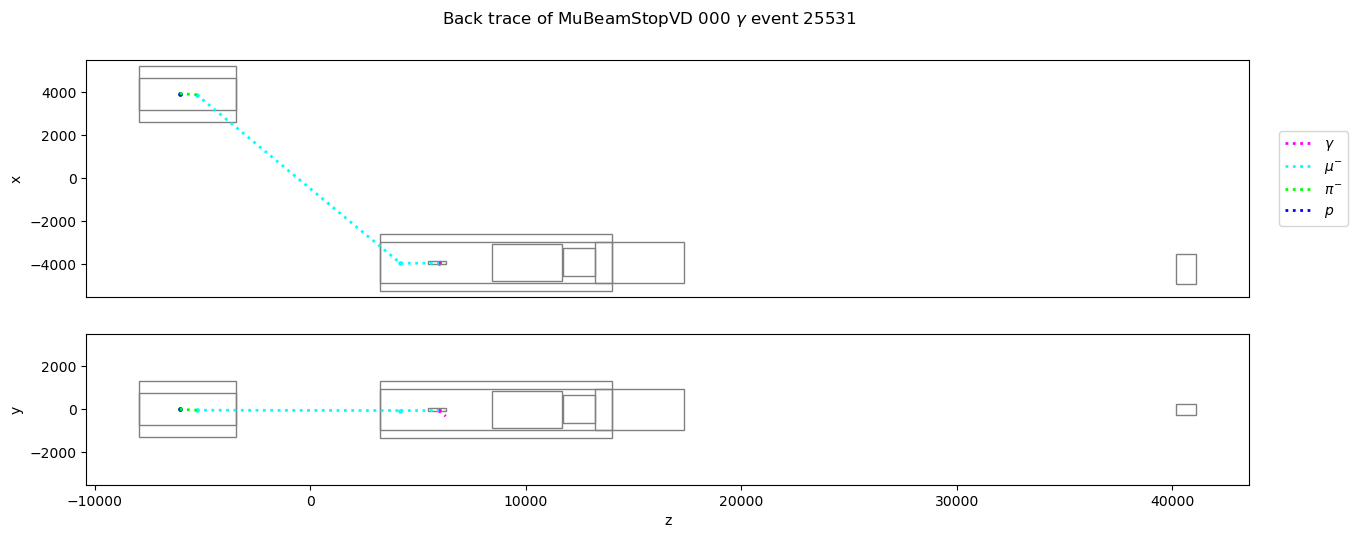

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       61.897634
creationCode                  115
index                       32012
pdgId                          22
px                     -27.628049
py                     -20.788002
pz                      51.340696
startpx                -64.027756
startpy                -88.127293
startpz                  31.93716
starttime             2250.137695
startx               -3970.074156
starty                   0.000688
startz                5493.246414
time                  2260.076627
virtualdetectorId              10
x                    -3998.533059
y                     -418.285811
z                     6275.999996
weight                          1
r                      428.835072
Name: 20000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                   32012
parentendtime      293.382233
parentpdgId                13
starttime         2250.137695
x                -3970.074156
y                    0.000688
z                 5493.246414
pdgId                      22
Name: 20000, dtype: object

,pdgId,startx,starty,startz
0,13,-3973.598561,16.713780,4179.000000
1,13,3857.817913,9.883704,-5813.449744
2,-211,3881.196491,-2.441369,-6234.500052
3,2212,3927.225822,0.014386,-6070.851024
4,2212,3930.486952,0.010742,-6057.736440


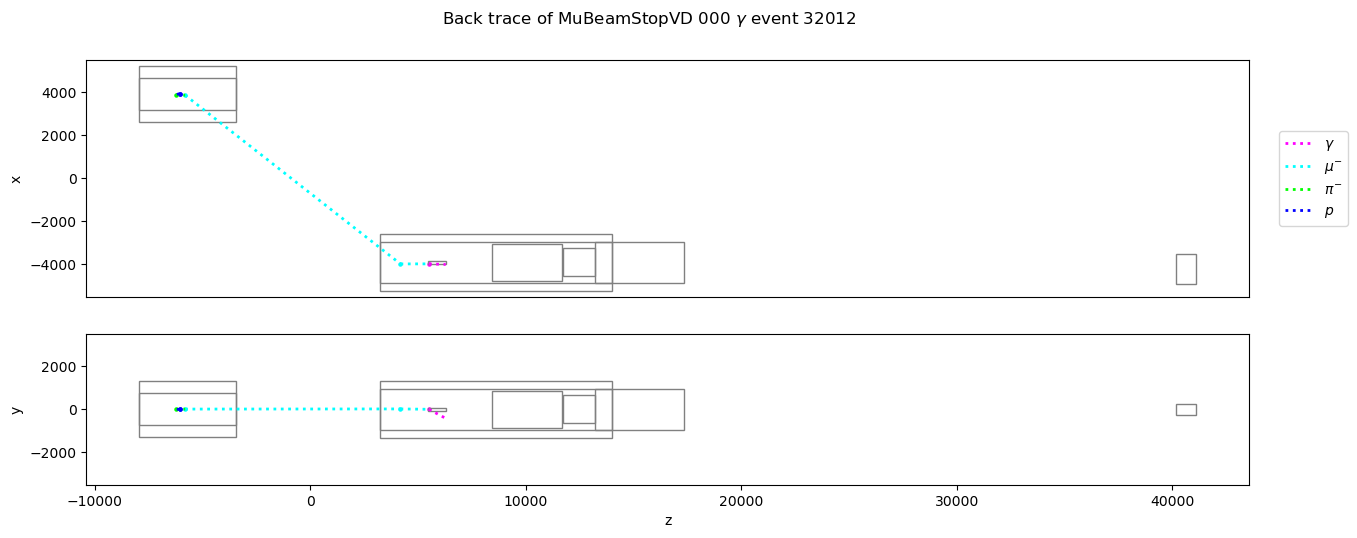

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      198.264297
creationCode                  115
index                       38557
pdgId                          22
px                     -79.322065
py                     -88.198564
pz                      158.86395
startpx                -79.322062
startpy                -88.198565
startpz                158.863947
starttime              870.588196
startx                -3853.78935
starty                  29.285962
startz                5559.866943
time                   873.569382
virtualdetectorId              10
x                     -4211.36042
y                     -368.298936
z                     6275.999996
weight                          1
r                      479.702547
Name: 24000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                   38557
parentendtime       189.53418
parentpdgId                13
starttime          870.588196
x                 -3853.78935
y                   29.285962
z                 5559.866943
pdgId                      22
Name: 24000, dtype: object

,pdgId,startx,starty,startz
0,13,-3856.137586,19.924647,4179.000000
1,13,3934.699505,4.629176,-5789.230032
2,-211,3908.668306,1.769030,-6141.121417
3,2212,3929.595137,1.887933,-6057.514085


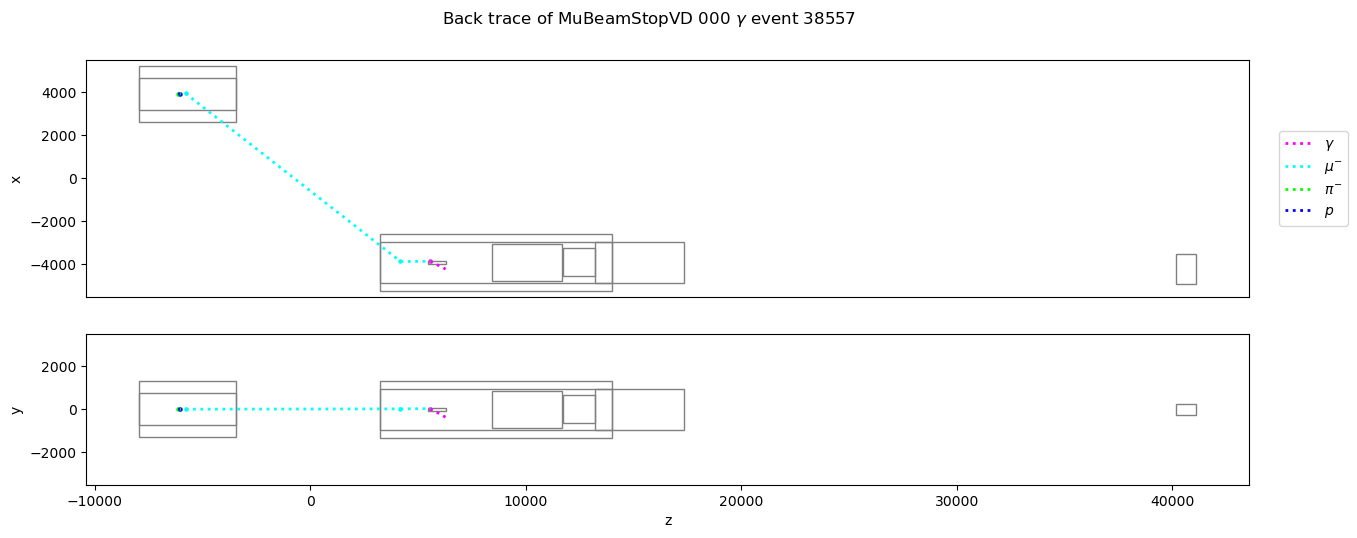

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      334.673436
creationCode                  113
index                       44961
pdgId                          22
px                      -43.61317
py                     105.587174
pz                     314.572009
startpx                -43.613169
startpy                105.587177
startpz                314.572006
starttime              426.669617
startx               -3933.877575
starty                 -16.594616
startz                5537.614088
time                   429.289981
virtualdetectorId              10
x                    -4036.249525
y                      231.247148
z                     6275.999996
weight                          1
r                      266.392906
Name: 28000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   44961
parentendtime      426.669617
parentpdgId                13
starttime          426.669617
x                -3933.877575
y                  -16.594616
z                 5537.614088
pdgId                      22
Name: 28000, dtype: object

,pdgId,startx,starty,startz
0,13,-3900.184078,11.365070,4179.000000
1,13,3928.681209,-38.729038,-3131.740499
2,-211,3925.815647,1.991897,-6068.428706
3,2212,3928.584267,1.969254,-6057.262047


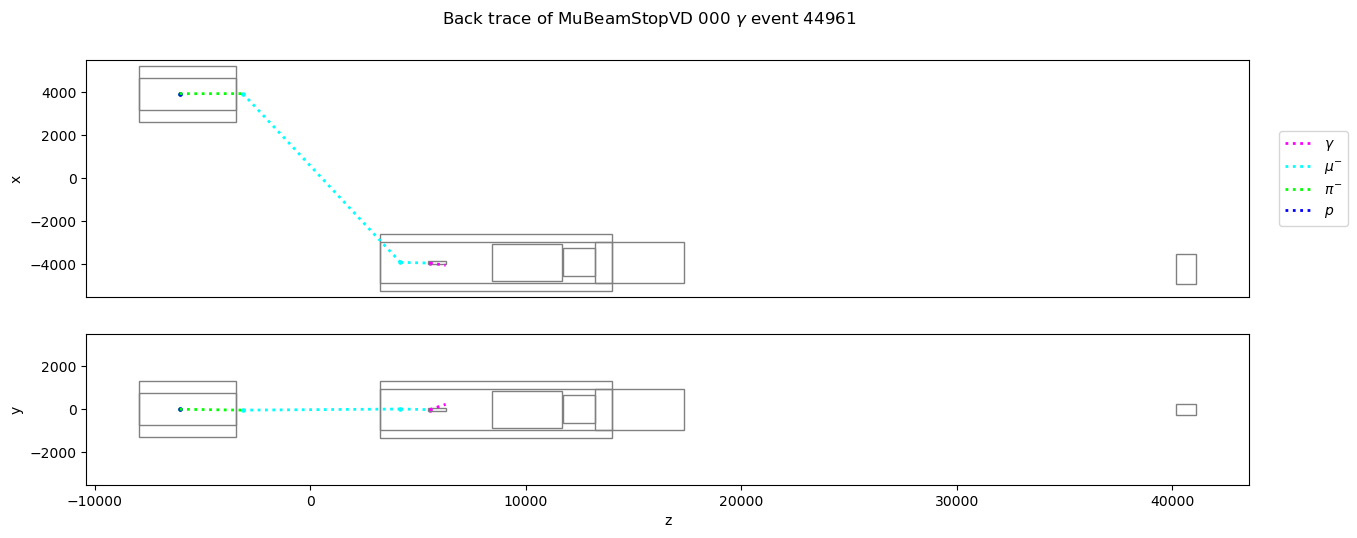

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      334.673436
creationCode                  113
index                       51467
pdgId                          22
px                    -101.298958
py                     163.062683
pz                     274.144836
startpx               -101.298958
startpy                163.062677
startpz                274.144828
starttime                252.8918
startx               -3937.520197
starty                 -19.476458
startz                 5959.88631
time                   254.179059
virtualdetectorId              10
x                    -4054.327018
y                      168.549501
z                     6275.999996
weight                          1
r                      225.847618
Name: 32000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   51467
parentendtime        252.8918
parentpdgId                13
starttime            252.8918
x                -3937.520197
y                  -19.476458
z                  5959.88631
pdgId                      22
Name: 32000, dtype: object

,pdgId,startx,starty,startz
0,13,-4008.901094,-10.128329,4179.000000
1,13,3836.475400,4.970338,-5671.822598
2,-211,3900.974000,0.864993,-6171.805367
3,2212,3903.001055,-0.001342,-6164.945047
4,2212,3929.892394,-0.242263,-6057.588200


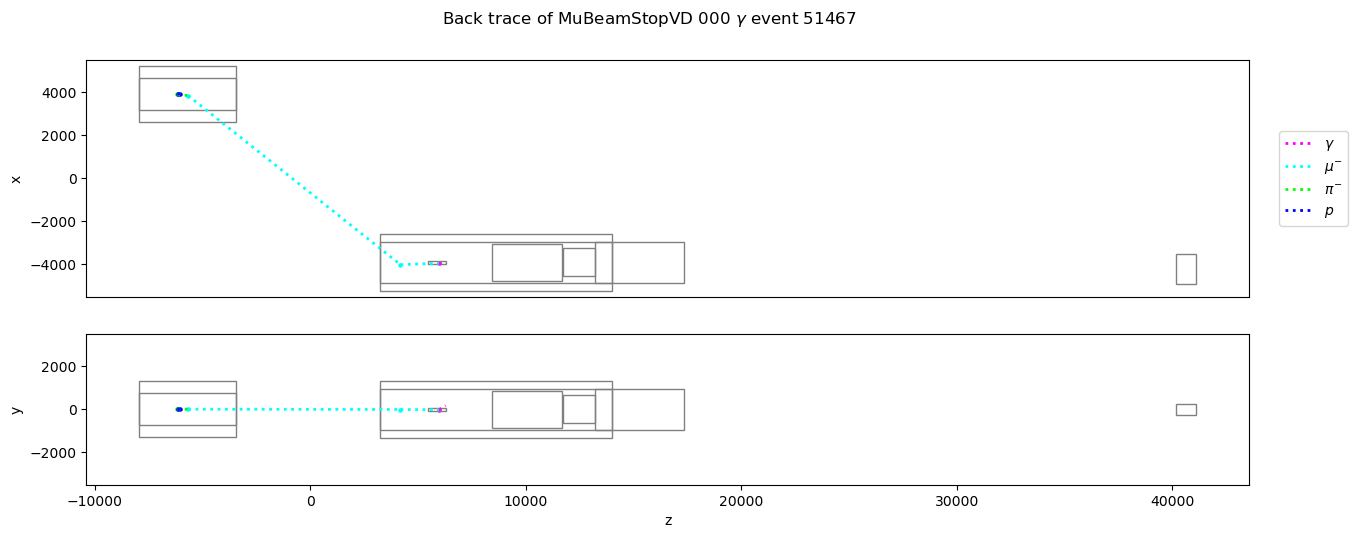

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       65.728641
creationCode                  113
index                       57871
pdgId                          22
px                       4.904566
py                      17.464823
pz                      63.175782
startpx                  4.904566
startpy                 17.464822
startpz                 63.175783
starttime              251.166656
startx               -3877.616743
starty                  20.883984
startz                5648.812282
time                   253.343271
virtualdetectorId              10
x                    -3828.925879
y                      194.268816
z                     6275.999996
weight                          1
r                      208.270249
Name: 36000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   57871
parentendtime      251.166656
parentpdgId                13
starttime          251.166656
x                -3877.616743
y                   20.883984
z                 5648.812282
pdgId                      22
Name: 36000, dtype: object

,pdgId,startx,starty,startz
0,13,-3875.533548,-12.919101,4179.000000
1,13,3998.216563,25.028449,-6491.069982
2,-211,3911.700319,1.944086,-6132.542179
3,2212,3930.461803,1.763132,-6057.730169


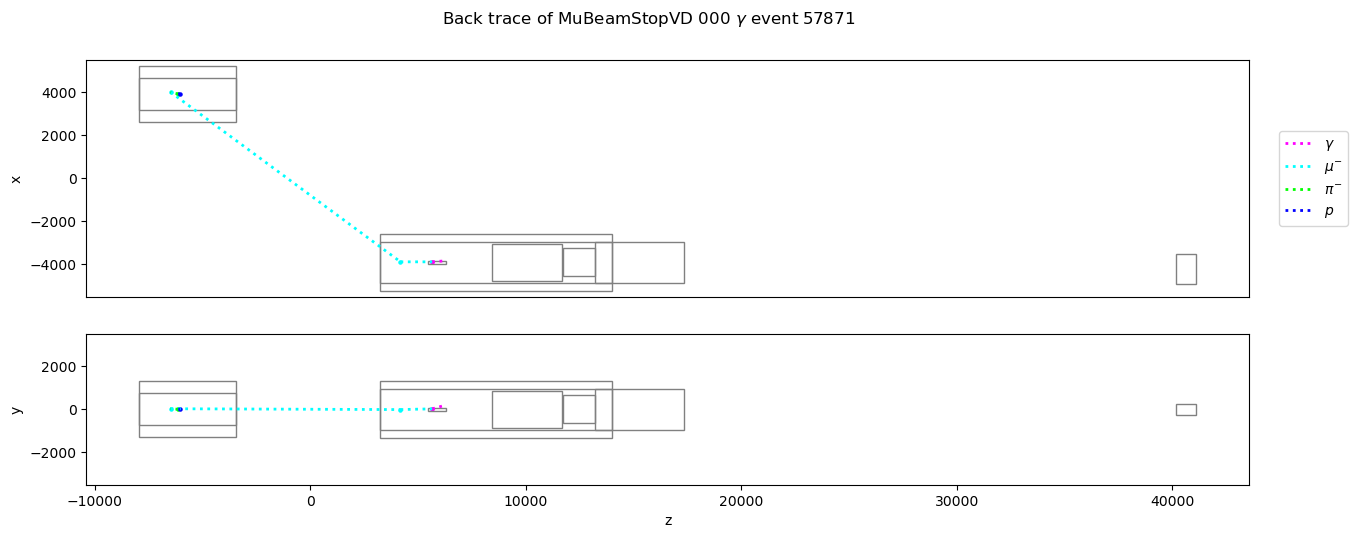

------------------------------------------------------------------------------


tag                    MuBeamStopVD
fileno                            0
E                       1119.378334
creationCode                     35
index                         64324
pdgId                            22
px                       402.330006
py                      -409.619686
pz                      -960.911095
startpx                  402.330011
startpy                 -409.619689
startpz                 -960.911095
starttime                2327398.25
startx                  -4646.73844
starty                   595.856094
startz                  6933.877697
time                 2327400.712035
virtualdetectorId                10
x                      -4371.295796
y                        315.422799
z                       6276.019996
weight                            1
r                        563.787995
Name: 40000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode               35
index                   64324
parentendtime      2327398.25
parentpdgId              2112
starttime          2327398.25
x                 -4646.73844
y                  595.856094
z                 6933.877697
pdgId                      22
Name: 40000, dtype: object

,pdgId,startx,starty,startz
0,2112,-3964.302769,-27.118147,5693.178794
1,13,-3945.261366,-22.311319,4179.000000
2,13,3852.556200,-18.326627,-5935.169635
3,-211,3913.646336,-0.405740,-6120.234178
4,2212,3929.062098,-0.793427,-6057.381184


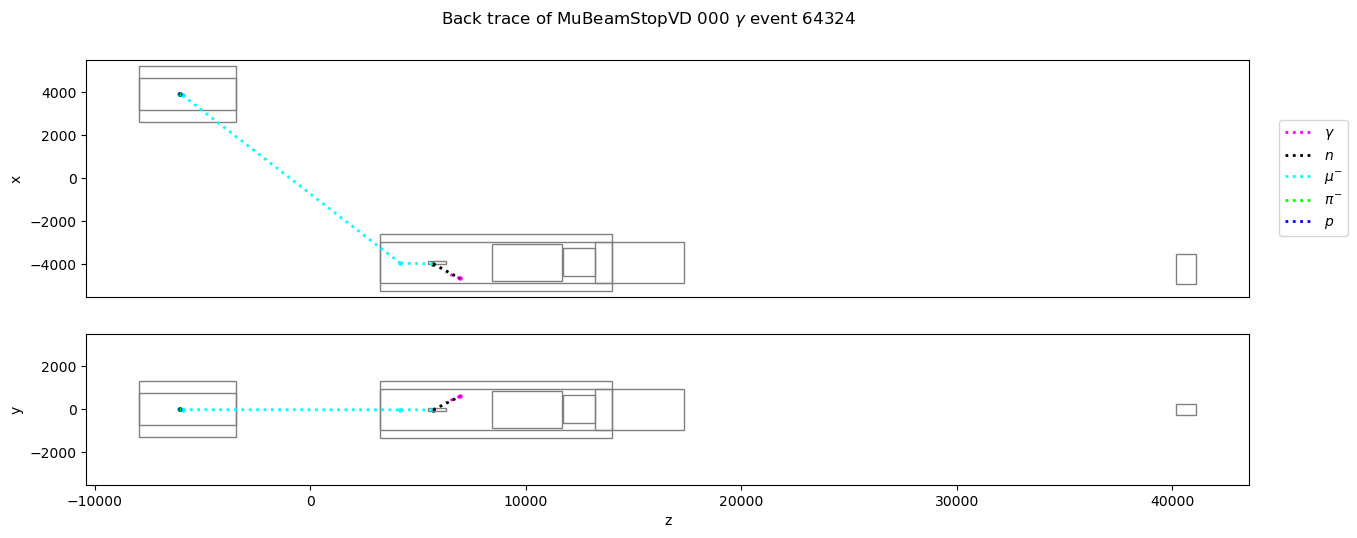

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       46.336795
creationCode                  113
index                       70648
pdgId                          22
px                     -23.685618
py                      -6.713325
pz                      39.255845
startpx                -33.323914
startpy                -33.665858
startpz                -16.522536
starttime              271.202667
startx               -3844.223112
starty                   21.80469
startz                6115.415541
time                   272.459637
virtualdetectorId              10
x                    -4057.485117
y                     -103.745972
z                     6275.999996
weight                          1
r                       185.25903
Name: 44000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   70648
parentendtime      271.202667
parentpdgId                13
starttime          271.202667
x                -3844.223112
y                    21.80469
z                 6115.415541
pdgId                      22
Name: 44000, dtype: object

,pdgId,startx,starty,startz
0,13,-3861.277645,30.075032,4179.000000
1,13,3935.317330,17.728495,-4286.967003
2,-211,3914.339569,-0.562999,-6126.961427
3,2212,3931.399853,-0.992312,-6057.964051


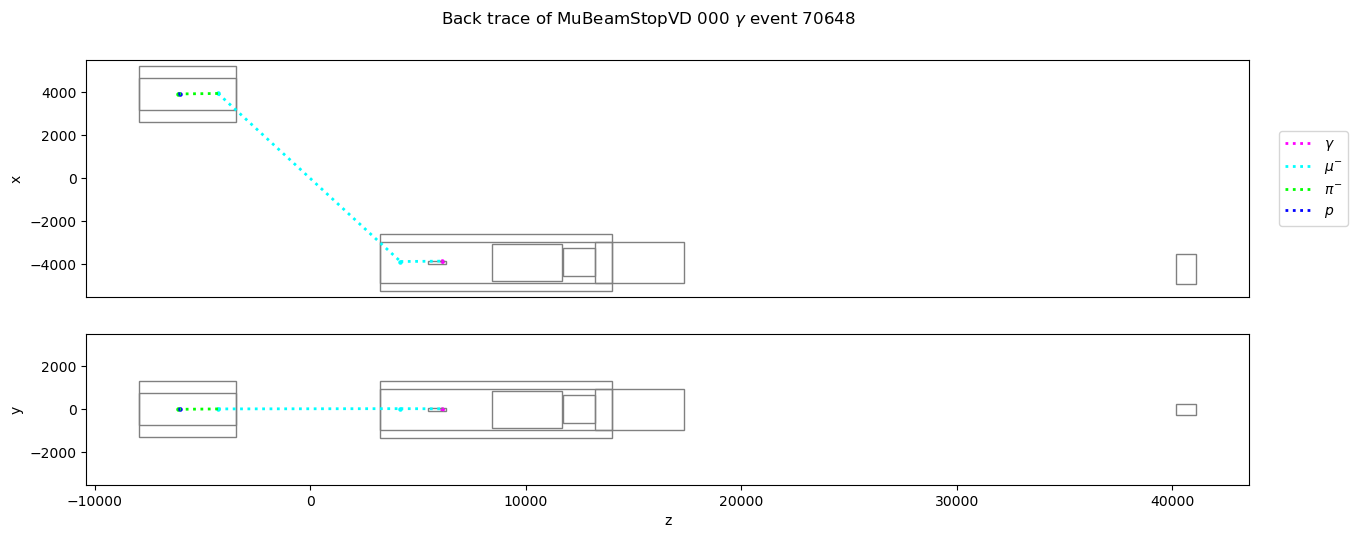

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      334.673436
creationCode                  113
index                       77042
pdgId                          22
px                     -50.278062
py                    -217.109394
pz                     249.683672
startpx                -50.278064
startpy               -217.109397
startpz                249.683678
starttime              221.375305
startx               -3936.377601
starty                  -22.25662
startz                5715.438796
time                     223.8816
virtualdetectorId              10
x                    -4049.256152
y                     -509.685778
z                     6275.999996
weight                          1
r                      529.980133
Name: 48000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              113
index                   77042
parentendtime      221.375305
parentpdgId                13
starttime          221.375305
x                -3936.377601
y                   -22.25662
z                 5715.438796
pdgId                      22
Name: 48000, dtype: object

,pdgId,startx,starty,startz
0,13,-3889.988793,-79.780538,4179.000000
1,13,3924.063913,-43.536806,-4653.212061
2,-211,3906.641875,-59.113465,-6195.522883
3,310,3910.841501,1.313242,-6138.331069
4,2212,3930.651241,1.022290,-6057.777402


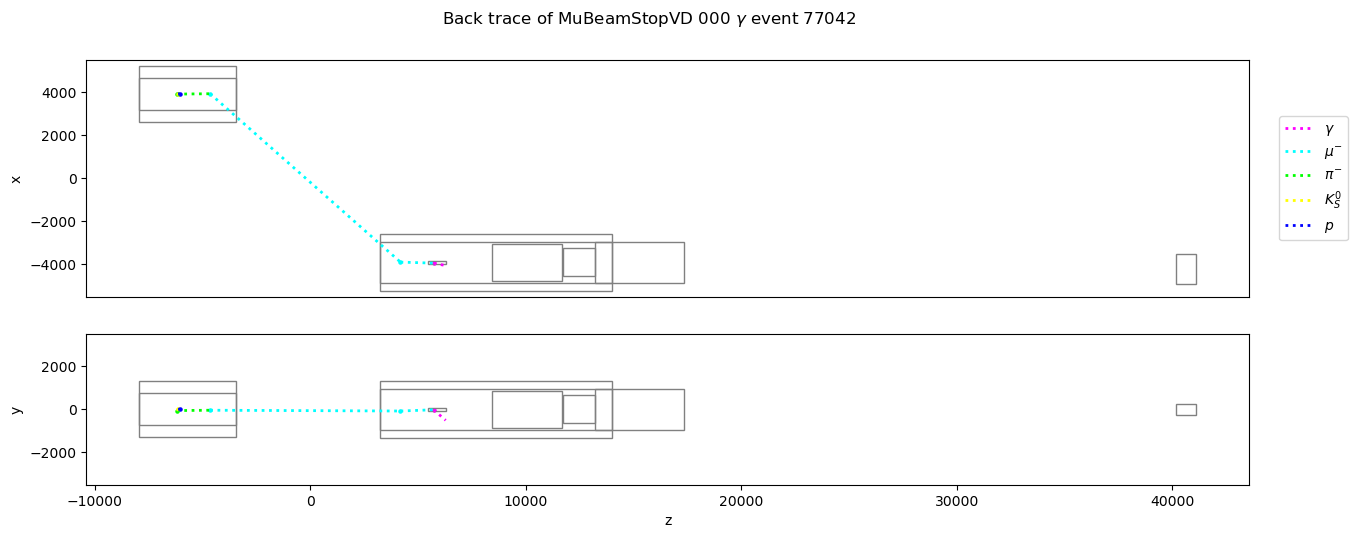

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                        8999.297
creationCode                   35
index                       83396
pdgId                          22
px                   -6069.092093
py                    -192.868366
pz                   -6642.007938
startpx              -6069.092274
startpy               -192.868367
startpz              -6642.007828
starttime            20863.599609
startx               -3322.775299
starty                 345.267565
startz                7083.669436
time                 20867.248846
virtualdetectorId              10
x                    -4060.759787
y                      321.815316
z                     6276.019996
weight                          1
r                      357.964702
Name: 52000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode               35
index                   83396
parentendtime    20863.599609
parentpdgId              2112
starttime        20863.599609
x                -3322.775299
y                  345.267565
z                 7083.669436
pdgId                      22
Name: 52000, dtype: object

,pdgId,startx,starty,startz
0,2112,-3337.801148,381.217328,7084.030894
1,2112,-3040.795429,434.939303,6738.884713
2,2112,-3944.277237,-36.309897,5804.297465
3,13,-3959.078288,2.953911,4179.000000
4,13,3892.748196,3.901985,-5550.914491
5,-211,3889.877846,-1.231631,-6221.839277
6,2212,3930.340945,-0.928736,-6057.700036


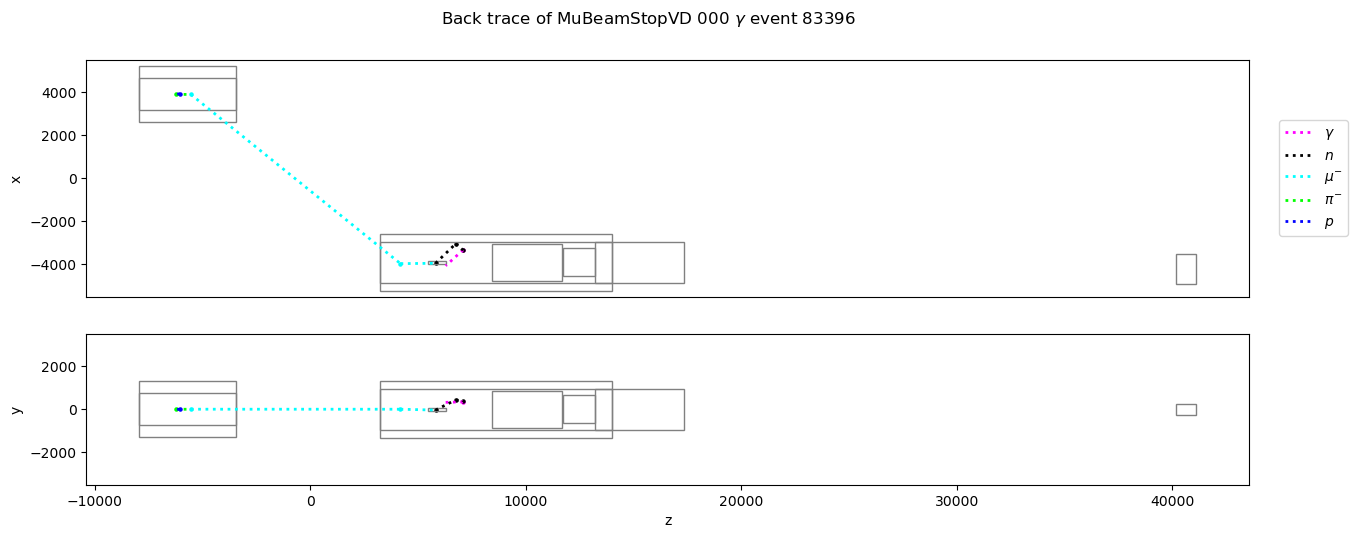

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      334.673436
creationCode                  113
index                         561
pdgId                          22
px                     210.052634
py                       50.00298
pz                      255.70276
startpx                210.052639
startpy                 50.002981
startpz                255.702764
starttime              245.569031
startx               -3914.974403
starty                 -55.313117
startz                5693.264361
time                   248.113145
virtualdetectorId              10
x                    -3436.273448
y                       58.641532
z                     6275.999996
weight                          1
r                      471.388329
Name: 56000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              113
index                     561
parentendtime      245.569031
parentpdgId                13
starttime          245.569031
x                -3914.974403
y                  -55.313117
z                 5693.264361
pdgId                      22
Name: 56000, dtype: object

,pdgId,startx,starty,startz
0,13,-3877.679328,-17.136014,4179.000000
1,13,3909.319950,-4.669416,-3282.148792
2,-211,3909.325222,-0.688603,-6132.235152
3,2212,3928.644157,-0.768202,-6057.276979


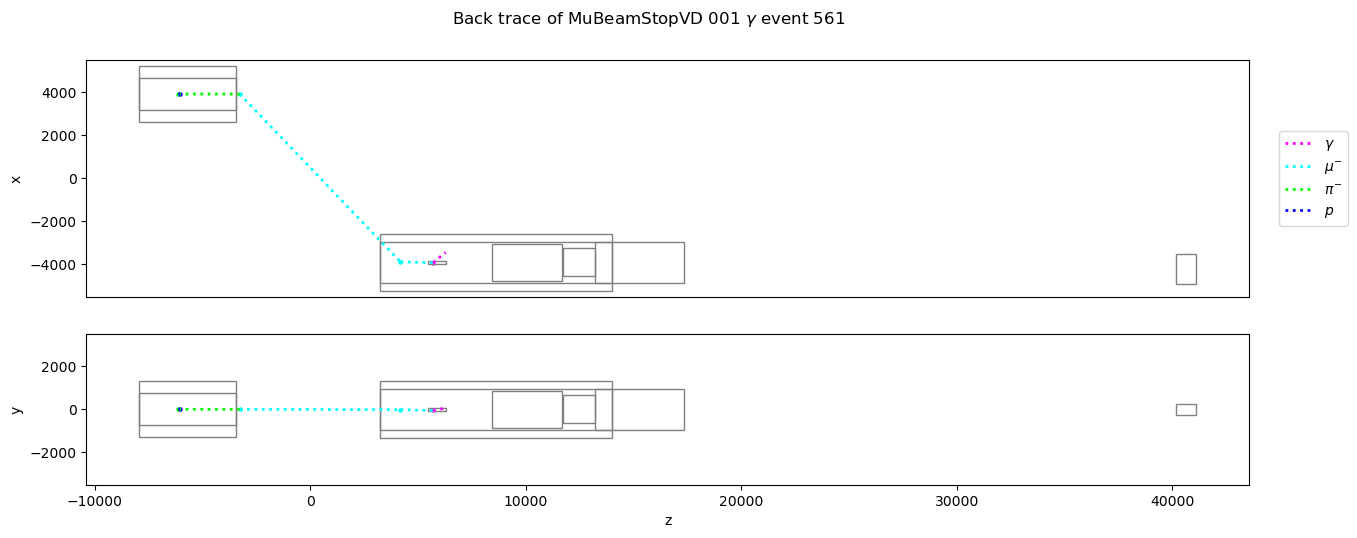

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      549.254058
creationCode                  115
index                        6984
pdgId                          22
px                    -196.464999
py                    -236.717933
pz                     455.023235
startpx               -196.465001
startpy               -236.717939
startpz                455.023229
starttime              429.848511
startx                -3877.67495
starty                   33.63935
startz                5493.203085
time                   433.000389
virtualdetectorId              10
x                    -4215.662513
y                     -373.597144
z                     6275.999996
weight                          1
r                      486.526821
Name: 60000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                    6984
parentendtime      429.848511
parentpdgId                13
starttime          429.848511
x                 -3877.67495
y                    33.63935
z                 5493.203085
pdgId                      22
Name: 60000, dtype: object

,pdgId,startx,starty,startz
0,13,-3887.768771,38.177630,4179.000000
1,13,3920.448750,29.286521,-5480.404022
2,-211,3926.990870,1.069187,-6074.455425
3,2212,3931.113963,1.099398,-6057.892771


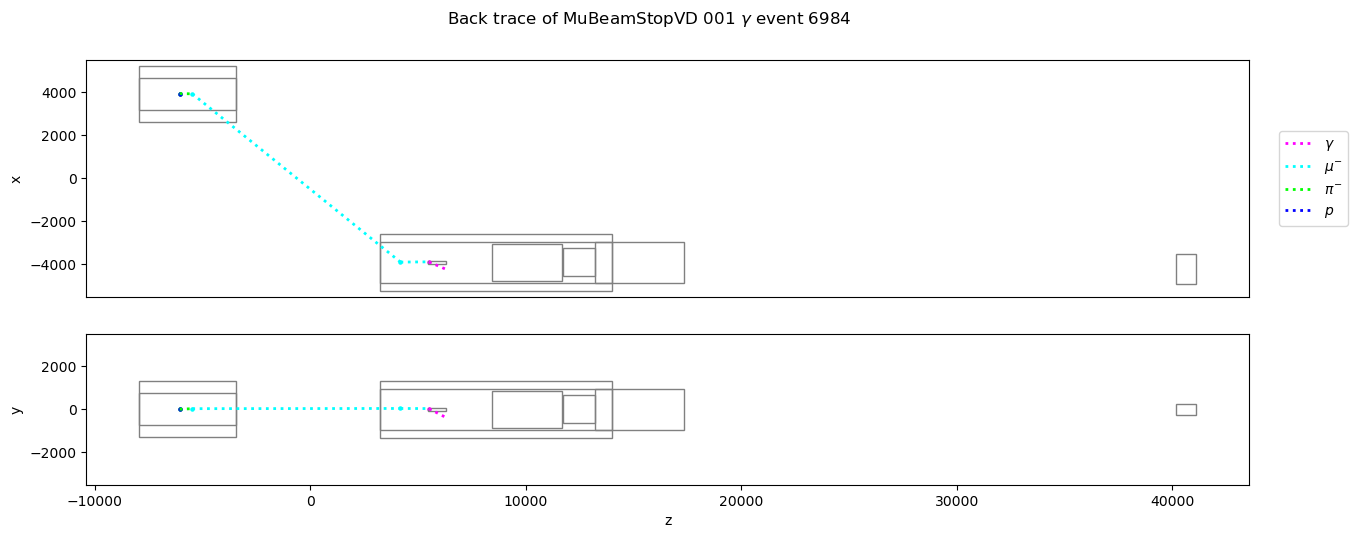

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                       49.873396
creationCode                  113
index                       13440
pdgId                          22
px                      39.236103
py                      -7.275958
pz                      -29.91562
startpx                -26.419166
startpy                 11.222275
startpz                 59.129879
starttime              280.048279
startx               -3965.509244
starty                  31.243546
startz                5715.482956
time                   287.585021
virtualdetectorId              10
x                    -3732.593255
y                      110.059032
z                     6276.019996
weight                          1
r                      203.698951
Name: 64000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              113
index                   13440
parentendtime      280.048279
parentpdgId                13
starttime          280.048279
x                -3965.509244
y                   31.243546
z                 5715.482956
pdgId                      22
Name: 64000, dtype: object

,pdgId,startx,starty,startz
0,13,-3940.974808,55.630373,4179.000000
1,13,3851.087016,49.445641,-5271.953860
2,-211,3900.345168,2.152634,-6178.745609
3,2212,3929.916035,1.338237,-6057.594094


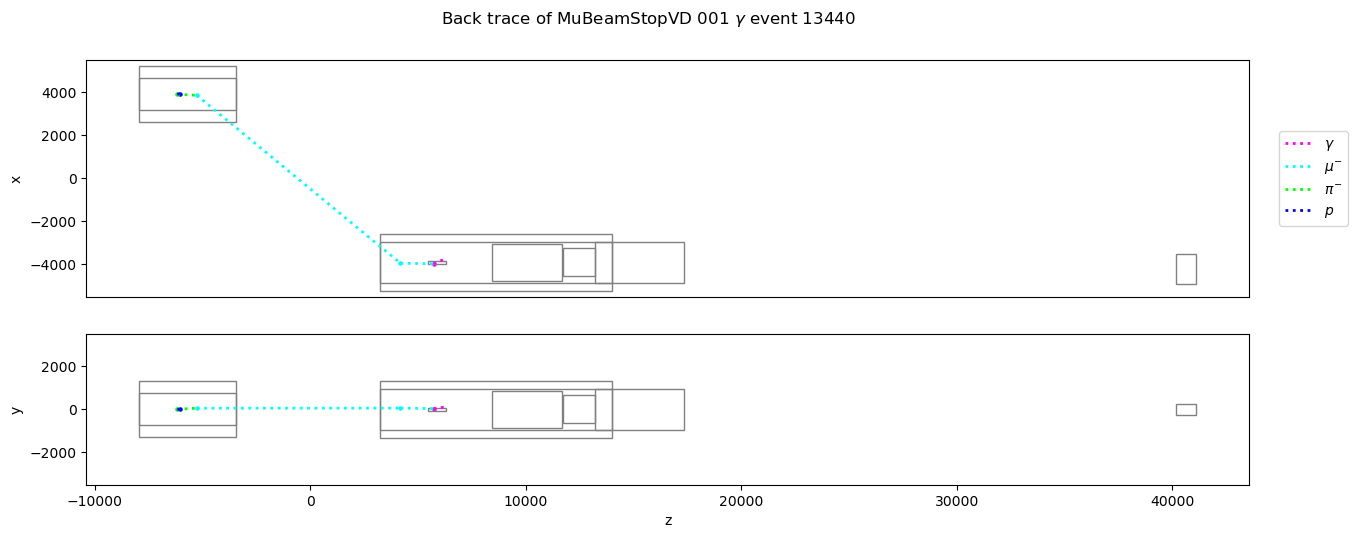

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      153.855873
creationCode                  113
index                       19881
pdgId                          22
px                      64.306036
py                     -78.451112
pz                     115.679672
startpx               -148.916051
startpy                143.581733
startpz               -263.086677
starttime              180.848282
startx               -3870.119333
starty                 -60.583416
startz                5893.265596
time                    193.82291
virtualdetectorId              10
x                    -3677.081488
y                     -492.062155
z                     6275.999996
weight                          1
r                      541.864537
Name: 68000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              113
index                   19881
parentendtime      180.848282
parentpdgId                13
starttime          180.848282
x                -3870.119333
y                  -60.583416
z                 5893.265596
pdgId                      22
Name: 68000, dtype: object

,pdgId,startx,starty,startz
0,13,-3878.146436,-28.050395,4179.000000
1,13,3934.151058,-16.400358,-5544.954881
2,-211,3918.862139,0.954138,-6099.474051
3,2212,3929.387814,0.975634,-6057.462394


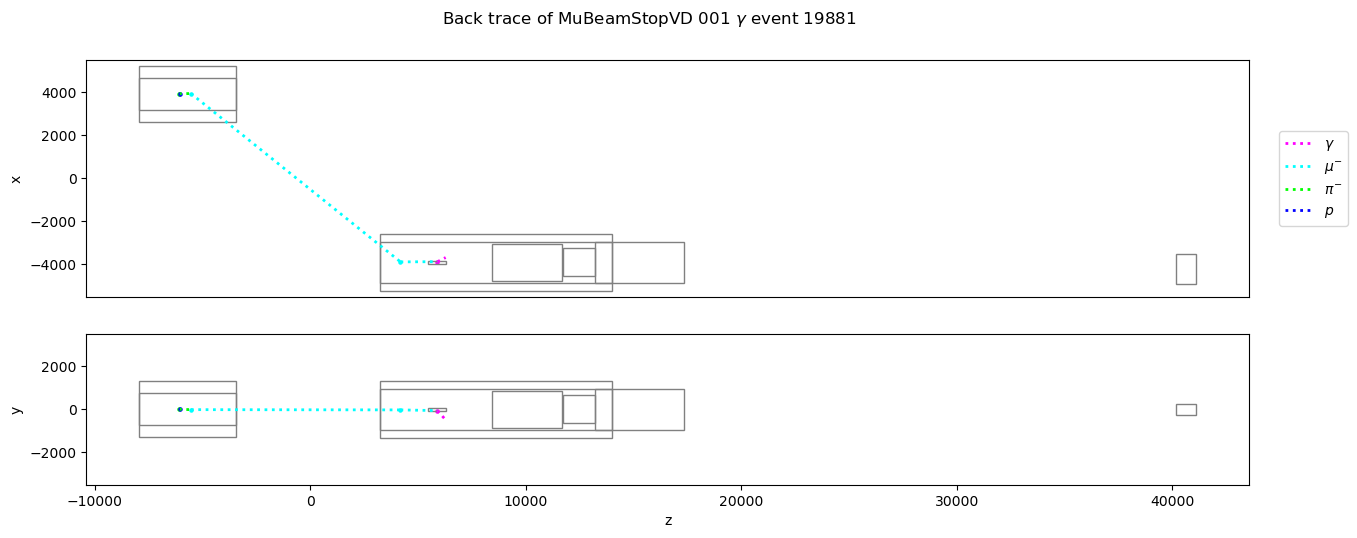

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      334.673436
creationCode                  113
index                       26306
pdgId                          22
px                    -128.822228
py                    -291.317973
pz                     102.688755
startpx               -128.822222
startpy                -291.31797
startpz                102.688752
starttime              206.204865
startx               -3880.036961
starty                  12.779804
startz                6159.914167
time                   207.466852
virtualdetectorId              10
x                    -4025.665712
y                     -316.544358
z                     6275.999996
weight                          1
r                       339.12074
Name: 72000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              113
index                   26306
parentendtime      206.204865
parentpdgId                13
starttime          206.204865
x                -3880.036961
y                   12.779804
z                 6159.914167
pdgId                      22
Name: 72000, dtype: object

,pdgId,startx,starty,startz
0,13,-3901.231441,-3.278628,4179.000000
1,13,3933.486955,2.610199,-4745.763189
2,-211,3928.710586,1.582498,-6065.131865
3,2212,3929.878768,1.624941,-6060.541550
4,2212,3930.574234,1.622978,-6057.758201


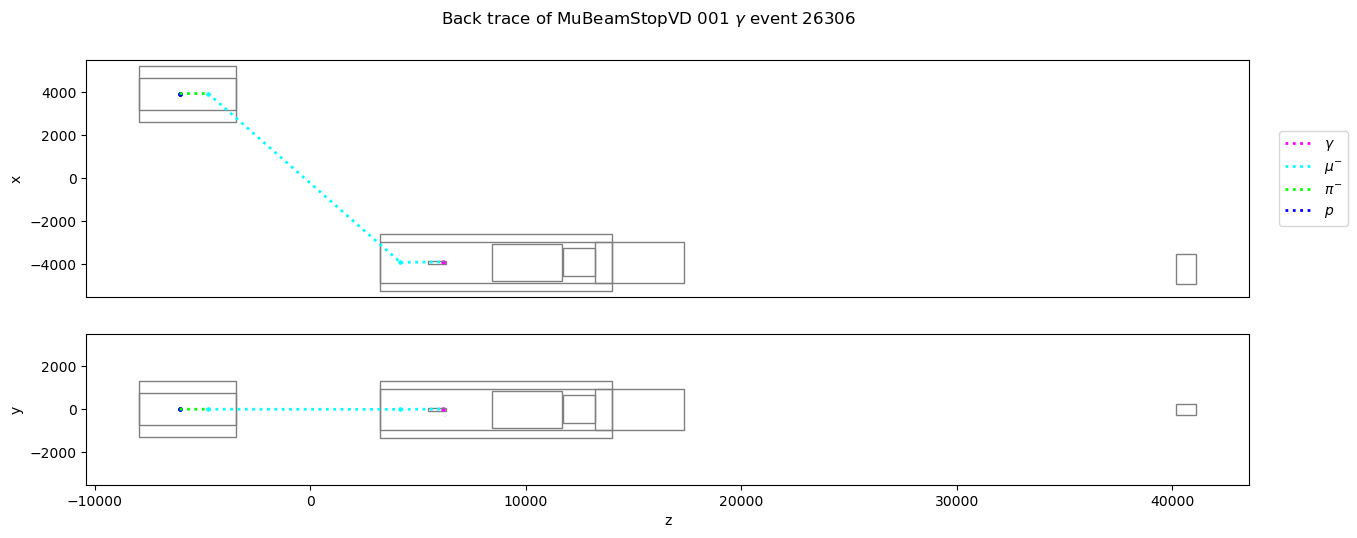

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                       42.924827
creationCode                  113
index                       32796
pdgId                          22
px                      -22.52949
py                     -12.867166
pz                      34.196474
startpx                 -22.52949
startpy                -12.867166
startpz                 34.196474
starttime              109.504646
startx               -3936.248248
starty                  52.071566
startz                6204.384782
time                   109.804501
virtualdetectorId              10
x                    -3983.430137
y                       25.124788
z                     6275.999996
weight                          1
r                       83.309073
Name: 76000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              113
index                   32796
parentendtime      109.504646
parentpdgId                13
starttime          109.504646
x                -3936.248248
y                   52.071566
z                 6204.384782
pdgId                      22
Name: 76000, dtype: object

,pdgId,startx,starty,startz
0,13,-3968.718385,7.735046,4179.000000
1,13,3899.454982,-6.496202,-4950.756869
2,-211,3921.943019,1.813572,-6093.004470
3,130,3923.152129,1.584172,-6091.611607
4,2212,3931.591481,1.509933,-6058.011830


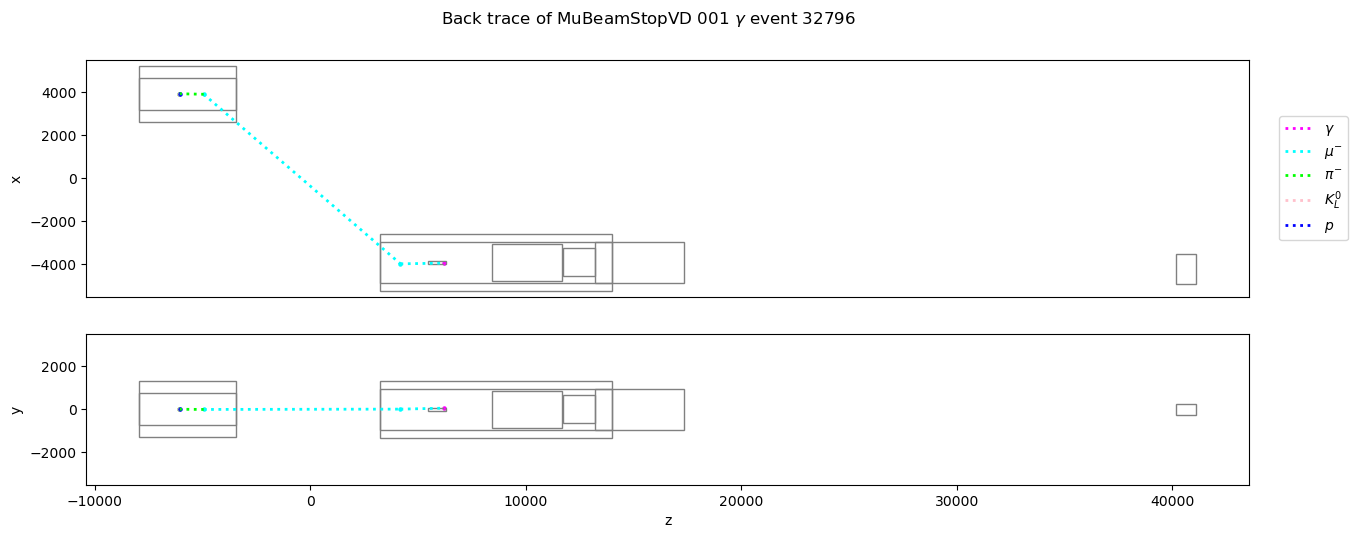

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                     9656.883636
creationCode                  115
index                       39243
pdgId                          22
px                      869.20096
py                    3652.563687
pz                    8897.115812
startpx                869.200945
startpy               3652.563572
startpz               8897.115707
starttime              912.424866
startx               -3960.368174
starty                  -2.665893
startz                5693.233627
time                   914.534757
virtualdetectorId              10
x                    -3903.434995
y                      236.579197
z                     6275.999996
weight                          1
r                      236.579872
Name: 80000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   39243
parentendtime      348.437439
parentpdgId                13
starttime          912.424866
x                -3960.368174
y                   -2.665893
z                 5693.233627
pdgId                      22
Name: 80000, dtype: object

,pdgId,startx,starty,startz
0,13,-3969.380546,-47.629600,4179.000000
1,13,3865.090788,20.844775,-5460.652040
2,-211,3890.863860,-2.490056,-6215.706893
3,2212,3931.159520,-2.600882,-6057.904130


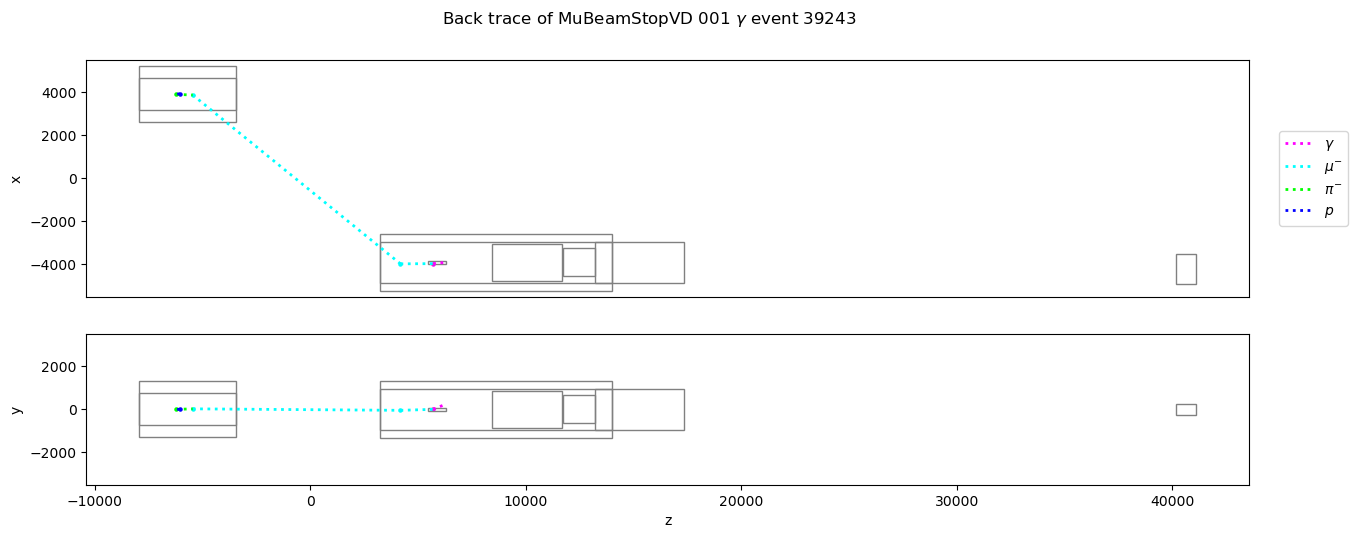

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      334.673436
creationCode                  113
index                       45782
pdgId                          22
px                     227.168936
py                     192.384765
pz                     152.933598
startpx                227.168933
startpy                192.384765
startpz                152.933598
starttime              196.748718
startx               -3847.250292
starty                  22.332063
startz                6071.014381
time                   198.245021
virtualdetectorId              10
x                    -3542.762825
y                      280.196324
z                     6275.999996
weight                          1
r                      457.167668
Name: 84000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              113
index                   45782
parentendtime      196.748718
parentpdgId                13
starttime          196.748718
x                -3847.250292
y                   22.332063
z                 6071.014381
pdgId                      22
Name: 84000, dtype: object

,pdgId,startx,starty,startz
0,13,-3823.893767,34.654678,4179.000000
1,13,3899.757865,-2.036044,-4283.029717
2,-211,3911.906582,-0.475873,-6131.401056
3,2212,3930.025615,-0.431391,-6057.621415


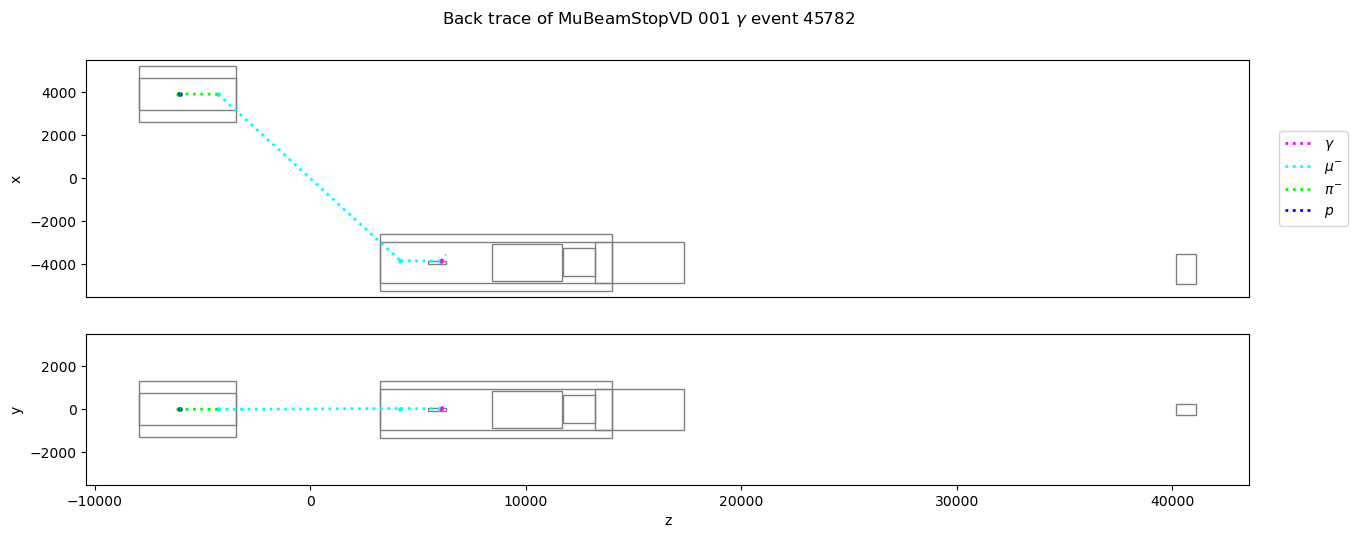

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                     1014.911301
creationCode                  115
index                       52173
pdgId                          22
px                     473.510524
py                    -288.235352
pz                     850.148878
startpx                473.510534
startpy               -288.235366
startpz                850.148857
starttime              200.749344
startx               -3954.765607
starty                  11.732653
startz                5759.890257
time                   202.804546
virtualdetectorId              10
x                    -3667.306081
y                     -163.249725
z                     6275.999996
weight                          1
r                       287.53171
Name: 88000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   52173
parentendtime      193.470184
parentpdgId                13
starttime          200.749344
x                -3954.765607
y                   11.732653
z                 5759.890257
pdgId                      22
Name: 88000, dtype: object

,pdgId,startx,starty,startz
0,13,-3960.403235,7.157901,4179.000000
1,13,3767.505602,20.509960,-2214.280275
2,-211,3883.467115,-1.223618,-6258.551891
3,2212,3933.052907,-0.621784,-6058.376204


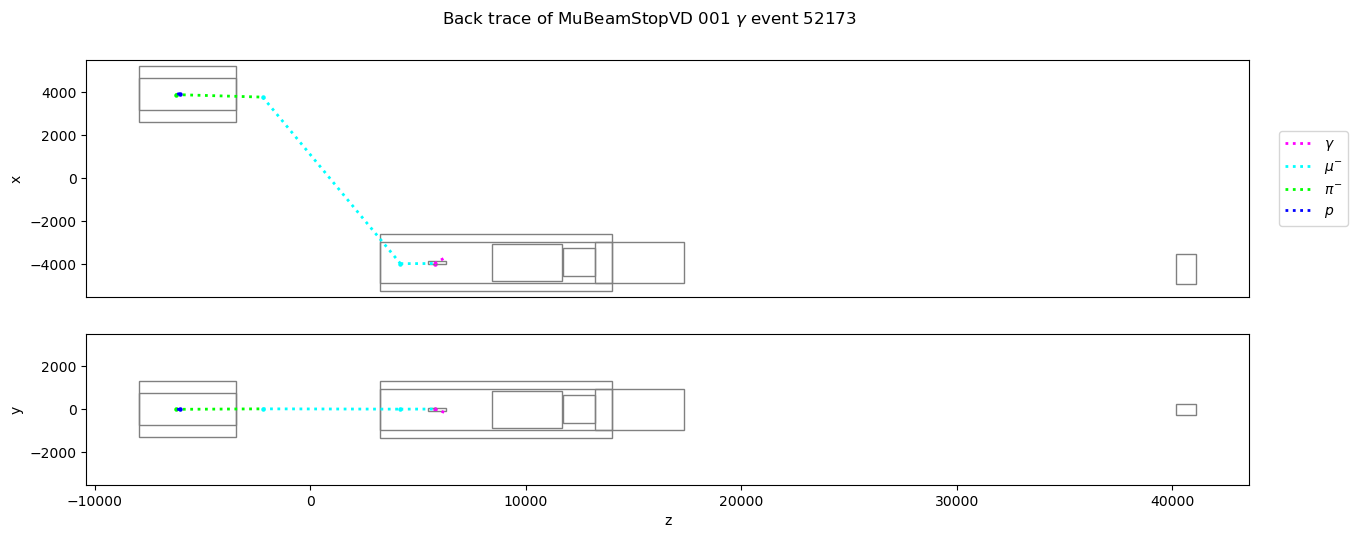

------------------------------------------------------------------------------


tag                        MuBeamStopVD
fileno                                1
E                            843.745834
creationCode                         74
index                             58605
pdgId                                22
px                           -61.398825
py                              76.7322
pz                           838.003213
startpx                      -61.398827
startpy                       76.732203
startpz                      838.003218
starttime                 59023728640.0
startx                     -3969.696593
starty                       -20.164504
startz                      5493.176917
time                 59023730362.072021
virtualdetectorId                    10
x                           -4027.05248
y                             51.515098
z                           6275.999996
weight                                1
r                            133.400592
Name: 92000, dtype: object

tag               MuBeamStopVD
fileno                       1
creationCode                74
index                    58605
parentendtime    59023728640.0
parentpdgId         1000130279
starttime        59023728640.0
x                 -3969.696593
y                   -20.164504
z                  5493.176917
pdgId                       22
Name: 92000, dtype: object

,pdgId,startx,starty,startz
0,1000130279,-3969.696593,-20.164504,5493.176917
1,1000120270,-3969.696721,-20.164368,5493.177253
2,13,-3972.440170,-26.517623,4179.000000
3,13,3888.063203,-19.528170,-5632.603224
4,-211,3892.326395,0.117509,-6177.913252
5,3122,3909.025032,0.356777,-6142.017397
6,3212,3909.025032,0.356777,-6142.017397
7,2212,3929.777034,0.261656,-6057.559437


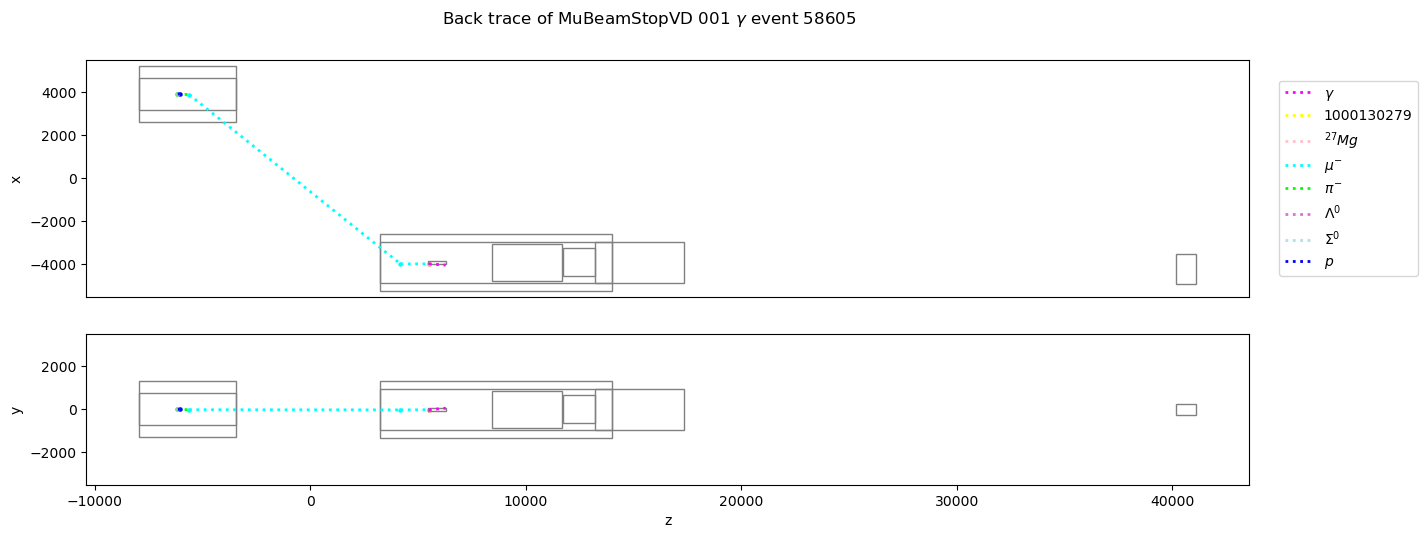

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      372.041898
creationCode                  115
index                       65028
pdgId                          22
px                    -180.824952
py                    -214.396221
pz                     244.441754
startpx                -180.82495
startpy               -214.396223
startpz                244.441748
starttime              928.565186
startx               -3935.260303
starty                  12.117066
startz                6093.202836
time                   929.493245
virtualdetectorId              10
x                    -4070.483876
y                     -148.211599
z                     6275.999996
weight                          1
r                      222.898092
Name: 96000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   65028
parentendtime       328.98761
parentpdgId                13
starttime          928.565186
x                -3935.260303
y                   12.117066
z                 6093.202836
pdgId                      22
Name: 96000, dtype: object

,pdgId,startx,starty,startz
0,13,-3999.865104,9.823889,4179.000000
1,13,3861.586844,-68.850780,-4542.377798
2,-211,3896.911676,-1.751625,-6198.160558
3,2212,3930.974248,-0.991024,-6057.857936


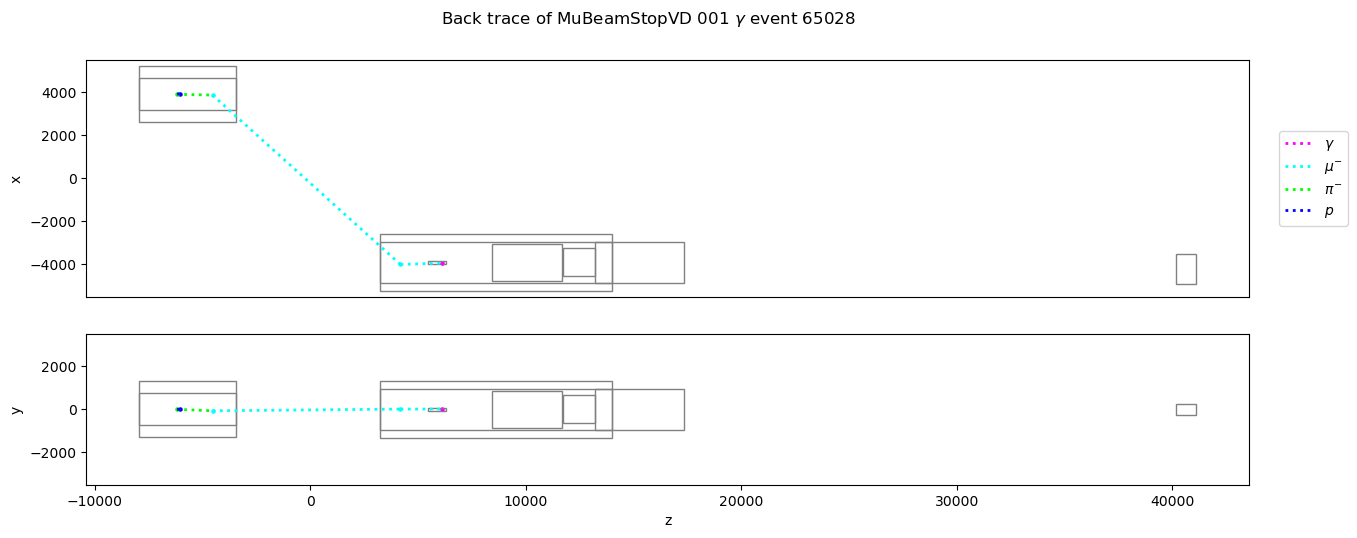

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                     1132.348656
creationCode                  115
index                       71512
pdgId                          22
px                    -274.080337
py                     488.174184
pz                     984.265926
startpx               -274.080336
startpy                 488.17417
startpz                984.265924
starttime              811.557922
startx               -3871.319759
starty                   8.091838
startz                6004.327992
time                   812.600445
virtualdetectorId              10
x                        -3946.97
y                      142.835158
z                     6275.999996
weight                          1
r                      149.158651
Name: 100000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   71512
parentendtime      151.462769
parentpdgId                13
starttime          811.557922
x                -3871.319759
y                    8.091838
z                 6004.327992
pdgId                      22
Name: 100000, dtype: object

,pdgId,startx,starty,startz
0,13,-3913.497480,-18.701372,4179.000000
1,13,3874.120261,-1.947244,-4602.018102
2,-211,3922.601090,0.584793,-6081.910037
3,2212,3928.745287,0.687679,-6057.302194


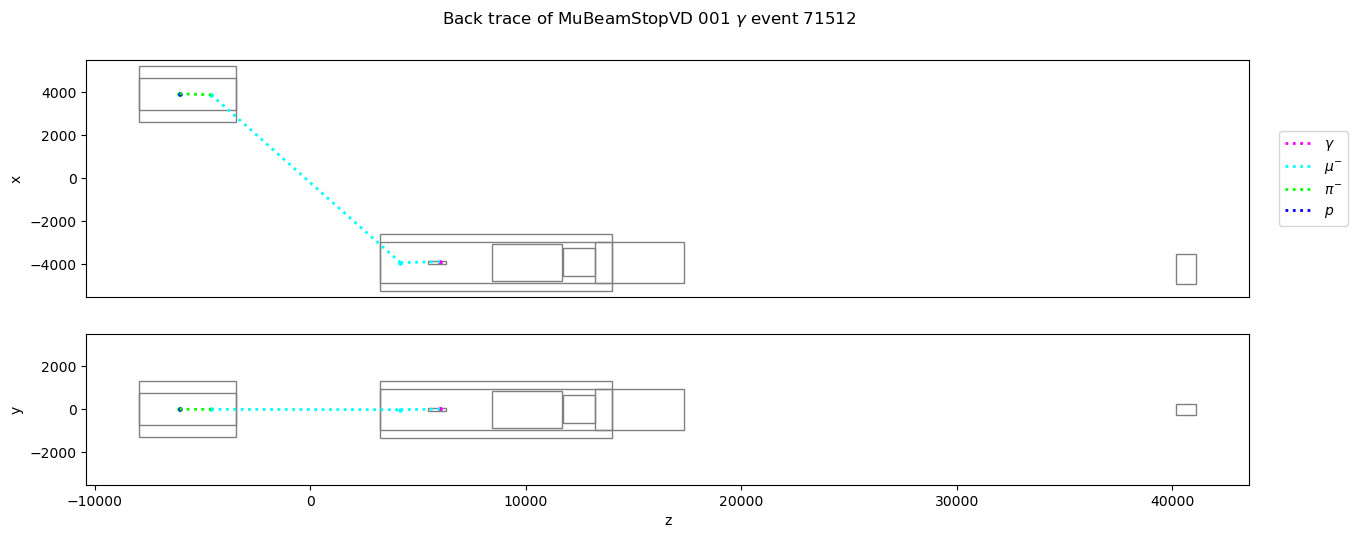

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      222.435175
creationCode                  115
index                       77923
pdgId                          22
px                     -42.055535
py                     -84.715081
pz                      201.32584
startpx                -42.055536
startpy                -84.715083
startpz                201.325834
starttime             1814.389404
startx                 -3852.7234
starty                  14.965532
startz                5648.822033
time                  1816.700826
virtualdetectorId              10
x                    -3983.736412
y                     -248.942131
z                     6275.999996
weight                          1
r                       261.40023
Name: 104000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   77923
parentendtime      188.458099
parentpdgId                13
starttime         1814.389404
x                  -3852.7234
y                   14.965532
z                 5648.822033
pdgId                      22
Name: 104000, dtype: object

,pdgId,startx,starty,startz
0,13,-3852.943798,-17.874121,4179.000000
1,13,3880.919584,-60.103826,-2465.765962
2,-211,3922.925870,0.282158,-6093.351350
3,2112,3922.212694,-0.988643,-6091.776623
4,2212,3930.611767,-0.876367,-6057.767559


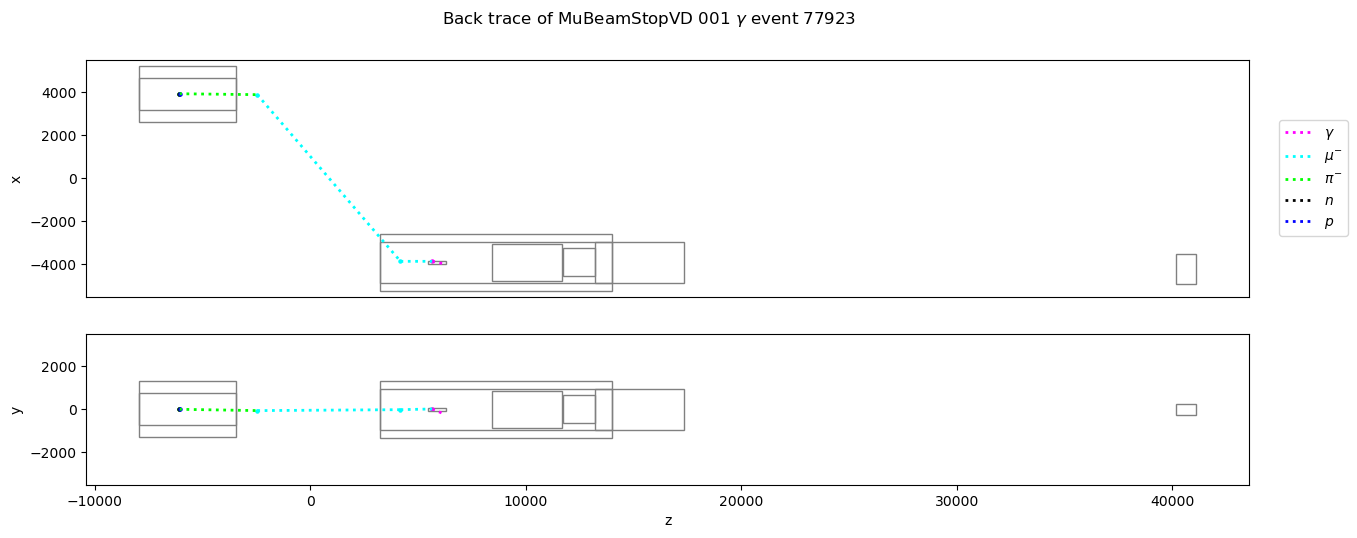

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                       53.642849
creationCode                  113
index                       84372
pdgId                          22
px                      -4.954009
py                     -39.489817
pz                     -35.966198
startpx                  39.53021
startpy                 16.846156
startpz                 49.737547
starttime              166.713913
startx               -3904.299308
starty                 -34.645621
startz                5893.188753
time                   171.581181
virtualdetectorId              10
x                    -3377.380774
y                     -162.278375
z                     6276.019996
weight                          1
r                      551.055424
Name: 108000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              113
index                   84372
parentendtime      166.713913
parentpdgId                13
starttime          166.713913
x                -3904.299308
y                  -34.645621
z                 5893.188753
pdgId                      22
Name: 108000, dtype: object

,pdgId,startx,starty,startz
0,13,-3932.964666,-8.309844,4179.000000
1,13,3916.811690,-56.280100,-6069.050019
2,-211,3928.767037,8.375452,-6092.796885
3,3122,3924.865101,-1.015837,-6079.728466
4,3212,3924.865101,-1.015837,-6079.728466
5,2212,3930.387177,-1.049906,-6057.711563


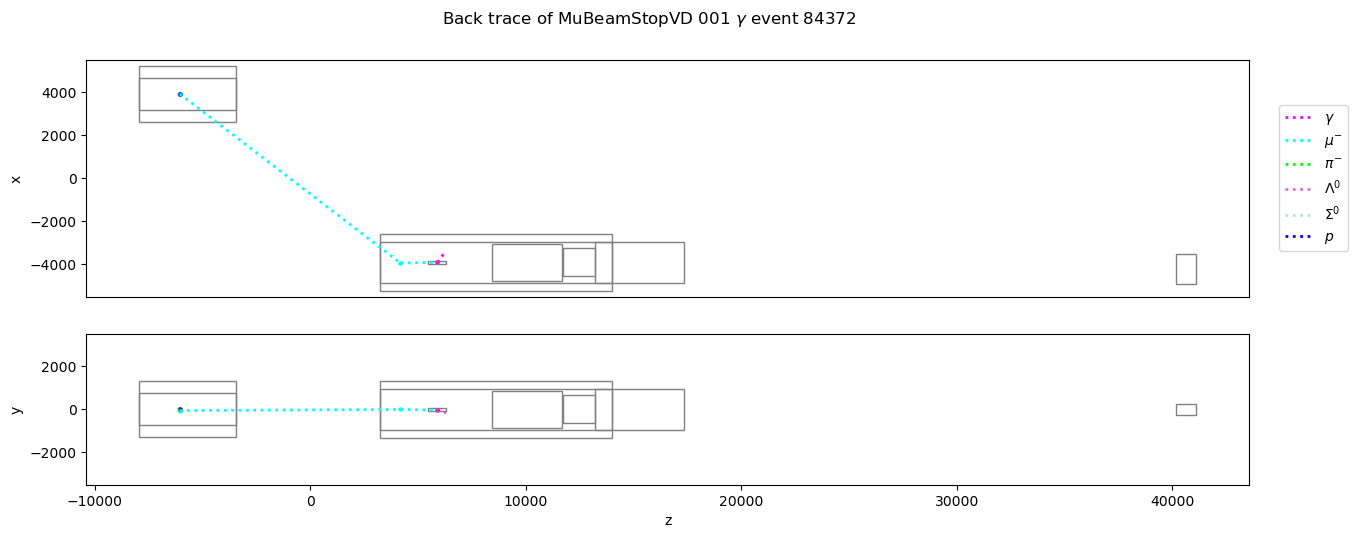

===================== 2112 28205
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      121.798501
creationCode                  115
index                          10
pdgId                        2112
px                     161.083122
py                  -11042.427929
pz                   10340.646895
startpx                161.083117
startpy             -11042.428017
startpz              10340.646744
starttime              632.987488
startx                -3871.19547
starty                  55.244363
startz                5982.083367
time                   722.079585
virtualdetectorId              10
x                    -3866.616935
y                     -258.619288
z                     6275.999996
weight                          1
r                      261.307156
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                      10
parentendtime      154.949646
parentpdgId                13
starttime          632.987488
x                 -3871.19547
y                   55.244363
z                 5982.083367
pdgId                    2112
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3896.838584,75.542371,4179.000000
1,13,2278.305619,115.455041,-301.396978
2,-211,3926.505619,-3.502054,-6097.251278
3,3122,3924.458908,0.375550,-6092.158353
4,2212,3932.893437,0.407881,-6058.336444


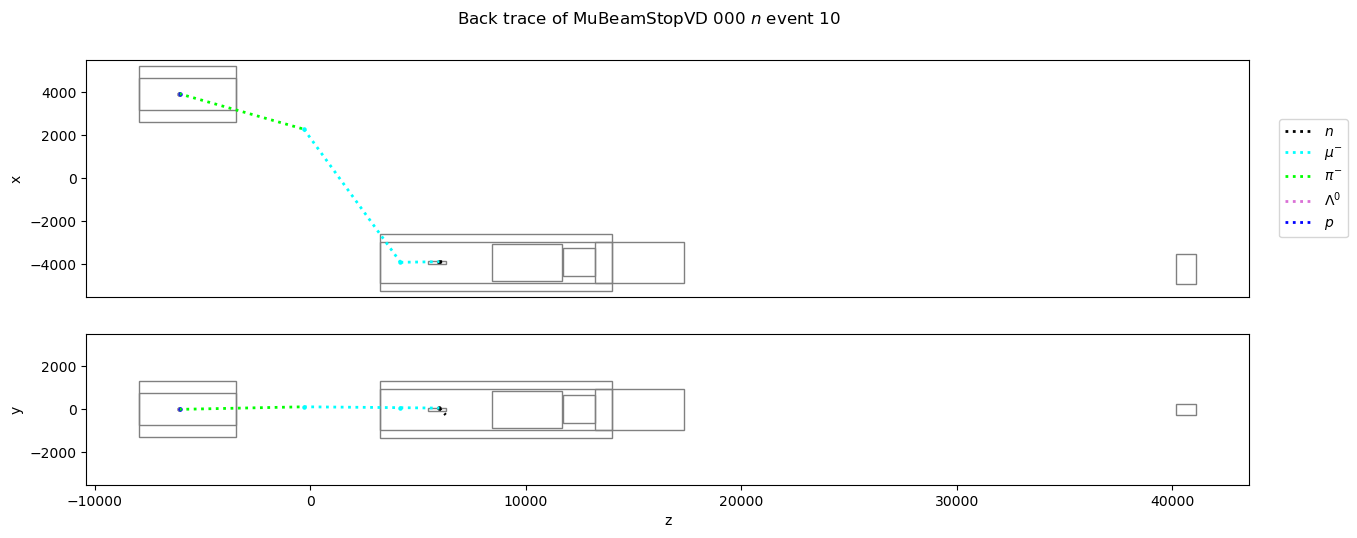

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                        0.074283
creationCode                  115
index                       25378
pdgId                        2112
px                     220.333632
py                    -122.399395
pz                     275.786755
startpx             -15337.491989
startpy               28570.69397
startpz              -6536.563396
starttime             1001.709045
startx               -3898.555737
starty                  51.277743
startz                5537.638477
time                  12905.04674
virtualdetectorId              10
x                    -3491.900879
y                     -129.490232
z                     6275.999996
weight                          1
r                      431.964589
Name: 4000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                   25378
parentendtime      407.786591
parentpdgId                13
starttime         1001.709045
x                -3898.555737
y                   51.277743
z                 5537.638477
pdgId                    2112
Name: 4000, dtype: object

,pdgId,startx,starty,startz
0,13,-3870.240281,75.365025,4179.000000
1,13,3902.352669,2.503830,-4512.247017
2,-211,3911.067414,-0.938421,-6133.106938
3,2212,3930.067304,-1.177619,-6057.631810


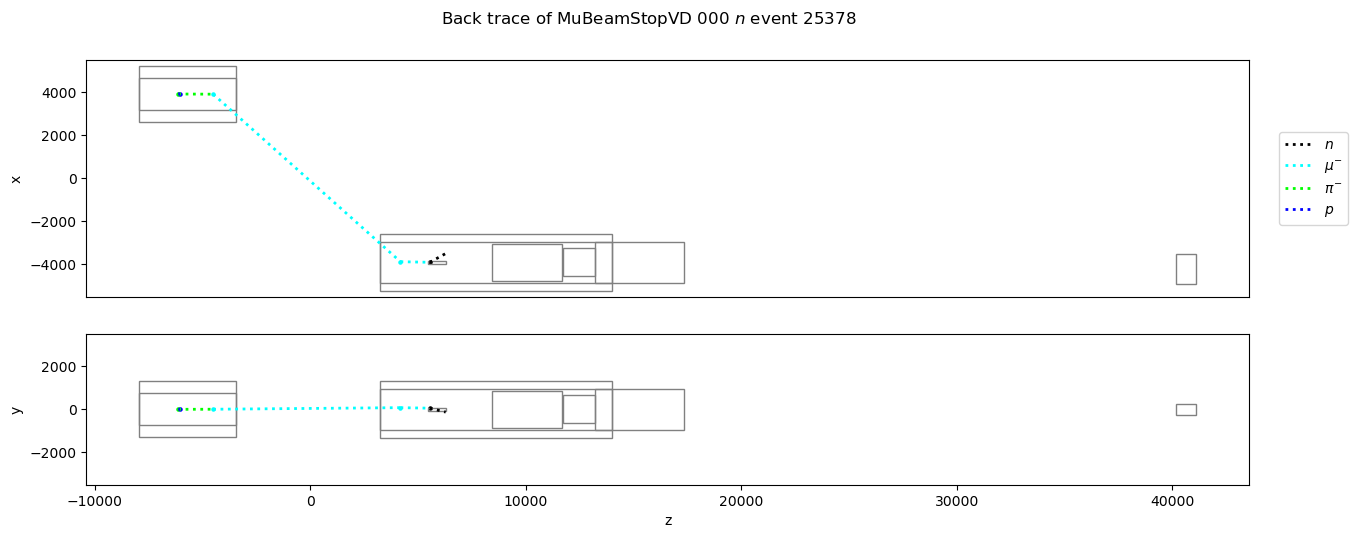

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                         1.33063
creationCode                  115
index                       49485
pdgId                        2112
px                    -662.473532
py                    -428.930635
pz                   -1370.246737
startpx             -64032.577515
startpy             -25379.764557
startpz              30477.249146
starttime             1899.889038
startx               -3929.707258
starty                  45.040593
startz                5826.538446
time                  2483.746353
virtualdetectorId              10
x                    -3829.612563
y                      540.895503
z                     6276.019996
weight                          1
r                      545.986663
Name: 8000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                   49485
parentendtime      172.279953
parentpdgId                13
starttime         1899.889038
x                -3929.707258
y                   45.040593
z                 5826.538446
pdgId                    2112
Name: 8000, dtype: object

,pdgId,startx,starty,startz
0,13,-3894.235252,78.581854,4179.000000
1,13,3109.243307,105.340588,-894.216506
2,-211,3916.921403,0.816630,-6113.065085
3,2212,3930.851767,0.201677,-6057.827398


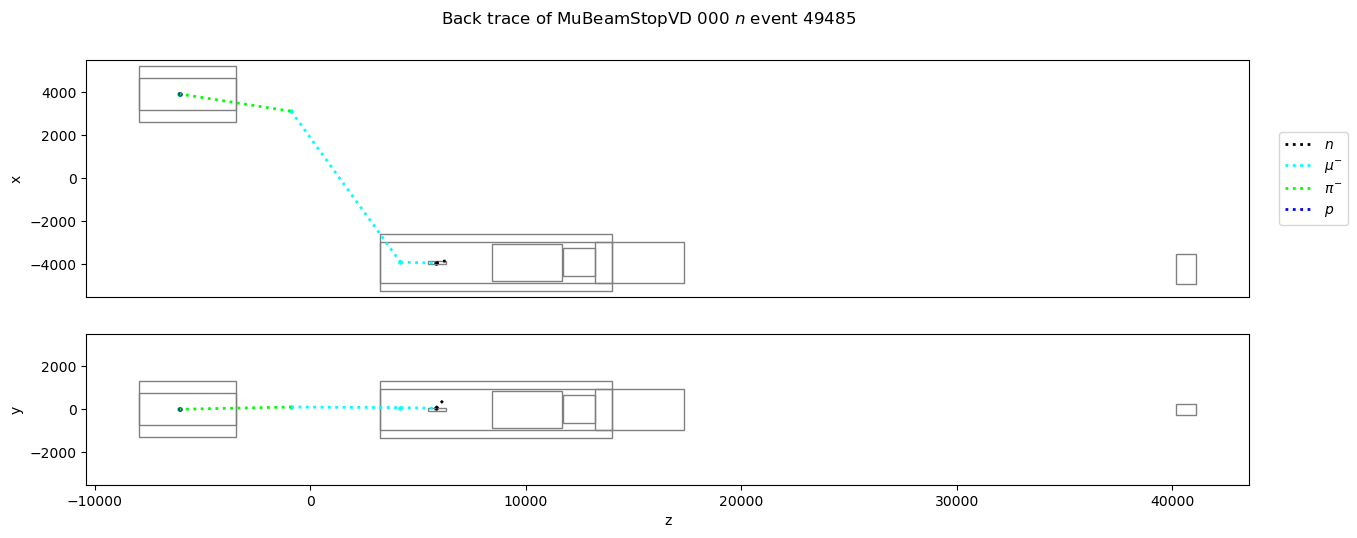

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       15.954207
creationCode                  115
index                       74683
pdgId                        2112
px                   -2280.528325
py                    3880.549672
pz                    3117.822937
startpx              -6190.077782
startpy             -28928.955078
startpz               1552.779436
starttime              2462.81665
startx                -3897.36767
starty                 -30.869923
startz                5693.189278
time                   3405.72506
virtualdetectorId              10
x                    -4213.568862
y                       81.593392
z                     6275.999996
weight                          1
r                      320.141159
Name: 12000, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                   74683
parentendtime      177.256363
parentpdgId                13
starttime          2462.81665
x                 -3897.36767
y                  -30.869923
z                 5693.189278
pdgId                    2112
Name: 12000, dtype: object

,pdgId,startx,starty,startz
0,13,-3935.979422,-21.662615,4179.000000
1,13,601.546890,91.431123,26.051494
2,-211,3892.892475,0.987926,-6199.517313
3,2212,3894.765175,1.290818,-6194.406585
4,2212,3930.025145,0.924496,-6057.621298


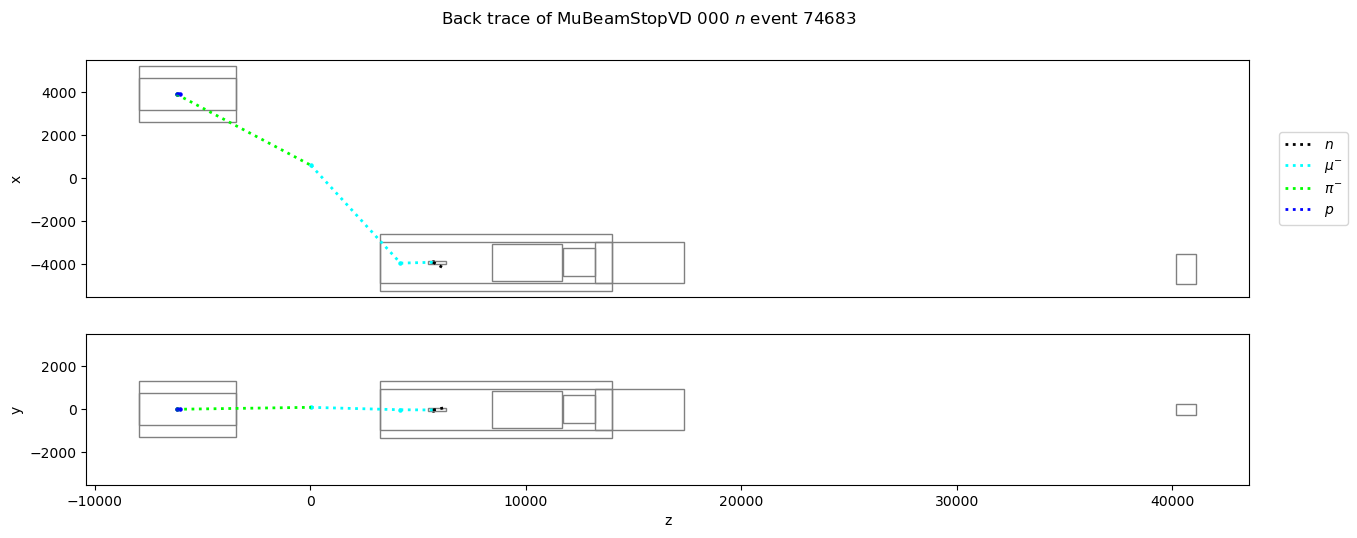

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           1
E                      7322.641818
creationCode                   115
index                         9724
pdgId                         2112
px                    50652.446043
py                    19207.059794
pz                   104303.599362
startpx               50652.446747
startpy                19207.05986
startpz              104303.596497
starttime               834.514893
startx                -3875.540363
starty                  -28.315622
startz                 5493.172995
time                    858.220155
virtualdetectorId               10
x                     -3495.379921
y                       115.838608
z                      6275.999996
weight                           1
r                       424.722205
Name: 16000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                    9724
parentendtime      267.734131
parentpdgId                13
starttime          834.514893
x                -3875.540363
y                  -28.315622
z                 5493.172995
pdgId                    2112
Name: 16000, dtype: object

,pdgId,startx,starty,startz
0,13,-3877.024289,-16.390809,4179.000000
1,13,3883.415940,-32.799669,-2599.823756
2,-211,3924.618221,-0.980218,-6079.198824
3,2212,3930.020830,-0.984290,-6057.620222


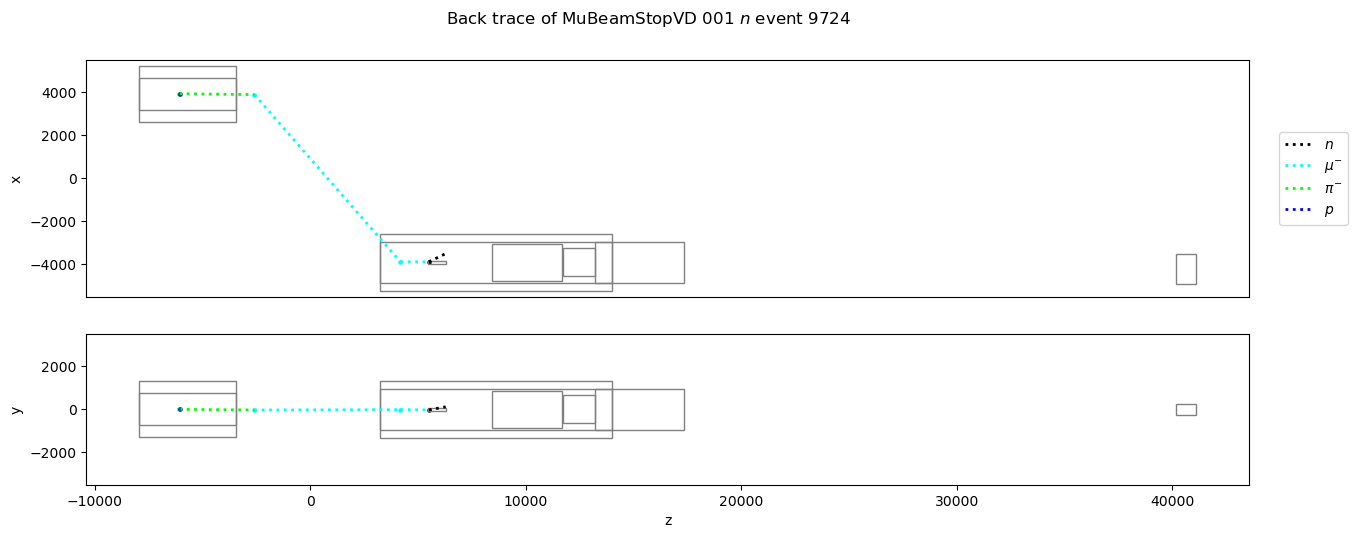

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                     3522.053521
creationCode                  115
index                       34539
pdgId                        2112
px                  -42916.204086
py                  -49810.615475
pz                   48040.668633
startpx             -42916.202545
startpy              -49810.61554
startpz              48040.668488
starttime              344.608551
startx               -3951.721073
starty                   4.074839
startz                6248.829845
time                    346.38772
virtualdetectorId              10
x                    -3975.993003
y                      -24.096333
z                     6275.999996
weight                          1
r                       75.918547
Name: 20000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   34539
parentendtime      136.623489
parentpdgId                13
starttime          344.608551
x                -3951.721073
y                    4.074839
z                 6248.829845
pdgId                    2112
Name: 20000, dtype: object

,pdgId,startx,starty,startz
0,13,-3964.431911,11.688631,4179.000000
1,13,3875.773261,-20.479881,-5869.948497
2,-211,3917.863111,-0.393612,-6109.855388
3,2212,3930.891470,-0.058255,-6057.837297


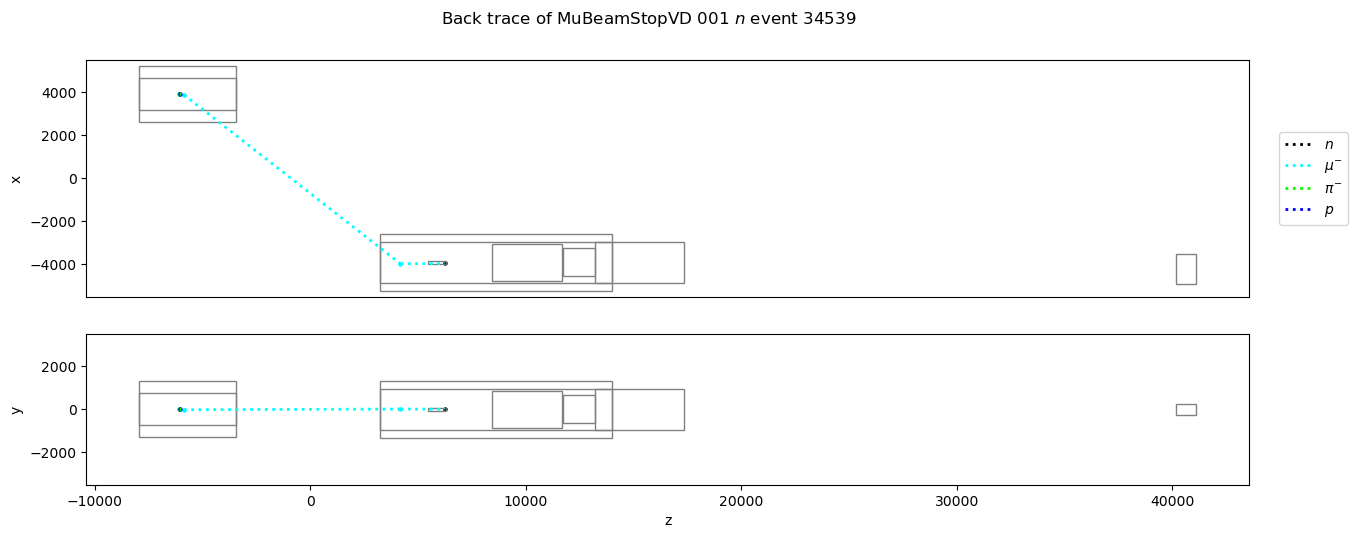

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          1
E                      887.403318
creationCode                   97
index                       59637
pdgId                        2112
px                    6552.110074
py                   21047.224754
pz                   34386.312737
startpx             -27368.347168
startpy              -6830.823421
startpz               57977.51236
starttime              940.508118
startx                -3519.66616
starty                -456.793654
startz                5574.448012
time                   998.005751
virtualdetectorId              10
x                    -3502.320553
y                     -155.534301
z                     6275.999996
weight                          1
r                      430.740406
Name: 24000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   59637
parentendtime      169.218155
parentpdgId                13
starttime          928.632202
x                -3878.956291
y                   43.491365
z                 5648.738824
pdgId                    2112
Name: 24000, dtype: object

,pdgId,startx,starty,startz
0,2112,-3878.956291,43.491365,5648.738824
1,13,-3859.922629,42.052184,4179.000000
2,13,3946.922069,12.344658,-3289.133435
3,-211,3913.546410,0.218868,-6127.070273
4,2212,3930.675965,-0.101828,-6057.783566


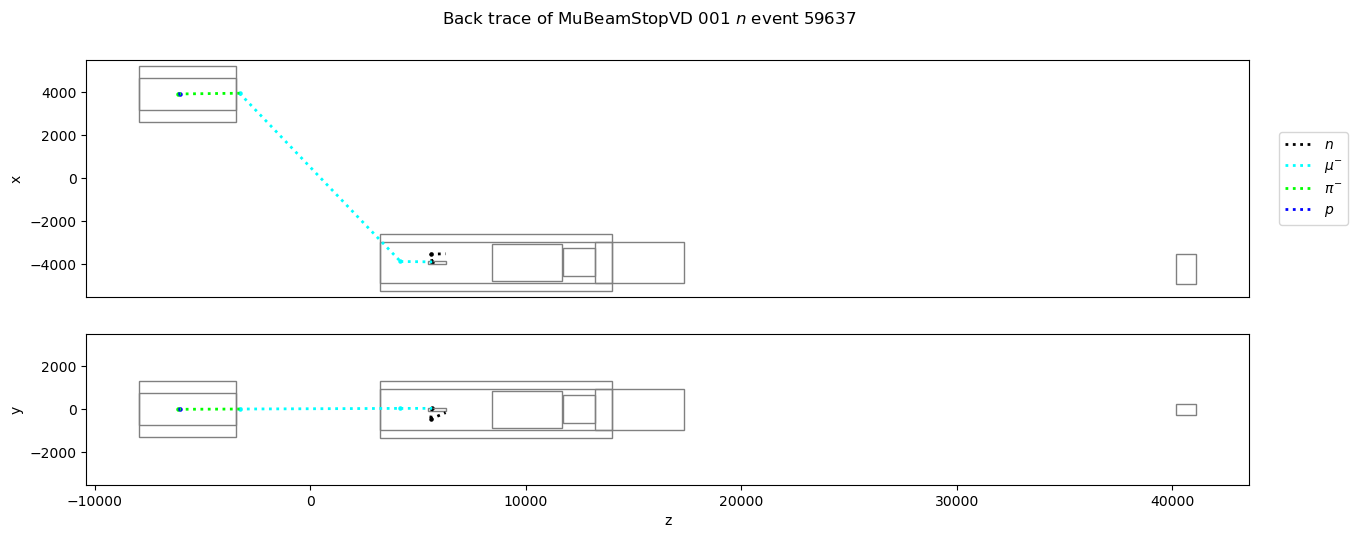

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           1
E                         0.000036
creationCode                   115
index                        83822
pdgId                         2112
px                        -4.22329
py                        2.093906
pz                       -6.733847
startpx               24006.706238
startpy               17767.969131
startpz                6338.114262
starttime               509.003784
startx                -3932.684609
starty                   21.915936
startz                 6137.662571
time                 1630125.43544
virtualdetectorId               10
x                     -3899.452289
y                      -269.029174
z                      6276.019996
weight                           1
r                       269.067608
Name: 28000, dtype: object

tag              MuBeamStopVD
fileno                      1
creationCode              115
index                   83822
parentendtime      119.516739
parentpdgId                13
starttime          509.003784
x                -3932.684609
y                   21.915936
z                 6137.662571
pdgId                    2112
Name: 28000, dtype: object

,pdgId,startx,starty,startz
0,13,-3934.951121,-2.655095,4179.000000
1,13,3848.087425,33.351142,-3945.535050
2,-211,3885.031469,-0.634605,-6240.339189
3,2212,3930.333407,-1.020131,-6057.698157


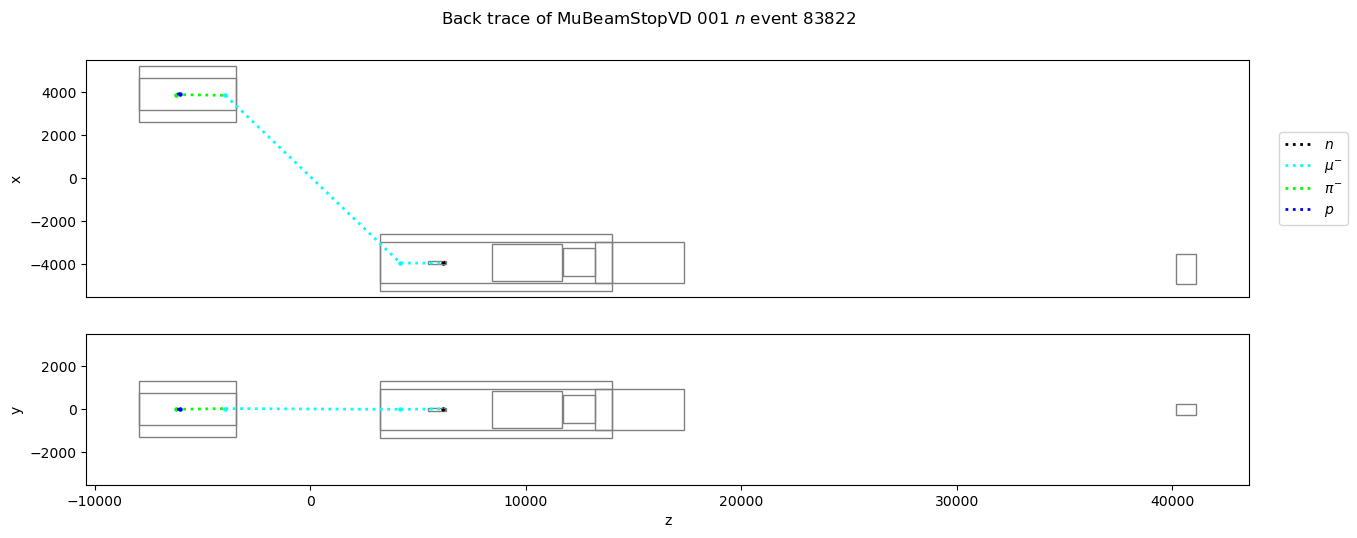

===================== 2212 1666
------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                     34693.397758
creationCode                   115
index                           69
pdgId                         2212
px                  -231083.024038
py                    68690.328105
pz                    90496.387547
startpx             -176625.350952
startpy             -173075.454712
startpz               91837.867737
starttime              1712.839478
startx                -3857.078407
starty                  -28.507351
startz                 6048.761817
time                   1721.147487
virtualdetectorId               10
x                     -4430.613398
y                       -169.66886
z                      6275.999996
weight                           1
r                       553.271355
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                      69
parentendtime      188.791656
parentpdgId                13
starttime         1712.839478
x                -3857.078407
y                  -28.507351
z                 6048.761817
pdgId                    2212
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3907.157756,3.463251,4179.000000
1,13,3910.239694,-32.936537,-5543.924759
2,-211,3889.587334,-0.035356,-6221.409813
3,2212,3932.068679,0.279195,-6058.130808


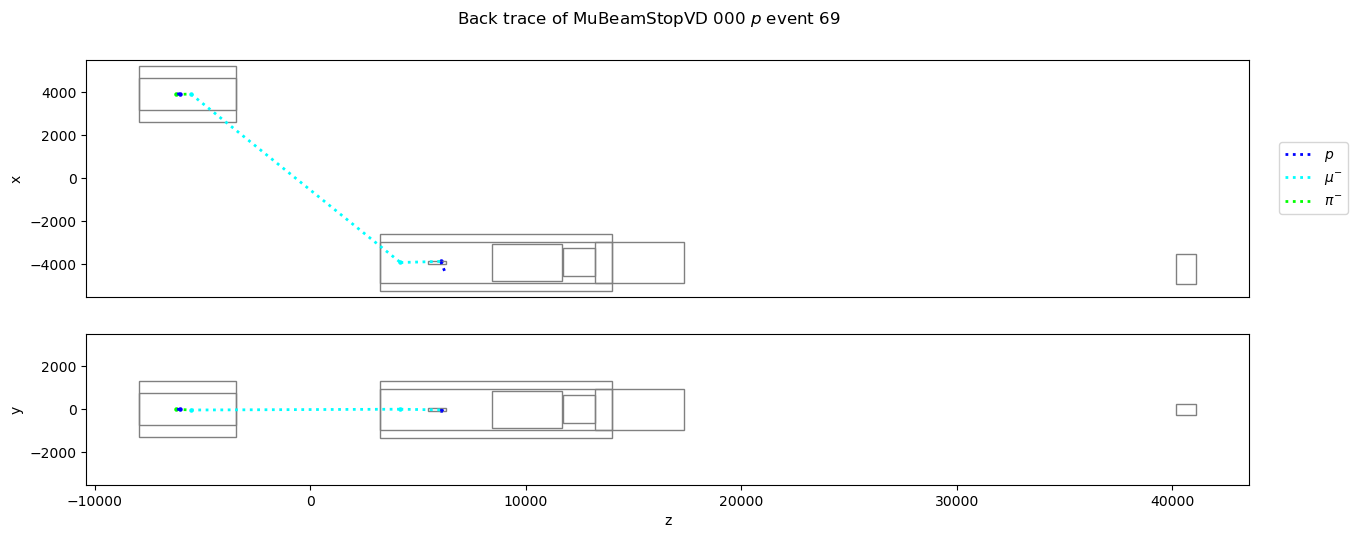

===================== 1000010020 93
------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                      6452.400443
creationCode                   115
index                         1749
pdgId                   1000010020
px                   -93713.442815
py                   101597.111116
pz                    71706.517905
startpx             -154334.411621
startpy              -16871.446609
startpz               86142.929077
starttime               1143.82019
startx                -3946.040613
starty                    -9.00836
startz                 6115.448252
time                   1157.994026
virtualdetectorId               10
x                       -4228.2716
y                         96.62503
z                      6275.999996
weight                           1
r                       338.361444
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                    1749
parentendtime      175.601624
parentpdgId                13
starttime          1143.82019
x                -3946.040613
y                    -9.00836
z                 6115.448252
pdgId              1000010020
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3912.302123,15.255516,4179.000000
1,13,-441.684335,109.146746,-17.962172
2,-211,3924.447956,-0.274983,-6079.459766
3,2212,3929.898572,-0.260878,-6057.589740


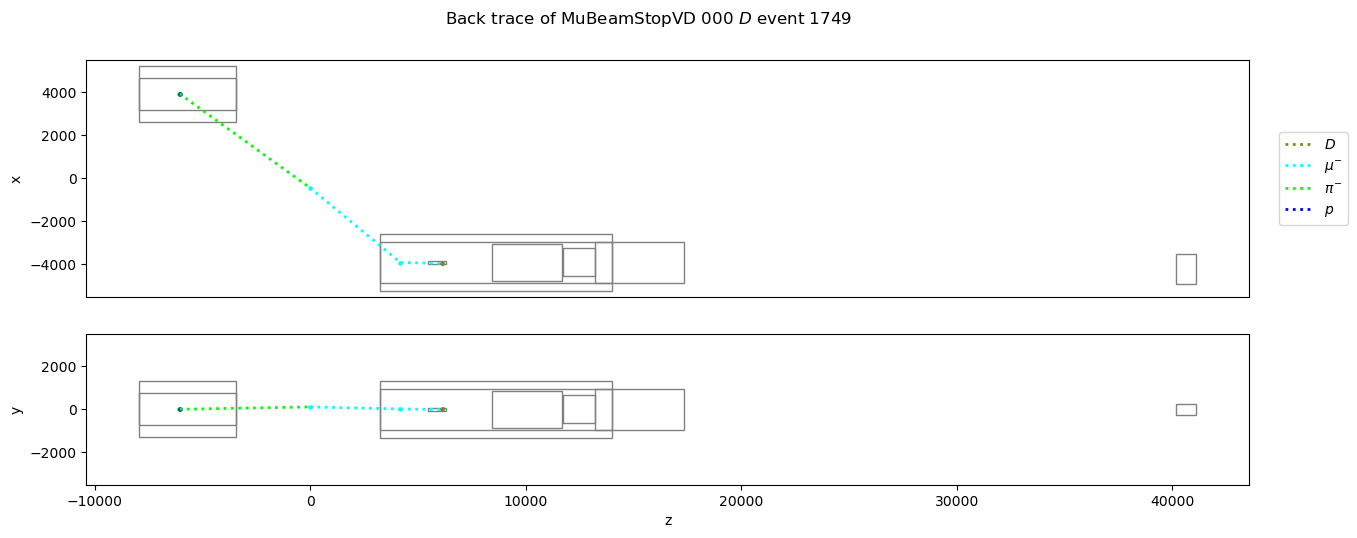

===================== 1000010030 19
------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                       2517.77364
creationCode                   115
index                         8591
pdgId                   1000010030
px                     5274.573848
py                    -75118.78117
pz                    92096.677286
startpx               -6903.399467
startpy              168206.665039
startpz              205482.910156
starttime              2022.952759
startx                -3843.298358
starty                   -0.174776
startz                 5626.518941
time                   2089.040895
virtualdetectorId               10
x                      -3476.96451
y                        17.096648
z                      6275.999996
weight                           1
r                       427.377591
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                    8591
parentendtime      467.114044
parentpdgId                13
starttime         2022.952759
x                -3843.298358
y                   -0.174776
z                 5626.518941
pdgId              1000010030
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3835.450598,-48.955077,4179.000000
1,13,3983.918453,-9.893418,-5456.009807
2,-211,3920.420407,-2.008793,-6095.084338
3,2212,3929.814381,-1.849425,-6057.568749


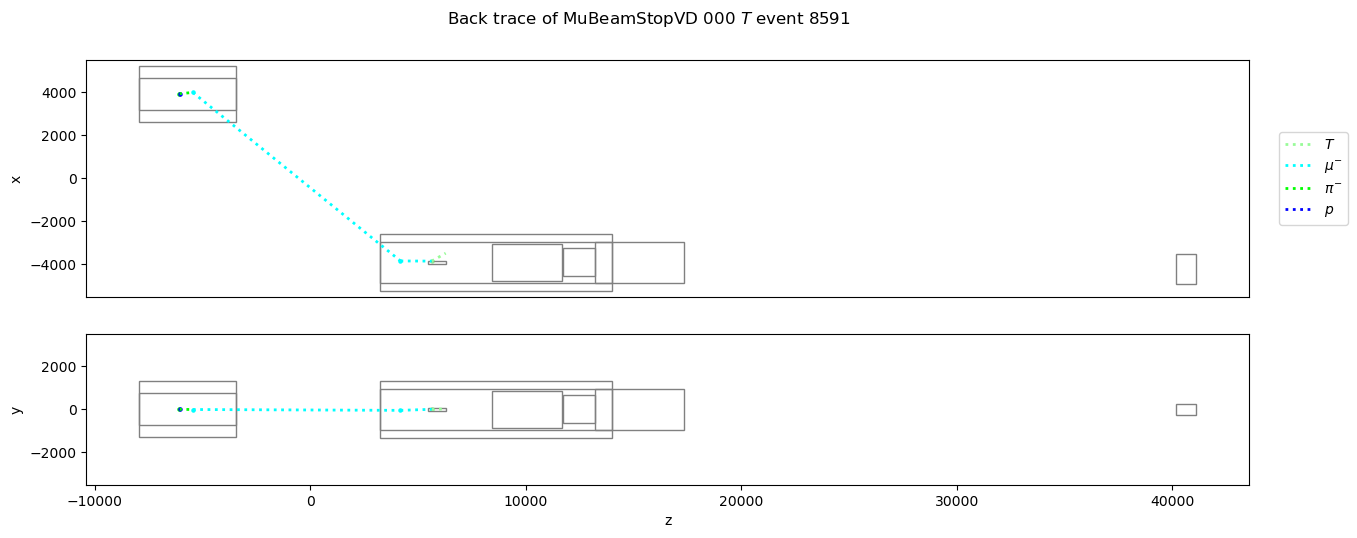

===================== 1000020040 42
------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                      3700.948486
creationCode                   115
index                         2720
pdgId                   1000020040
px                   114621.926089
py                  -100533.464526
pz                    66019.030589
startpx               14637.672424
startpy              249297.271729
startpz               80180.580139
starttime               480.808258
startx                -3832.535596
starty                   17.763793
startz                 5715.485017
time                    602.287029
virtualdetectorId               10
x                     -3524.134844
y                       147.147293
z                      6275.999996
weight                           1
r                       407.369442
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                    2720
parentendtime      345.365356
parentpdgId                13
starttime          480.808258
x                -3832.535596
y                   17.763793
z                 5715.485017
pdgId              1000020040
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3817.738778,-1.632981,4179.000000
1,13,3986.771879,9.896969,-4628.947678
2,-211,3885.934755,2.203370,-6239.019950
3,2212,3930.978984,0.923319,-6057.859117


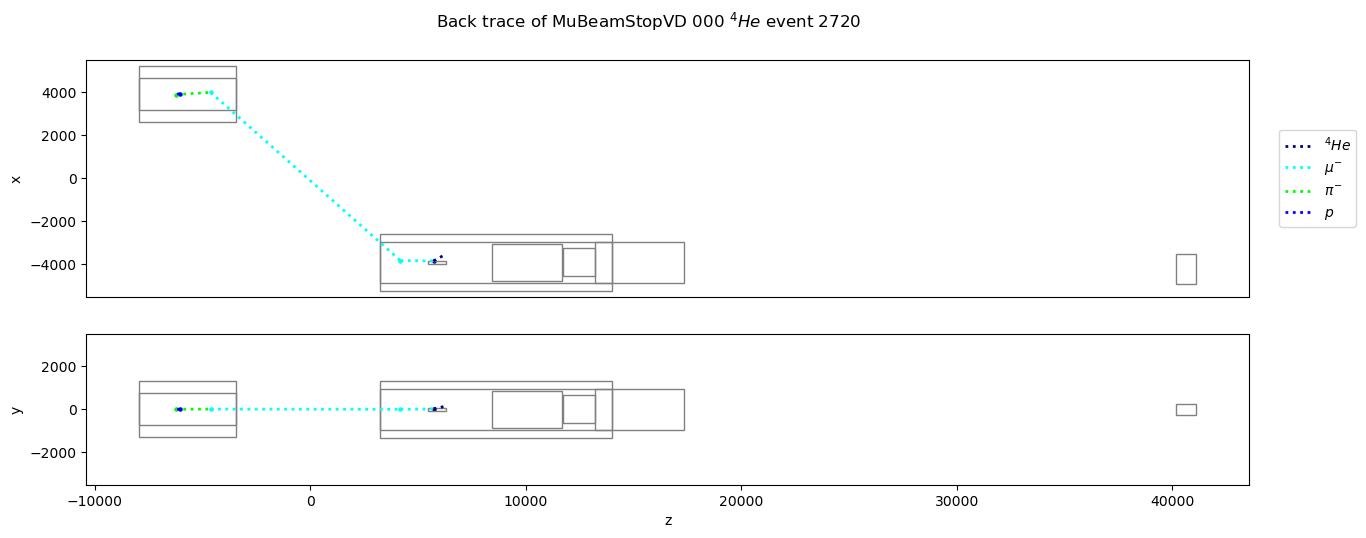

===================== 1000120270 1
------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       86.072953
creationCode                  115
index                       36035
pdgId                  1000120270
px                   59866.776928
py                  -25333.736912
pz                   10006.796989
startpx              32684.444427
startpy              54425.788879
startpz              73233.222961
starttime              632.321167
startx               -3859.359034
starty                 -55.689755
startz                6271.052676
time                   672.452576
virtualdetectorId              10
x                    -3842.307859
y                      -38.458757
z                     6275.999996
weight                          1
r                       72.697979
Name: 0, dtype: object

tag              MuBeamStopVD
fileno                      0
creationCode              115
index                   36035
parentendtime      217.821671
parentpdgId                13
starttime          632.321167
x                -3859.359034
y                  -55.689755
z                 6271.052676
pdgId              1000120270
Name: 0, dtype: object

,pdgId,startx,starty,startz
0,13,-3816.519312,-16.689457,4179.000000
1,13,3908.864639,1.876047,-4718.060426
2,-211,3909.750869,0.919090,-6141.511102
3,2212,3930.531260,1.449357,-6057.747487


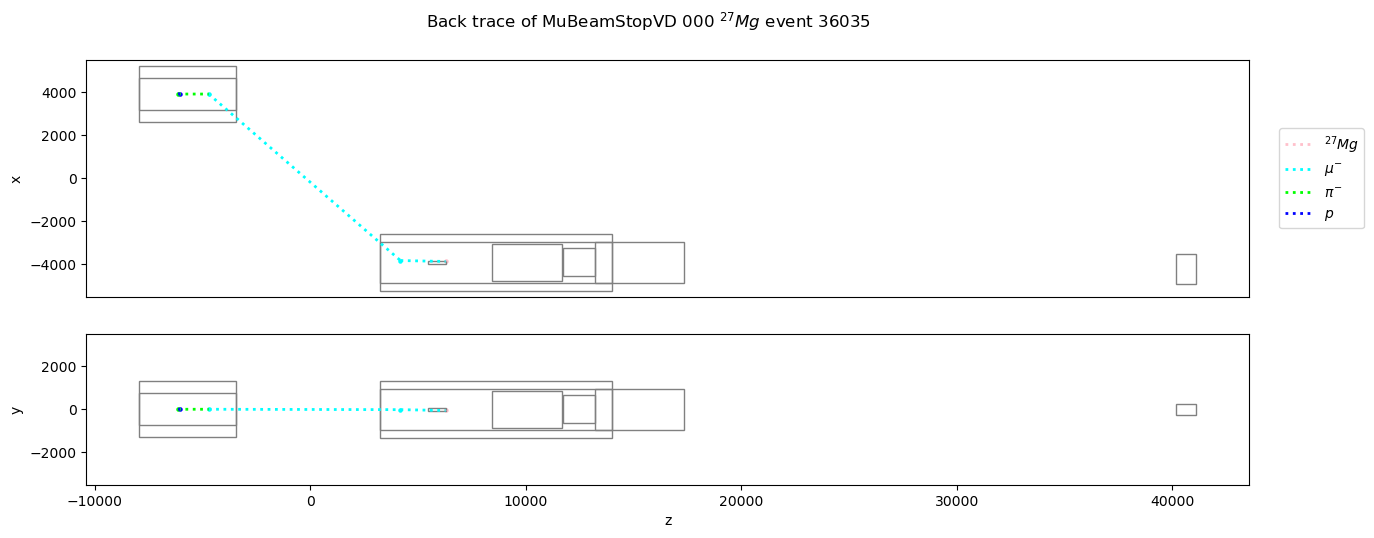

In [6]:
rdf_genealogy = [ROOT.RDataFrame("ParticleBackTracer/ttree_genealogy", filename) for filename in fileList]
for pdgId in list_of_pdgId:
    print('=====================', pdgId, len(df_by_pdgid[pdgId][0]))
    for ii in range(0, len(df_by_pdgid[pdgId][0]), 4000):
        print('------------------------------------------------------------------------------')
        dfp_ = df_by_pdgid[pdgId][0].iloc[ii]
        dfs_ = df_by_pdgid[pdgId][1].iloc[ii]
        fileno, index = dfp_['fileno'], dfp_['index']

        rdfg_ = rdf_genealogy[fileno].Filter("index==%i"%index)
        dfg_ = pd.DataFrame(rdfg_.AsNumpy(columns = ["pdgId", "startx", "starty", "startz"]))
        
        display(dfp_)
        display(dfs_)
        display(dfg_)
        fig, ax_top, ax_side = plot_utils.draw_particle_event_backtrace(dfp_, dfg_, tag, fileno, index)
        plt.show()

------------------------------------------------------------------------------
Parent pdgId:  22 $\gamma$
count:  10
creationCode
13    10
Name: count, dtype: int64
******
Parent pdgId:  1000120230 1000120230
count:  20
creationCode
74    20
Name: count, dtype: int64
******


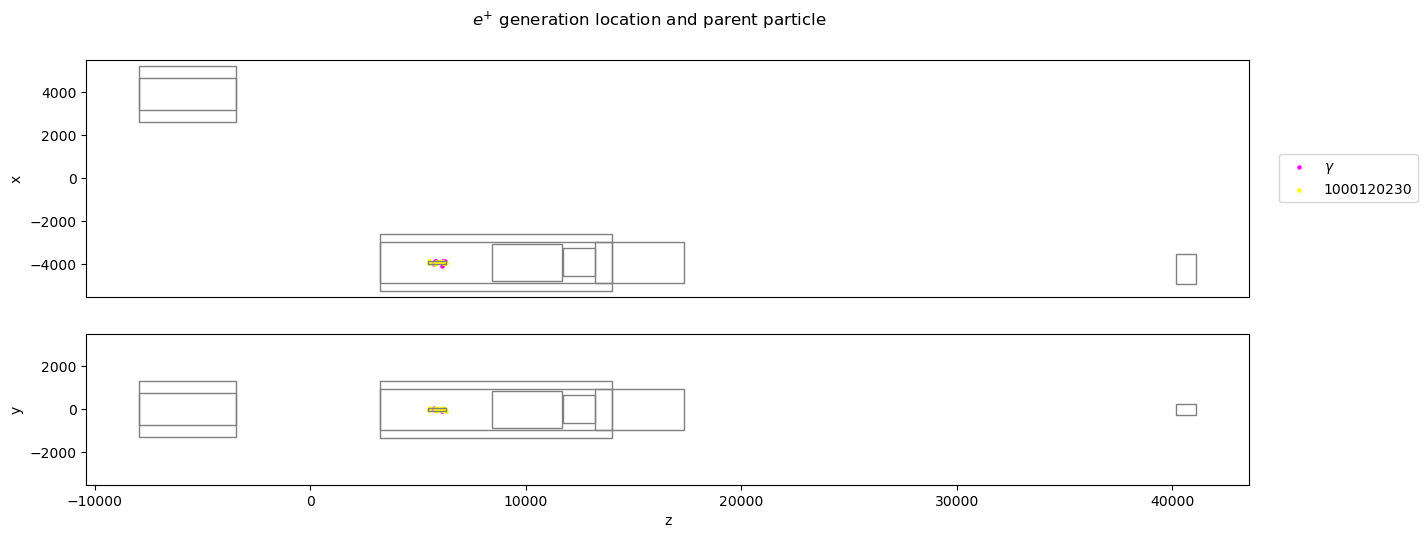

------------------------------------------------------------------------------
Parent pdgId:  -11 $e^{+}$
count:  3
creationCode
17    3
Name: count, dtype: int64
******
Parent pdgId:  13 $\mu^{-}$
count:  34022
creationCode
114    33557
113      373
31        92
Name: count, dtype: int64
******
Parent pdgId:  22 $\gamma$
count:  124
creationCode
12    100
13     17
40      7
Name: count, dtype: int64
******
Parent pdgId:  2212 $p$
count:  3
creationCode
21    3
Name: count, dtype: int64
******
Parent pdgId:  1000080200 1000080200
count:  1
creationCode
74    1
Name: count, dtype: int64
******
Parent pdgId:  1000090200 1000090200
count:  12
creationCode
74    12
Name: count, dtype: int64
******
Parent pdgId:  1000090210 1000090210
count:  15
creationCode
74    15
Name: count, dtype: int64
******
Parent pdgId:  1000100230 1000100230
count:  72
creationCode
74    72
Name: count, dtype: int64
******
Parent pdgId:  1000100240 1000100240
count:  18
creationCode
74    18
Name: count, dtype: 

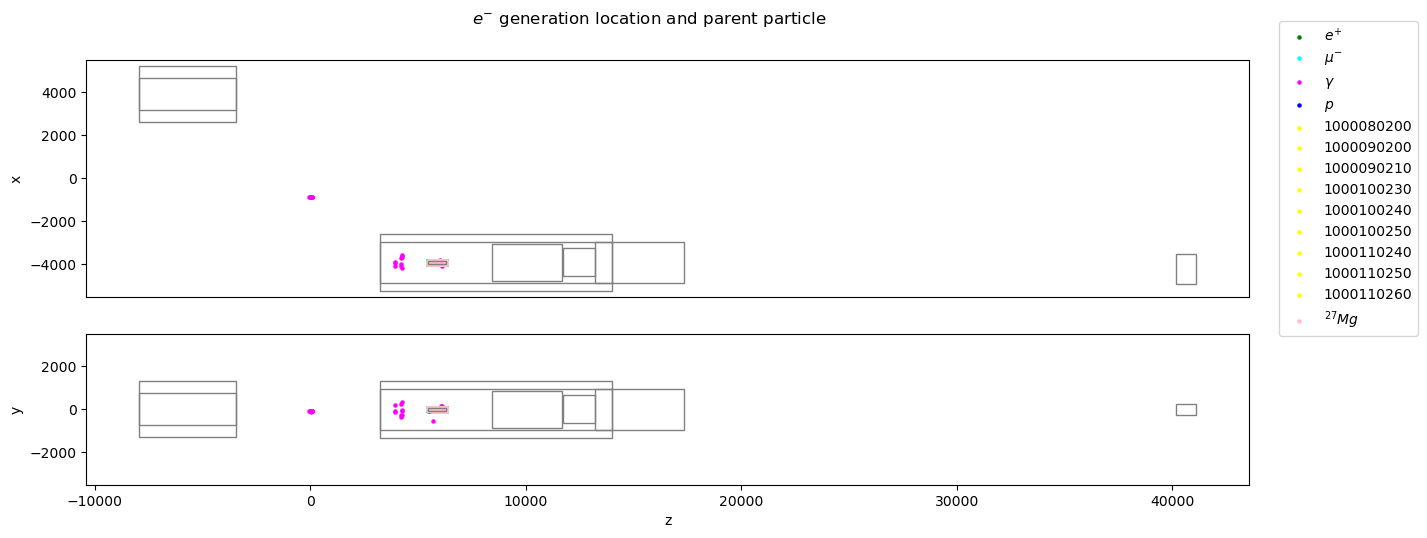

------------------------------------------------------------------------------
Parent pdgId:  -11 $e^{+}$
count:  850
creationCode
2     810
16     40
Name: count, dtype: int64
******
Parent pdgId:  11 $e^{-}$
count:  5016
creationCode
16    5016
Name: count, dtype: int64
******
Parent pdgId:  13 $\mu^{-}$
count:  90381
creationCode
113    56126
115    34255
Name: count, dtype: int64
******
Parent pdgId:  2112 $n$
count:  4882
creationCode
35    3090
97    1792
Name: count, dtype: int64
******
Parent pdgId:  2212 $p$
count:  8
creationCode
101    8
Name: count, dtype: int64
******
Parent pdgId:  1000010020 $D$
count:  1
creationCode
72    1
Name: count, dtype: int64
******
Parent pdgId:  1000020040 $^{4}He$
count:  1
creationCode
68    1
Name: count, dtype: int64
******
Parent pdgId:  1000080169 1000080169
count:  1
creationCode
74    1
Name: count, dtype: int64
******
Parent pdgId:  1000090191 1000090191
count:  2
creationCode
74    2
Name: count, dtype: int64
******
Parent pdgId:  10

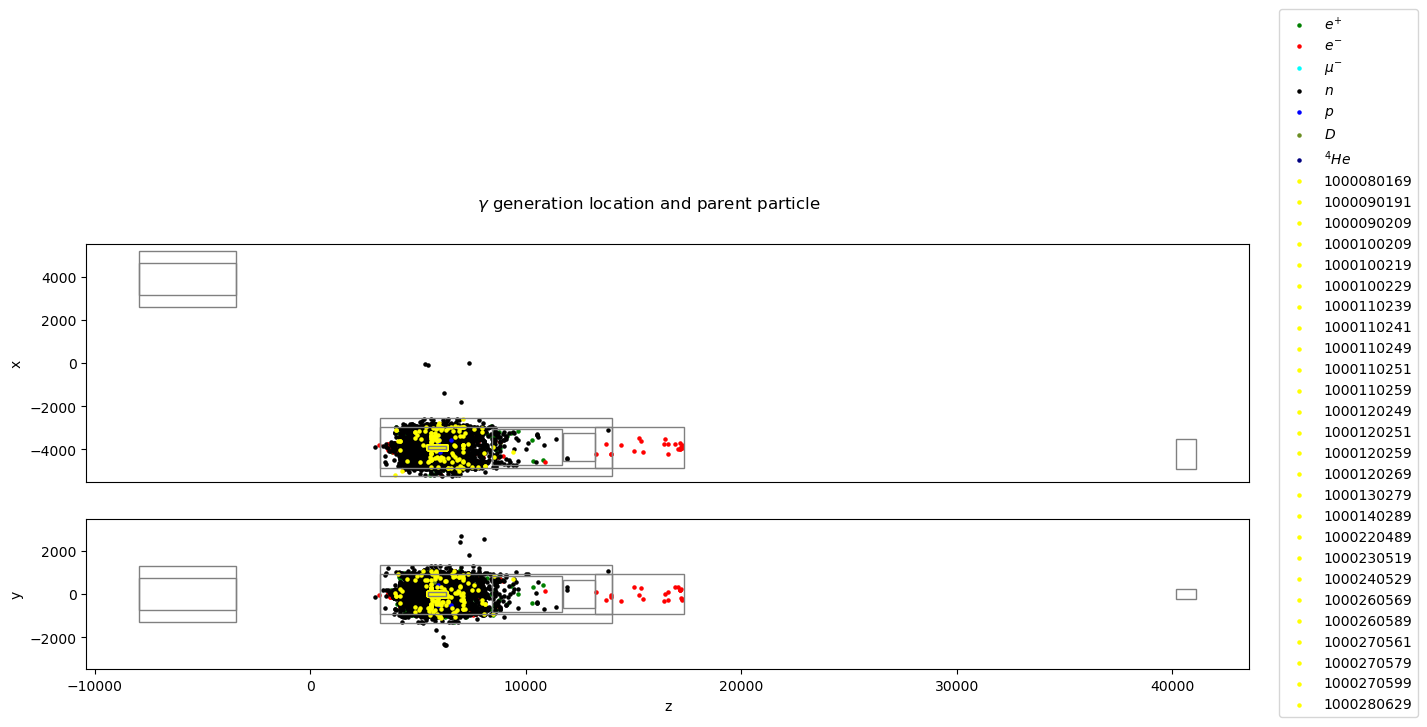

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  28202
creationCode
115    28202
Name: count, dtype: int64
******
Parent pdgId:  22 $\gamma$
count:  3
creationCode
109    3
Name: count, dtype: int64
******


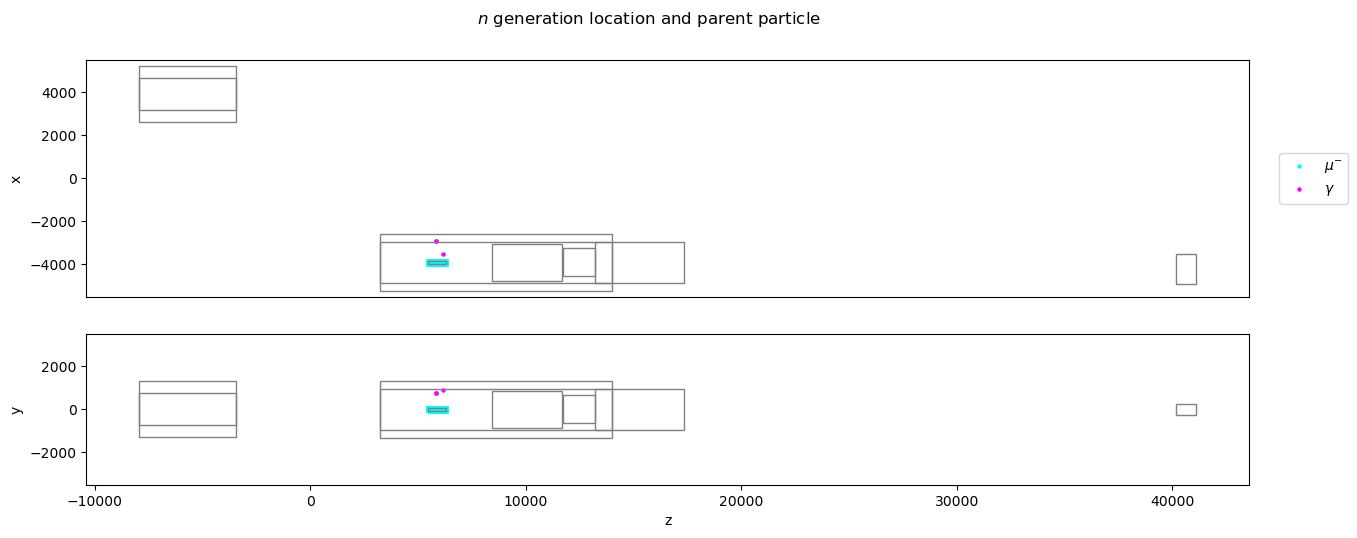

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  1664
creationCode
115    1664
Name: count, dtype: int64
******
Parent pdgId:  2112 $n$
count:  1
creationCode
58    1
Name: count, dtype: int64
******
Parent pdgId:  1000020040 $^{4}He$
count:  1
creationCode
68    1
Name: count, dtype: int64
******


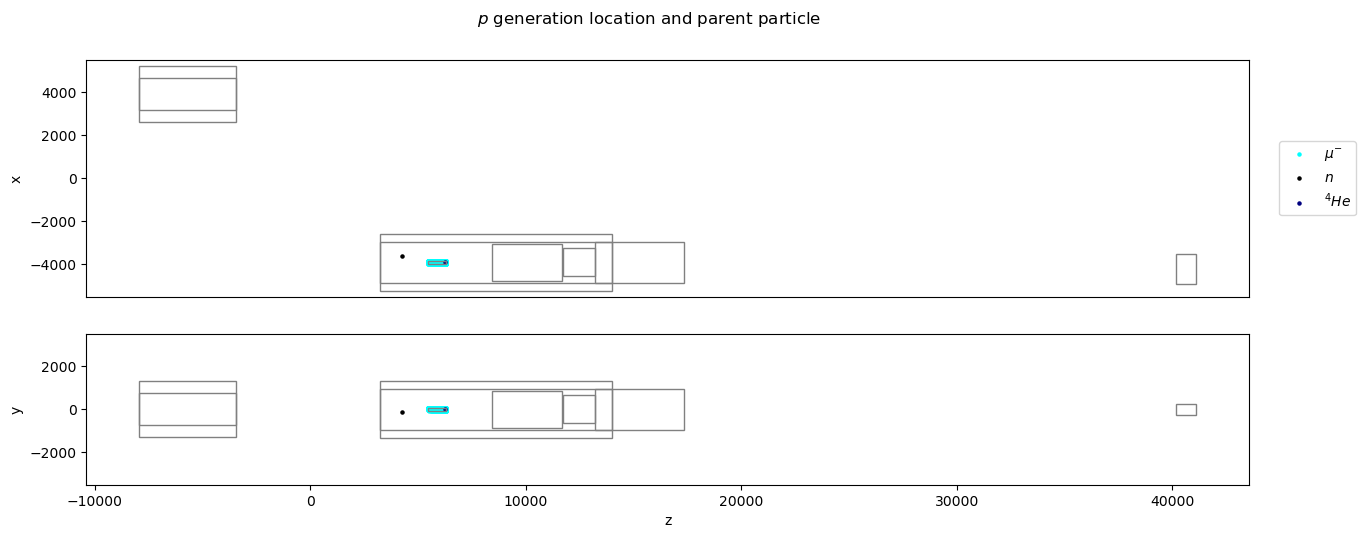

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  93
creationCode
115    93
Name: count, dtype: int64
******


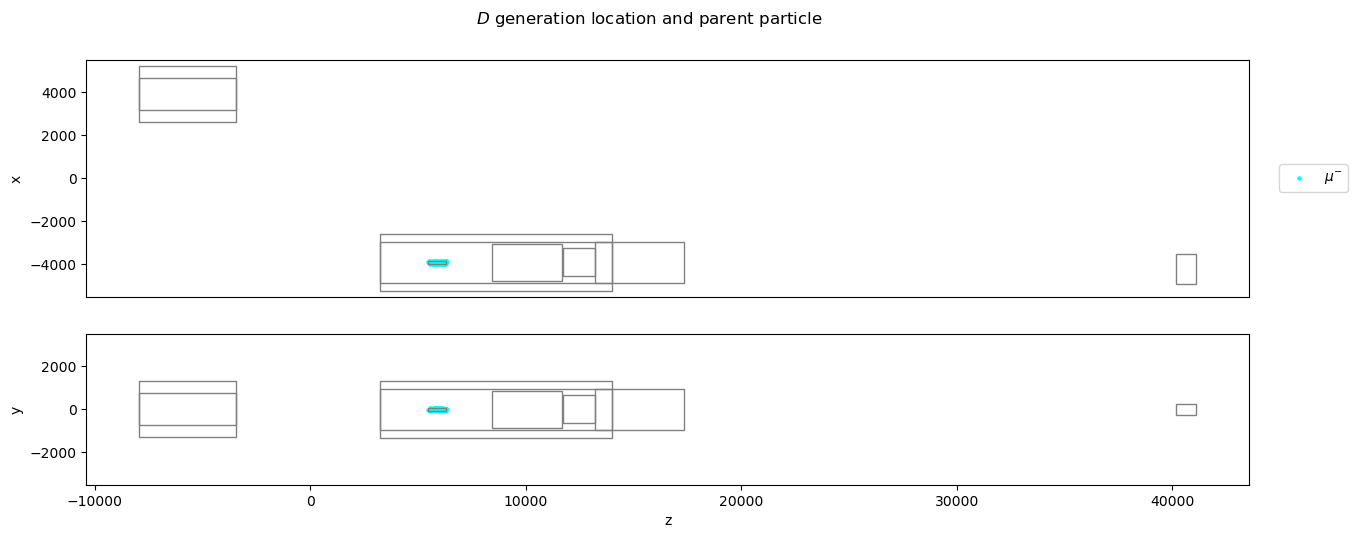

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  19
creationCode
115    19
Name: count, dtype: int64
******


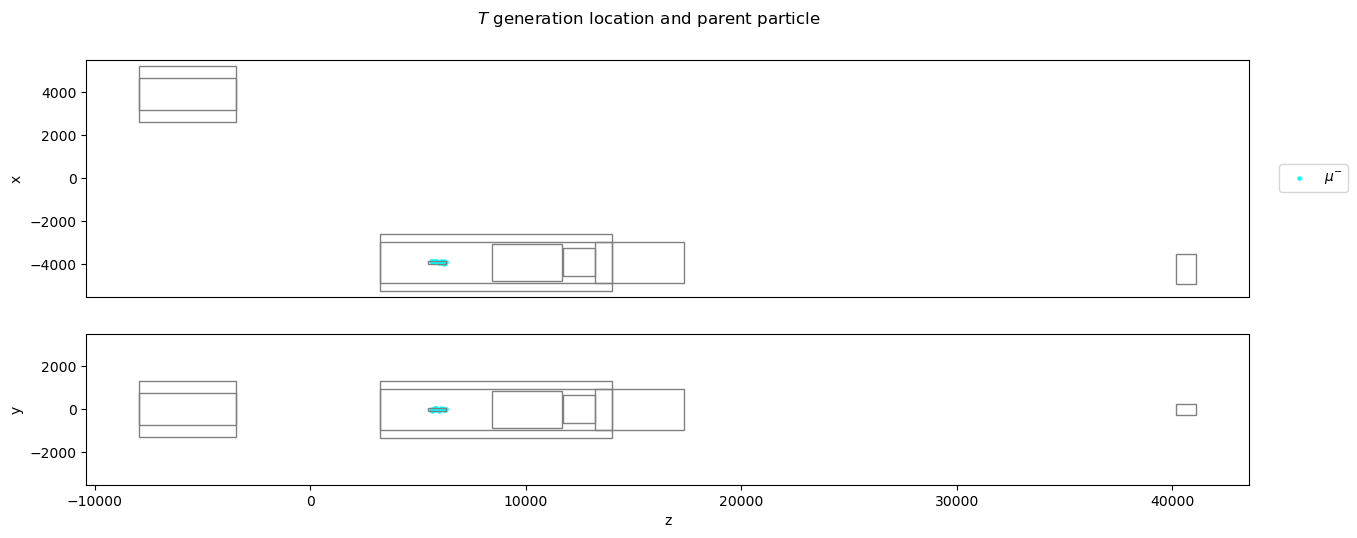

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  42
creationCode
115    42
Name: count, dtype: int64
******


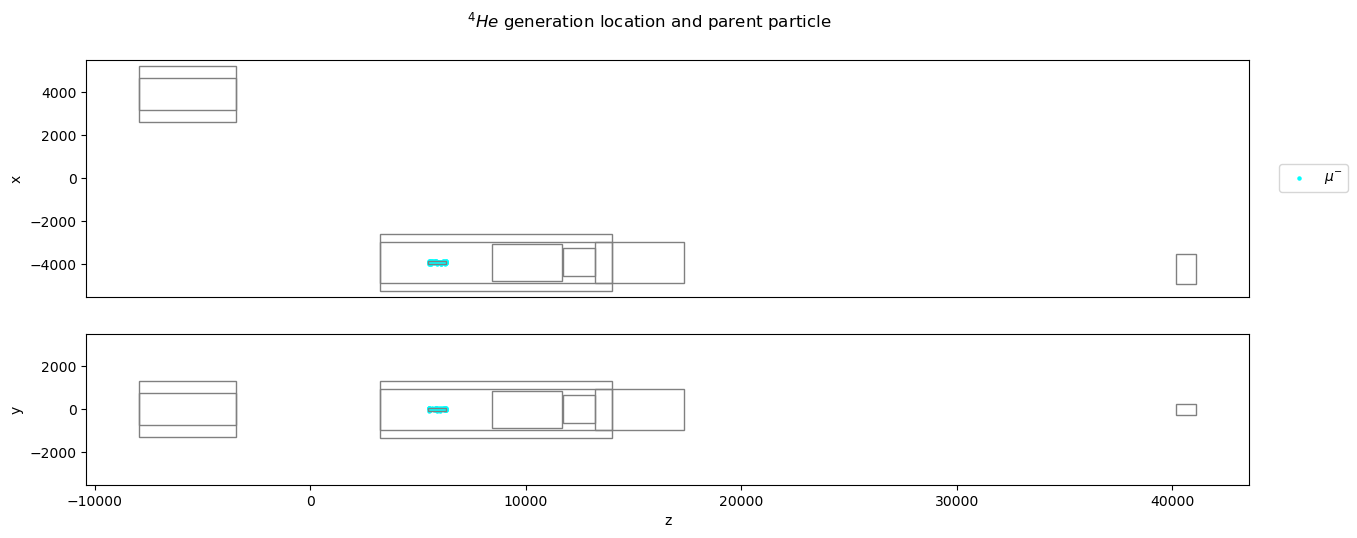

------------------------------------------------------------------------------
Parent pdgId:  13 $\mu^{-}$
count:  1
creationCode
115    1
Name: count, dtype: int64
******


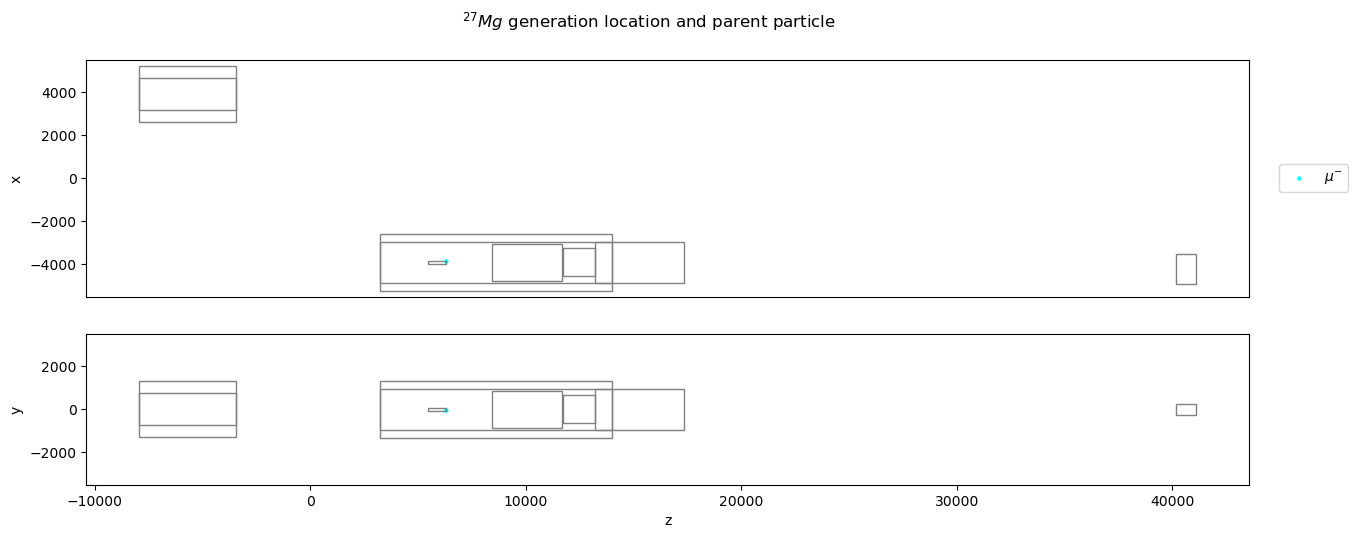

In [7]:
for pdgId in list_of_pdgId:
    fig, ax_top, ax_side = plot_utils.draw_particle_source_all(df_by_pdgid[pdgId][1], pdgid_dict[pdgId]+" generation location and parent particle")
    plt.show()

Text(0.5, 0.93, '$\\gamma$ spectrum at VD 10')

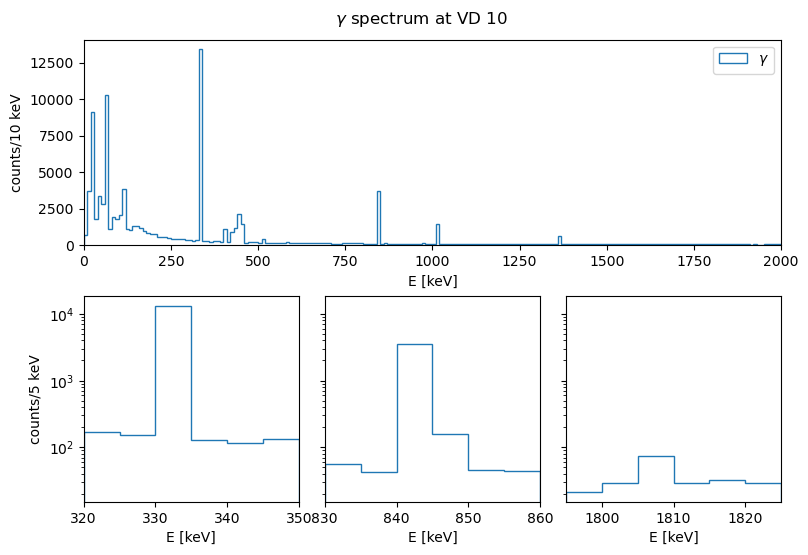

In [10]:
bins_main = np.linspace(0., 2000., 201) # 10keV
bins_347  = np.linspace(320., 350., 7) # 5keV
bins_844  = np.linspace(830., 860., 7)
bins_1809 = np.linspace(1795., 1825., 7)
mybins = [bins_main, bins_347, bins_844, bins_1809]

fig = plt.figure(figsize=(9, 6))
gs = GridSpec(2, 3, figure=fig,
              wspace=0.12, hspace=0.25) 

ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1], sharey=ax1)
ax3 = fig.add_subplot(gs[1, 2], sharey=ax1)
ax = [ax0, ax1, ax2, ax3]

for i in range(4):
    ax[i].hist(df_by_pdgid[22][0]['E'], bins=mybins[i], histtype="step", label=r'$\gamma$')
    ax[i].set_xlim(mybins[i][0],mybins[i][-1])
    ax[i].set_xlabel('E [keV]')

ax[0].set_ylabel('counts/10 keV')
ax[1].set_ylabel('counts/5 keV')
ax[1].set_yscale('log')
ax[2].tick_params(axis="y", labelleft=False)
ax[3].tick_params(axis="y", labelleft=False)

ax[0].legend()
fig.suptitle(r'$\gamma$'+" spectrum at VD 10", y=0.93)

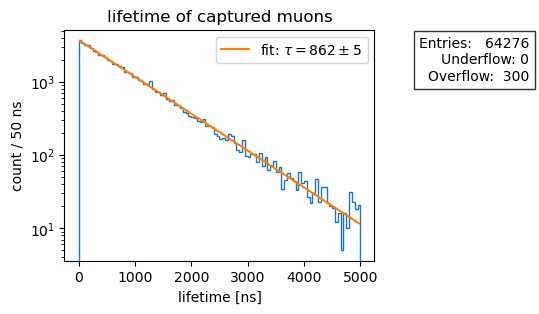

In [11]:
from scipy.optimize import curve_fit

def expo(x, A, tau):
    return A * np.exp(-x / tau)

mybins = np.linspace(0., 5000., 101)
fig, ax = plt.subplots(figsize=(4,3))
dfs_ = df_source.query("parentpdgId==13 and creationCode==115").reset_index(drop=True) # muon, nuclear capture
counts, bin_edges, _ = ax.hist(dfs_['starttime']-dfs_['parentendtime'], mybins, histtype='step')

bin_centers = bin_edges[1:]-0.5*(bin_edges[1]-bin_edges[0])
p0=(500., 800.)
popt, pcov = curve_fit(expo, bin_centers[:], counts[:], p0=p0)
A, tau = popt
Aerr, tauerr = np.sqrt(np.diag(pcov))
xfit = np.linspace(bin_centers[0], bin_centers.max(), 300)
ax.plot(xfit, expo(xfit, *popt), '-', label=fr'fit: $\tau={tau:.0f}\pm{tauerr:.0f}$')

ax.set_title('lifetime of captured muons')
ax.set_xlabel('lifetime [ns]')
ax.set_ylabel('count / 50 ns')
entries = len(dfs_['starttime'])
mean = np.mean(dfs_['starttime'])
std = np.std(dfs_['starttime'])
underflow = (dfs_['starttime'] < 0.).sum()
overflow  = (dfs_['starttime'] > 5000.).sum()
textstr = (
    f"Entries:   {entries}\n"
    #f"Mean:      {mean:.3f}\n"
    #f"Std Dev:   {std:.3f}\n"
    f"Underflow: {underflow}\n"
    f"Overflow:  {overflow}"
)
ax.text(
    1.5, 0.97, textstr,
    transform=ax.transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
)
ax.set_yscale('log')
ax.legend()

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3695.460219
creationCode                   17
index                        3351
pdgId                          11
px                    1966.136755
py                   -2143.457036
pz                    2995.509425
startpx                566.316783
startpy              -5750.827789
startpz                139.659986
starttime             1010.536438
startx               -4030.051225
starty                  38.907412
startz                3928.043524
time                   1023.20754
virtualdetectorId              10
x                    -4053.760037
y                       40.442883
z                     6275.999996
weight                          1
r                      155.124774
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3931.677769,34.047301,5515.441729,-14.900893,995.104858,-4226.481672,81.622447,14493.501874,-0.000000,1070.848755,114
1,13,-3940.897878,32.554420,4179.000000,18.023277,341.486420,-3931.677769,34.047301,5515.441729,0.000000,367.899628,56
2,13,3925.006572,3.946431,-6021.563623,3.826953,12.515982,-3933.183167,22.179872,4194.152627,18.036366,341.790009,14
3,-211,3837.594624,6.074052,-6066.811449,16.421967,11.164665,3925.006572,3.946431,-6021.563623,17.288906,12.515982,14
4,3122,3927.191203,-0.155147,-6065.358541,-10.488399,10.568395,3837.594624,6.074052,-6066.811449,-10.488399,11.164665,101
5,2212,3929.175632,-0.151693,-6057.409491,-8624.851562,10.540914,3927.191203,-0.155147,-6065.358541,-8602.687500,10.568395,56


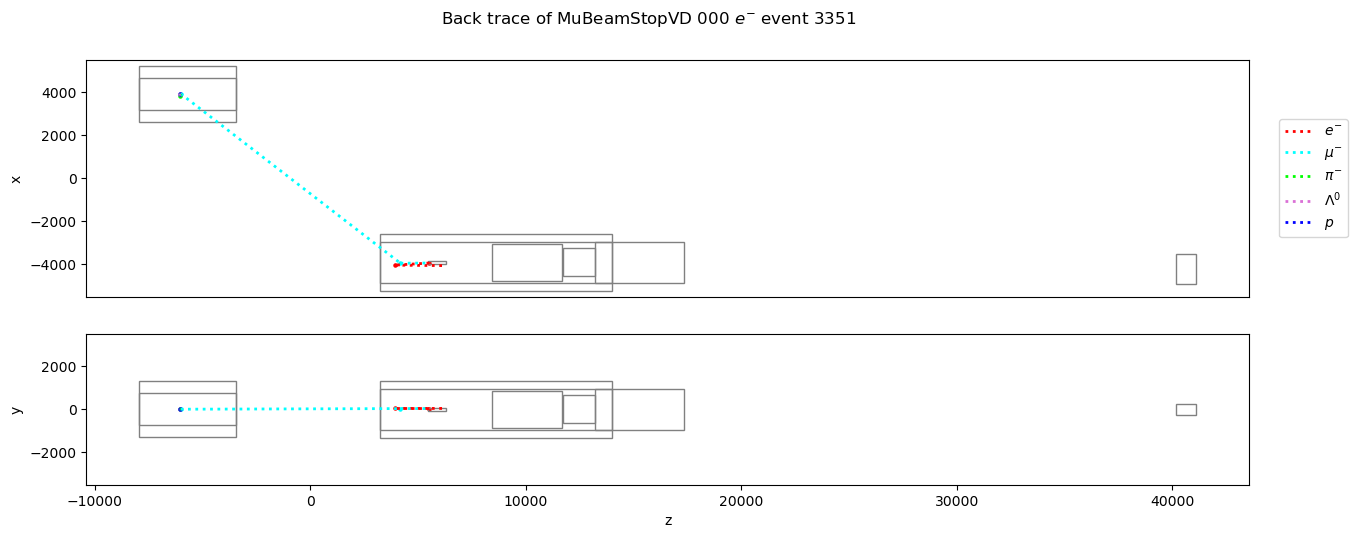

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3555.795239
creationCode                   17
index                        3904
pdgId                          11
px                    -547.816048
py                    1985.220822
pz                    3469.364585
startpx              -2593.172312
startpy              -1174.943686
startpz              -4431.688309
starttime             1348.276489
startx                -850.982029
starty                 -42.842215
startz                 -40.754465
time                  1382.970377
virtualdetectorId              10
x                    -3962.615967
y                      -69.171034
z                     6275.999996
weight                          1
r                       90.666772
Name: 1, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3934.557977,53.114839,5826.603105,-18.991661,1308.360229,-4191.814338,-197.026775,15587.456843,0.000000,1411.164062,114
1,13,-3912.805928,18.437794,4179.000000,33.930233,181.801331,-3934.557977,53.114839,5826.603105,0.000000,200.764709,56
2,13,3883.987932,5.021917,-4164.792119,37.018799,37.171017,-3912.129885,26.550096,4197.254201,33.921368,182.002350,14
3,-211,3889.577064,1.541473,-6228.219539,-3.073851,-4.823252,3883.987932,5.021917,-4164.792119,34.477093,37.171017,101
4,2212,3930.404879,0.553485,-6057.715977,-8624.851562,-5.411436,3889.577064,1.541473,-6228.219539,-8383.269531,-4.823252,56


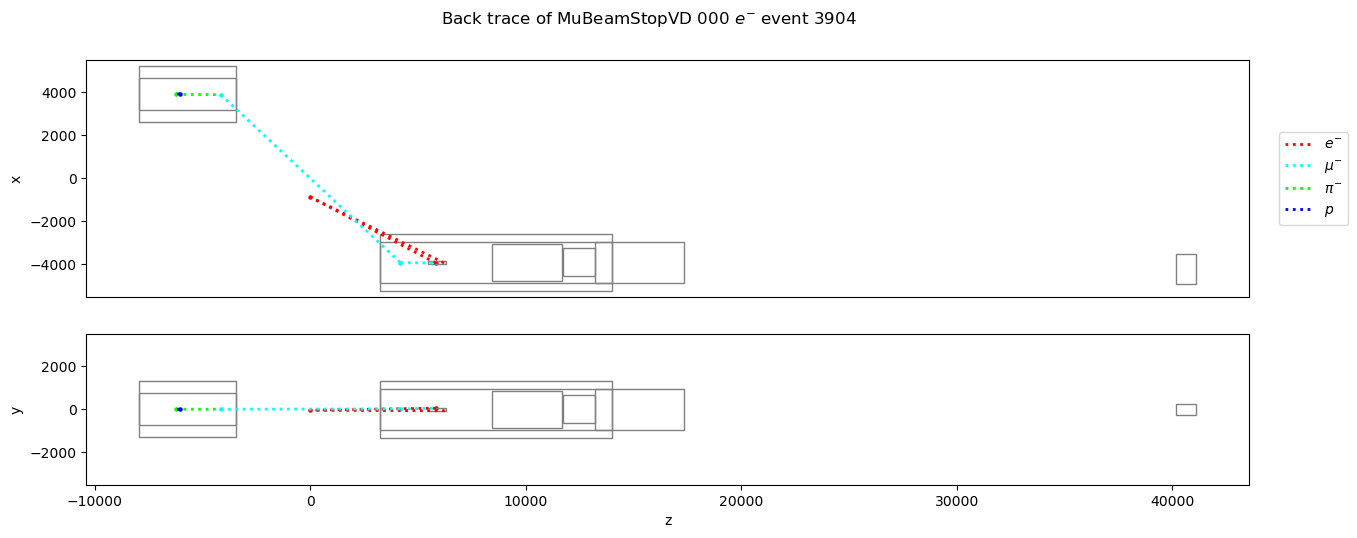

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     4186.061956
creationCode                   17
index                        4085
pdgId                          11
px                   -1538.560578
py                   -2410.645055
pz                    3690.918946
startpx                310.772508
startpy               2847.345352
startpz              -5643.611431
starttime              864.247253
startx                -851.482337
starty                 -32.819554
startz                   74.26302
time                   904.105929
virtualdetectorId              10
x                    -3830.641617
y                      -56.433084
z                     6275.999996
weight                          1
r                       92.553472
Name: 2, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3881.207539,30.172838,5959.873243,-17.162416,815.971802,-3718.505117,-306.102785,15425.751605,-0.000000,924.183655,114
1,13,-3813.652737,3.920377,4179.000000,21.027153,403.529968,-3881.207539,30.172838,5959.873243,0.000000,433.686249,56
2,13,3978.199806,0.303417,-4064.673852,-2.042584,76.515427,-3813.070477,20.221566,4190.479740,21.067181,403.733459,14
3,-211,3879.308537,-2.298364,-6257.935127,57.385963,7.462329,3978.199806,0.303417,-4064.673852,29.405907,76.515427,100
4,-211,3885.286662,1.150236,-6234.409113,-1257.037842,7.380041,3879.308537,-2.298364,-6257.935127,-1214.351440,7.462329,101
5,2212,3931.496910,-0.856287,-6057.988250,-8624.851562,6.768161,3885.286662,1.150236,-6234.409113,-8264.657227,7.380041,56


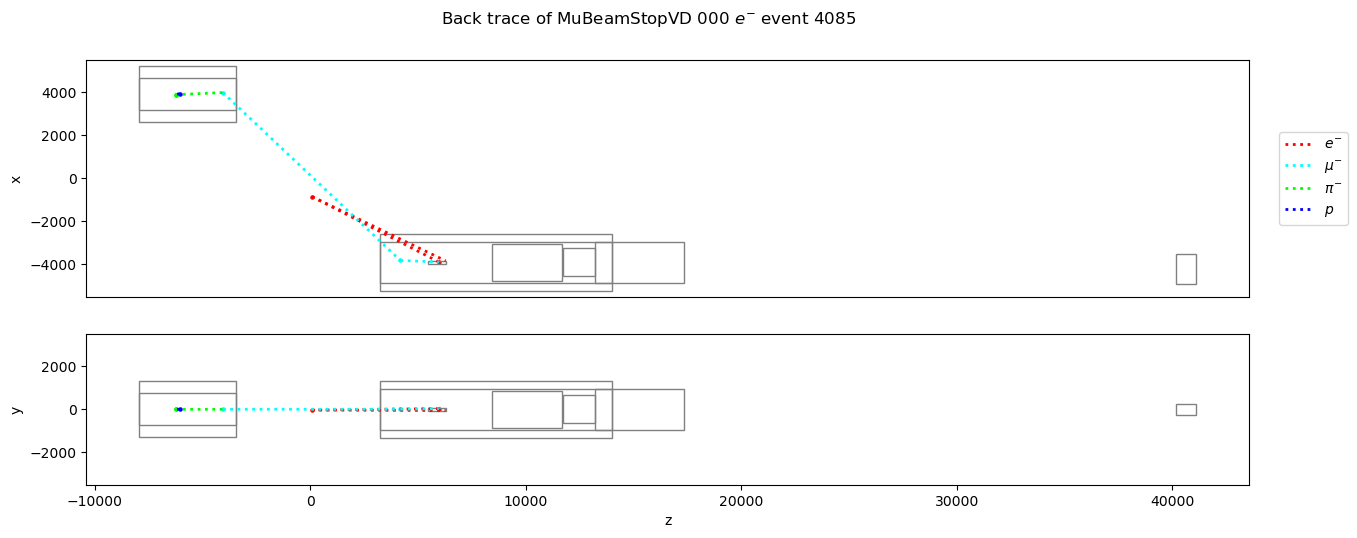

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1790.328141
creationCode                   17
index                        8797
pdgId                          11
px                    -743.134851
py                       -787.741
pz                    1965.248335
startpx               2537.903547
startpy               -824.426353
startpz               1347.042799
starttime             2321.963867
startx               -3944.242274
starty                -132.324612
startz                3926.501015
time                  2331.378575
virtualdetectorId              10
x                     -3953.76362
y                     -154.166226
z                     6275.999996
weight                          1
r                      161.998899
Name: 3, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3923.425820,31.978827,5493.255353,-22.904438,2302.089355,-3957.375788,-116.340128,3843.317265,0.675593,2324.689941,114
1,13,-3878.931493,58.315127,4179.000000,16.296890,271.608185,-3923.425820,31.978827,5493.255353,0.000000,299.861145,56
2,13,3878.398241,7.165918,-5399.493926,20.240683,-17.728350,-3887.363056,68.397669,4193.943519,16.315245,271.938019,14
3,-211,3917.726054,-1.080773,-6108.414259,62.062656,-24.144356,3878.398241,7.165918,-5399.493926,56.748150,-17.728350,101
4,2212,3930.406759,-1.156967,-6057.716445,-8624.851562,-24.319653,3917.726054,-1.080773,-6108.414259,-8542.137695,-24.144356,56


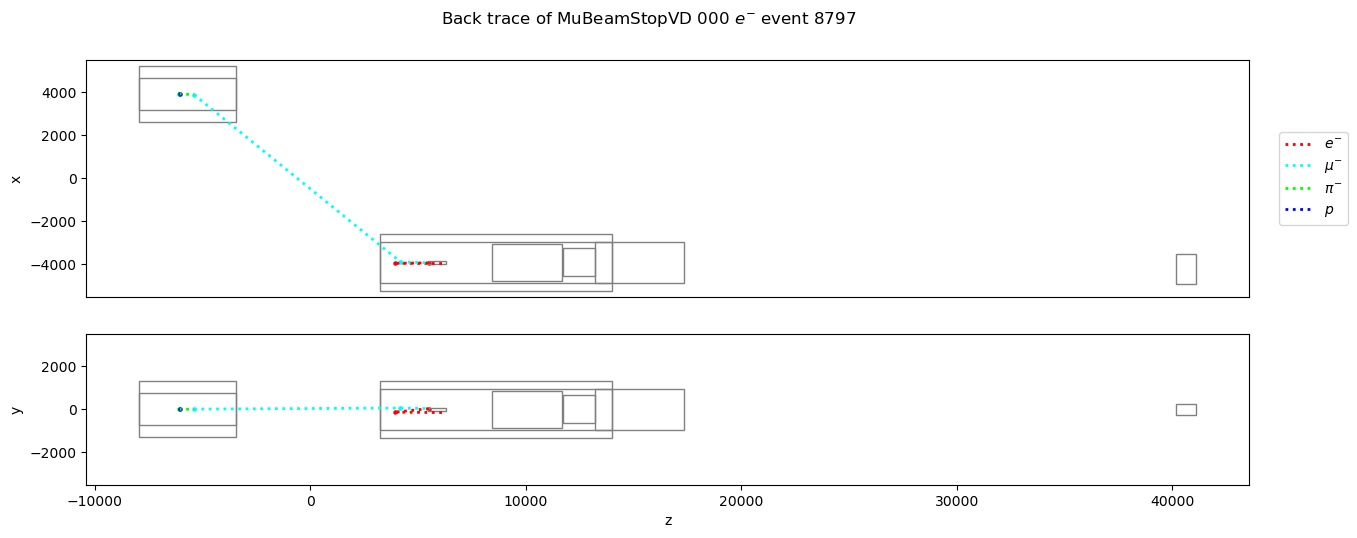

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3029.589109
creationCode                   17
index                       10463
pdgId                          11
px                   -2137.146776
py                   -1444.559715
pz                    2370.758217
startpx               4119.105339
startpy                 835.34658
startpz               1603.151679
starttime              315.978271
startx               -3934.679414
starty                -140.518186
startz                3927.508569
time                   329.476112
virtualdetectorId              10
x                    -3943.189689
y                     -154.257104
z                     6275.999996
weight                          1
r                      159.157424
Name: 4, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3875.989069,-14.215852,5937.704658,-22.459005,290.739655,-3938.922136,-123.599091,3850.532982,-0.000000,316.914795,114
1,13,-3947.534286,11.374380,4179.000000,31.267000,223.024551,-3875.989069,-14.215852,5937.704658,-0.000000,244.491898,56
2,13,3864.796378,-58.392354,-6152.607410,-5.557775,-8.253784,-3949.625690,-1.970295,4193.712305,31.298531,223.203217,14
3,-211,3913.415142,1.703955,-6121.113366,-38.309986,-10.641916,3864.796378,-58.392354,-6152.607410,-5.031478,-8.253784,101
4,2212,3929.870555,1.644192,-6057.582755,-8624.851562,-10.862056,3913.415142,1.703955,-6121.113366,-8501.585938,-10.641916,56


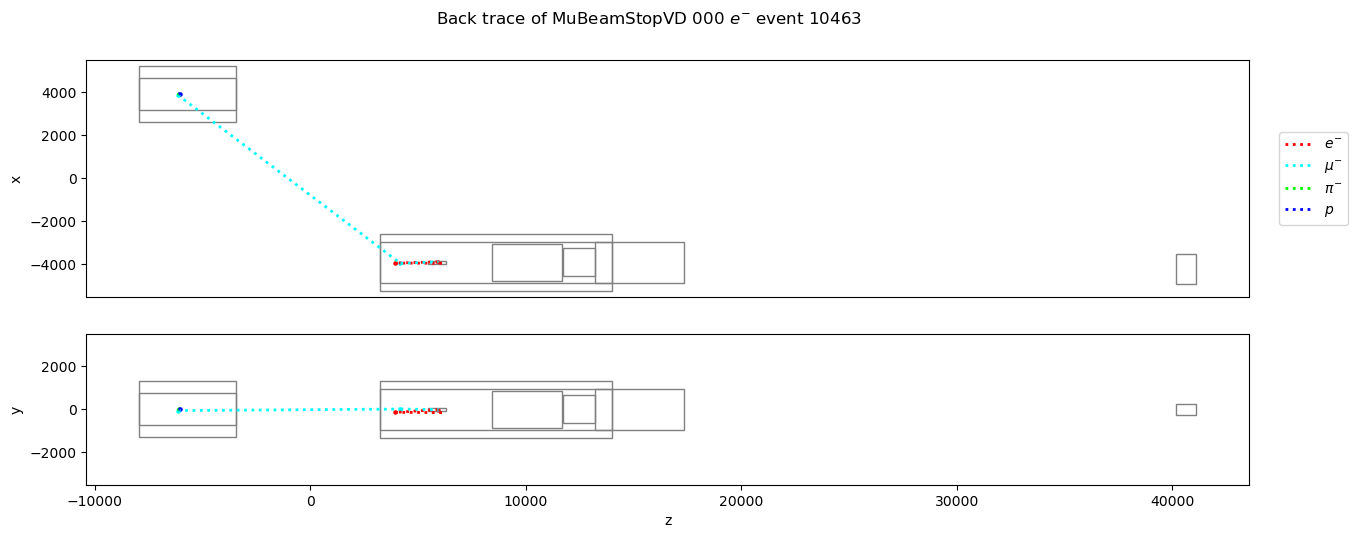

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     3573.116851
creationCode                   17
index                       11348
pdgId                          11
px                    -972.669993
py                    -1965.08077
pz                     3407.52877
startpx              -3100.668669
startpy              -4167.282104
startpz                 1775.4215
starttime              1478.46167
startx                -851.499483
starty                 -88.335973
startz                  27.927568
time                  1513.668938
virtualdetectorId              10
x                    -3884.980756
y                     -117.169496
z                     6275.999996
weight                          1
r                      118.703085
Name: 5, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3921.397167,35.411660,5493.243770,-20.144234,1434.074463,-848.652496,-215.295901,53.596021,0.000000,1607.223389,114
1,13,-3895.954813,46.561372,4179.000000,18.733992,240.389526,-3921.397167,35.411660,5493.243770,0.000000,265.542542,56
2,13,3920.461306,40.755636,-5602.224455,23.824596,-13.368723,-3891.612501,53.967614,4197.012275,18.723923,240.735016,14
3,-211,3898.232182,0.588656,-6185.887378,128.263077,-17.979500,3920.461306,40.755636,-5602.224455,67.557472,-13.368723,101
4,2212,3930.441818,0.766001,-6057.725186,-8624.851562,-18.422798,3898.232182,0.588656,-6185.887378,-8441.970703,-17.979500,56


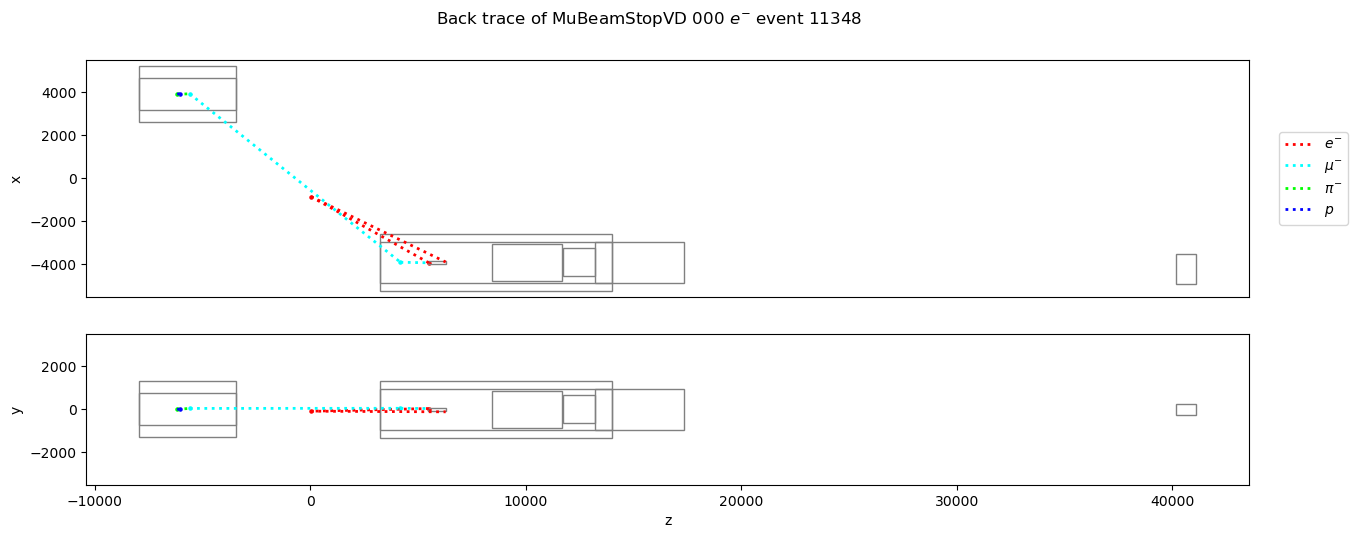

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1125.695237
creationCode                   17
index                       13829
pdgId                          11
px                     521.008085
py                     627.100444
pz                   -1323.987709
startpx              -3250.391483
startpy                510.939658
startpz                -84.701017
starttime              276.508148
startx               -3967.910231
starty                 316.647837
startz               13806.334364
time                   306.423175
virtualdetectorId              10
x                    -3945.013484
y                       232.49744
z                     6276.019996
weight                          1
r                      236.087199
Name: 6, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3904.353573,37.343003,6204.289456,5.937409,223.340683,-3998.977024,313.869832,13837.828473,0.000000,276.698334,114
1,13,-3849.049643,25.608202,4179.000000,37.646347,103.461746,-3904.353573,37.343003,6204.289456,0.000000,126.412270,56
2,13,3914.860648,8.166914,-3985.833216,36.840420,-32.912373,-3842.974991,32.188078,4196.869519,37.648930,103.641846,14
3,-211,3897.009980,0.653942,-6191.109783,77.881241,-60.163418,3914.860648,8.166914,-3985.833216,47.381943,-32.912373,101
4,2212,3930.892722,0.443414,-6057.837609,-8624.851562,-60.624729,3897.009980,0.653942,-6191.109783,-8372.567383,-60.163418,56


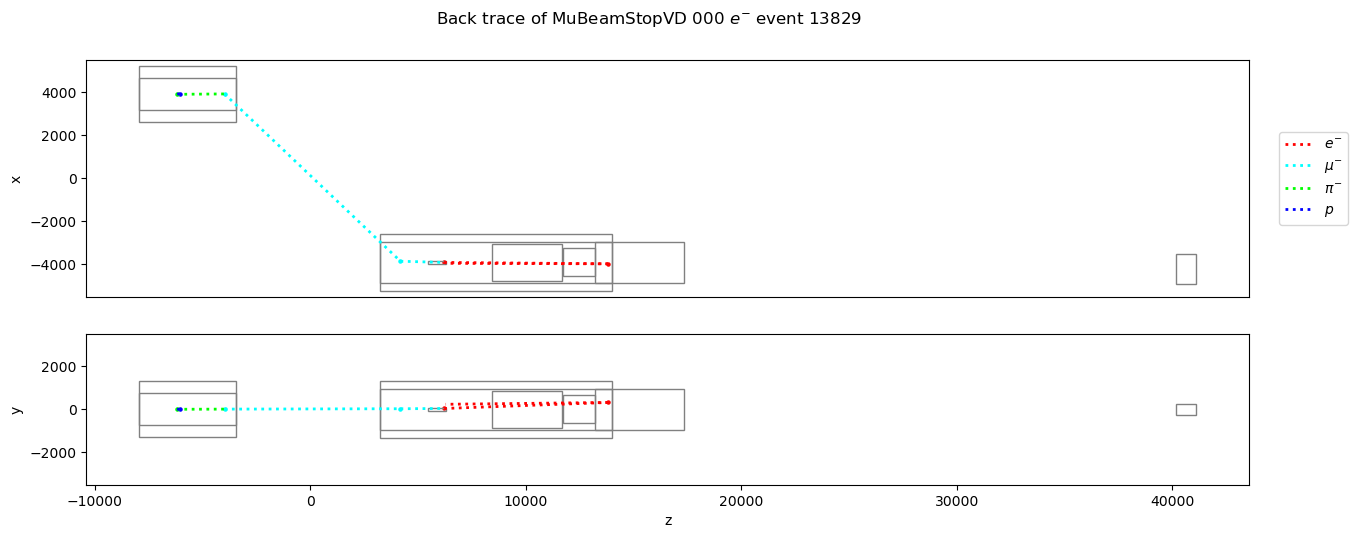

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     6029.997945
creationCode                   17
index                       27968
pdgId                          11
px                   -3259.430204
py                   -2433.751555
pz                    5096.713459
startpx               4205.618382
startpy               8613.617897
startpz              -9795.441628
starttime             1773.035034
startx                -851.843758
starty                 -78.856631
startz                   9.361335
time                  1813.441931
virtualdetectorId              10
x                    -3919.804803
y                     -118.654668
z                     6275.999996
weight                          1
r                       119.70264
Name: 7, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3932.980762,35.811400,5782.141960,-22.580769,1724.097778,-846.841032,-75.338829,2.553557,-0.000000,1773.076050,114
1,13,-3929.757513,83.980762,4179.000000,25.698631,155.056992,-3932.980762,35.811400,5782.141960,0.000000,178.665024,56
2,13,3926.440460,23.336040,-5438.511409,26.842840,-48.370689,-3939.000059,74.785666,4194.113893,25.740395,155.274567,14
3,-211,3921.725401,1.037183,-6092.613616,79.273842,-54.040428,3926.440460,23.336040,-5438.511409,59.277359,-48.370689,101
4,2212,3930.444888,0.998187,-6057.725952,-8624.851562,-54.161053,3921.725401,1.037183,-6092.613616,-8562.353516,-54.040428,56


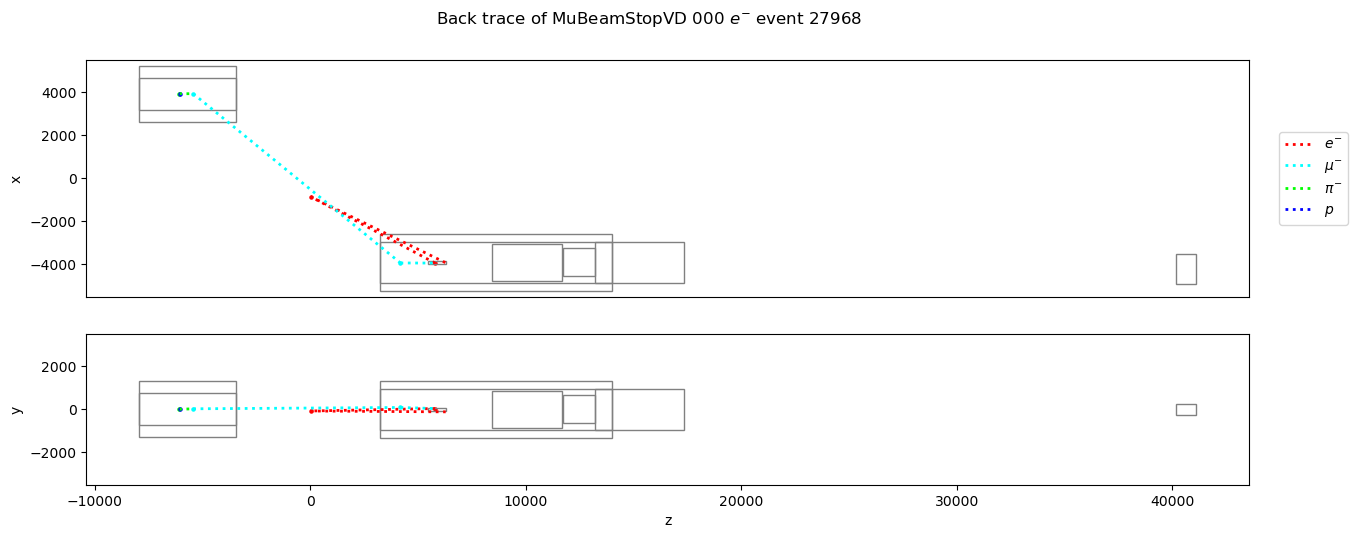

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     5098.779596
creationCode                   12
index                       30193
pdgId                          11
px                   -2509.183524
py                     105.419742
pz                    4990.128227
startpx                -4226.2187
startpy               1812.467933
startpz               6351.887703
starttime            34823.304688
startx               -4050.980045
starty                 240.658079
startz                4220.832671
time                 34831.138463
virtualdetectorId              10
x                    -4075.975584
y                      283.982013
z                     6275.999996
weight                          1
r                      331.996062
Name: 8, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,22,-4018.641549,225.440033,4172.845139,6.120203,34823.105469,-3989.859007,-219.824439,4070.514435,-0.028308,34825.660156,35
1,2112,-3865.828498,-1.819651,5937.620475,-42.275562,386.403168,-4018.641549,225.440033,4172.845139,0.006256,34823.105469,115
2,13,-3894.832042,7.992622,4179.000000,31.226654,213.154892,-3865.828498,-1.819651,5937.620475,0.000000,235.695999,56
3,13,3913.758945,-42.871517,-3280.875732,31.084906,58.960529,-3899.761475,-1.150237,4196.065603,31.232109,213.358719,14
4,-211,3919.523437,-0.550365,-6095.118563,91.308235,33.026722,3913.758945,-42.871517,-3280.875732,58.959675,58.960529,101
5,2212,3928.972537,-0.689926,-6057.358853,-8624.851562,32.896160,3919.523437,-0.550365,-6095.118563,-8576.691406,33.026722,56


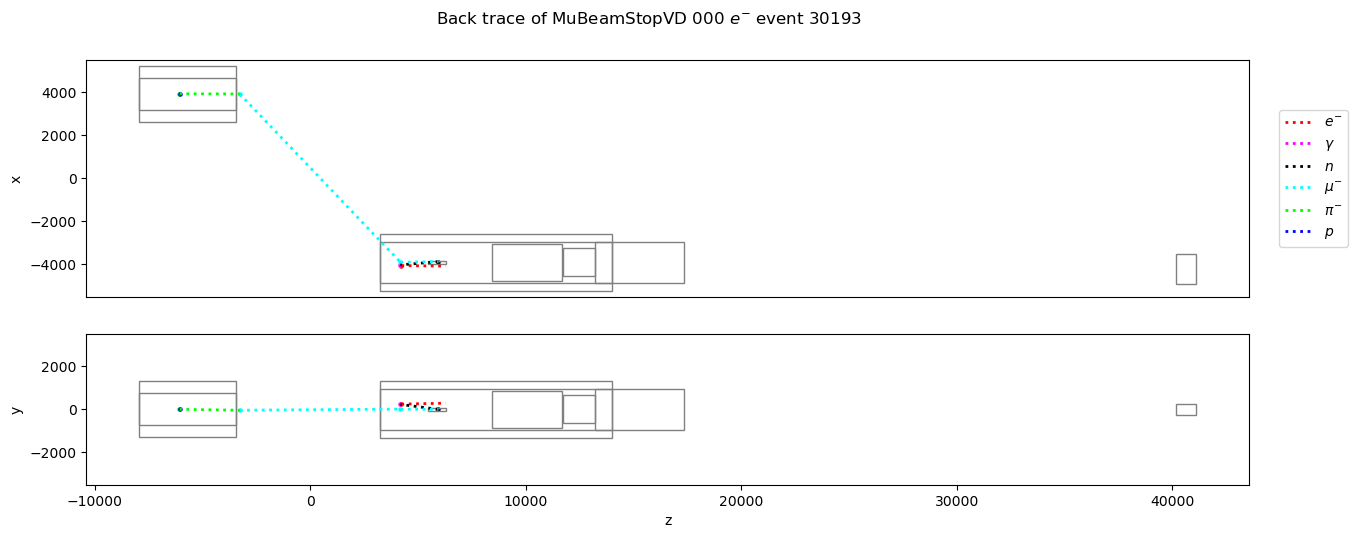

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1023.627644
creationCode                   17
index                       30543
pdgId                          11
px                    -604.967627
py                    -209.545922
pz                   -1297.714703
startpx                 58.906611
startpy               2032.671452
startpz               1512.606621
starttime             4060.416992
startx               -3582.259845
starty                   3.586933
startz               14276.607899
time                  4090.899955
virtualdetectorId              10
x                    -3711.646192
y                        6.372514
z                     6276.019996
weight                          1
r                      192.459337
Name: 9, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3855.822135,-9.653219,6248.830221,29.901281,4024.959717,-3529.815631,30.816219,14450.739981,0.000000,4061.097168,114
1,13,-3867.232112,-32.420394,4179.000000,37.462788,136.482224,-3855.822135,-9.653219,6248.830221,0.000000,160.387650,56
2,13,3939.587107,13.998888,-5621.778822,26.666134,-27.159100,-3859.008847,-23.382058,4194.810302,37.476933,136.645218,14
3,-211,3892.092534,0.341821,-6211.039476,16.537781,-35.285328,3939.587107,13.998888,-5621.778822,37.683407,-27.159100,101
4,2212,3931.161651,0.494574,-6057.904661,-8624.851562,-35.815502,3892.092534,0.341821,-6211.039476,-8382.287109,-35.285328,56


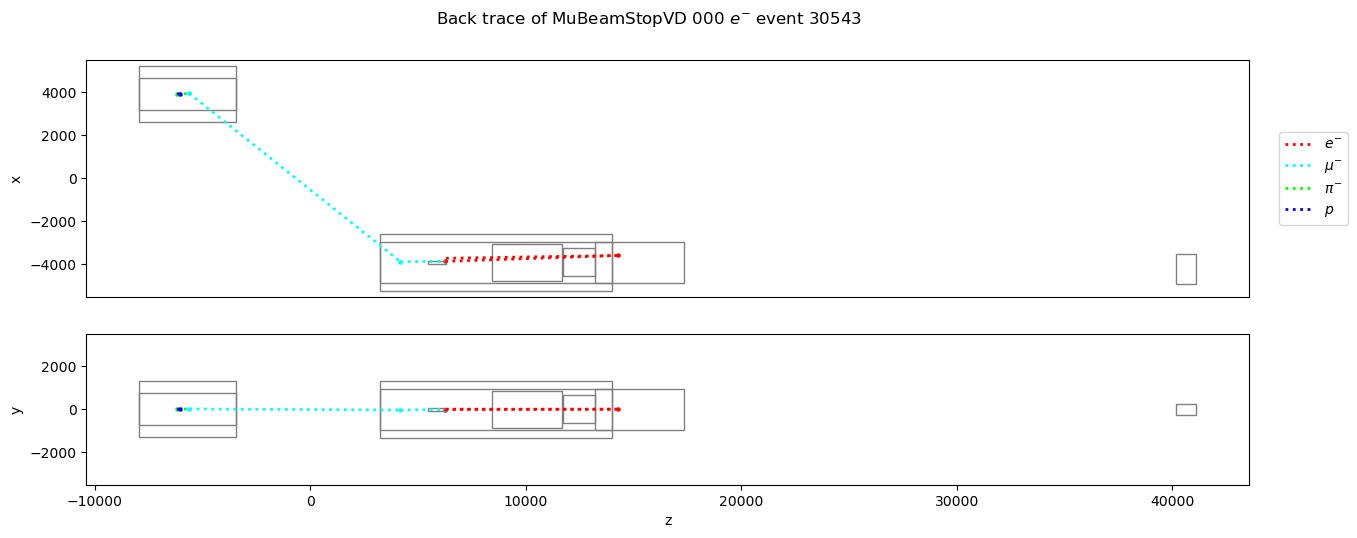

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                          2960.0
creationCode                   35
index                           8
pdgId                          22
px                    -785.922784
py                    -286.663583
pz                   -2839.321991
startpx               -785.922766
startpy               -286.663592
startpz               -2839.32209
starttime            23147.666016
startx                -3209.30735
starty                  99.983816
startz                9411.729975
time                 23158.570572
virtualdetectorId              10
x                    -4077.270169
y                     -216.603686
z                     6276.019996
weight                          1
r                       277.38008
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-2965.825825,225.426582,5347.656223,24.058247,662.691833,-3209.307350,99.983816,9411.729975,0.205249,23147.666016,97
1,2112,-4377.892030,-763.964592,6294.033086,-12.666872,422.511475,-2965.825825,225.426582,5347.656223,24.730726,662.691833,97
2,2112,-3847.330944,19.402347,5582.089357,53.694889,382.478699,-4377.892030,-763.964592,6294.033086,58.495956,422.511475,115
3,13,-3833.539737,35.830803,4179.000000,25.293018,206.845627,-3847.330944,19.402347,5582.089357,0.000000,227.639328,56
4,13,-3240.009712,40.055680,1203.857460,23.612434,160.578690,-3840.329177,43.376763,4196.194986,25.314312,207.094238,14
5,-211,3906.089903,0.575889,-6162.255140,21.343912,6.680685,-3240.009712,40.055680,1203.857460,23.750673,160.578690,101
6,2212,3931.295891,0.372371,-6057.938131,-8624.851562,6.320682,3906.089903,0.575889,-6162.255140,-8499.072266,6.680685,56


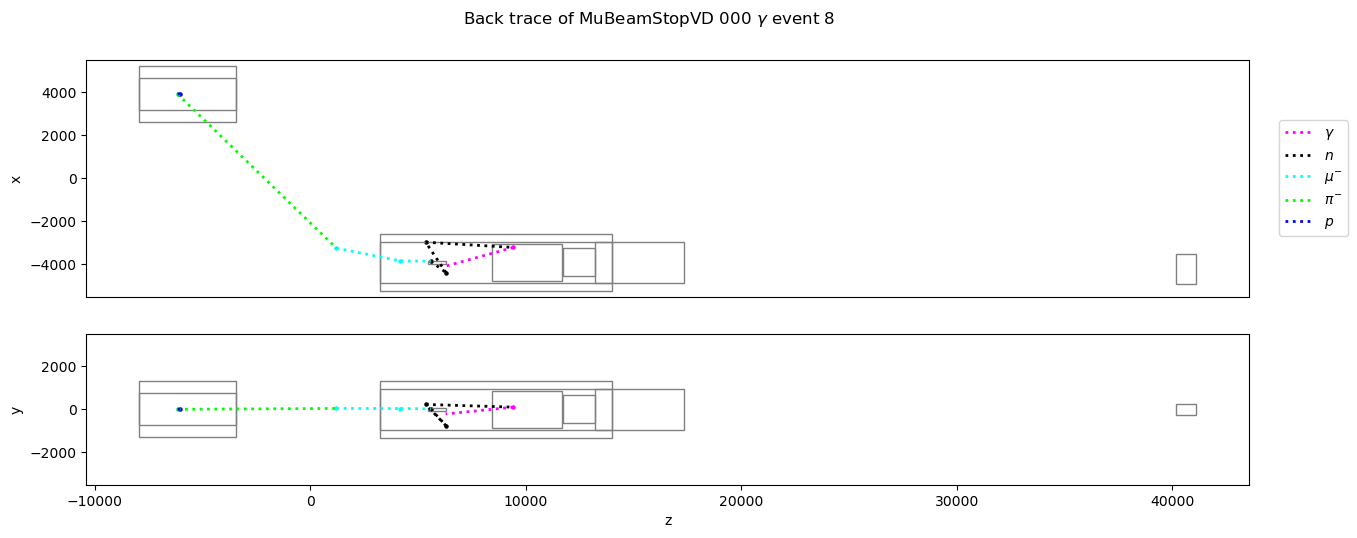

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                        90.570729
creationCode                    16
index                           14
pdgId                           22
px                       44.208777
py                      -38.076518
pz                       69.273514
startpx                  34.823149
startpy                   9.480808
startpz                -228.043258
starttime              518102.0625
startx                -3826.523702
starty                  947.234517
startz                 5266.575048
time                 518107.933946
virtualdetectorId               10
x                     -3512.644883
y                       -11.357769
z                      6275.999996
weight                           1
r                       391.519893
Name: 1, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3826.522732,947.189959,5267.280993,-4.993951,518102.062500,-3827.576388,947.547660,5265.602916,-0.000000,518102.062500,13
1,22,-3787.519516,959.748677,5365.435754,-7.055440,518101.718750,-3826.522732,947.189959,5267.280993,-7.055440,518102.062500,35
2,2112,-3876.600504,36.290637,6026.582432,4.400261,1086.659546,-3787.519516,959.748677,5365.435754,-0.006847,518101.718750,115
3,13,-3957.195149,0.511161,4179.000000,35.630756,226.540298,-3876.600504,36.290637,6026.582432,0.000000,247.924210,56
4,13,3866.303099,-15.110252,-5360.611171,20.904200,55.463570,-3950.870251,-9.731639,4194.946475,35.657627,226.711502,14
5,-211,3931.934676,-0.915471,-6058.427028,45.795208,47.623795,3866.303099,-15.110252,-5360.611171,51.472637,55.463570,101
6,2212,3932.012053,-0.915422,-6058.116690,-8624.851562,47.622723,3931.934676,-0.915471,-6058.427028,-8624.124023,47.623795,56


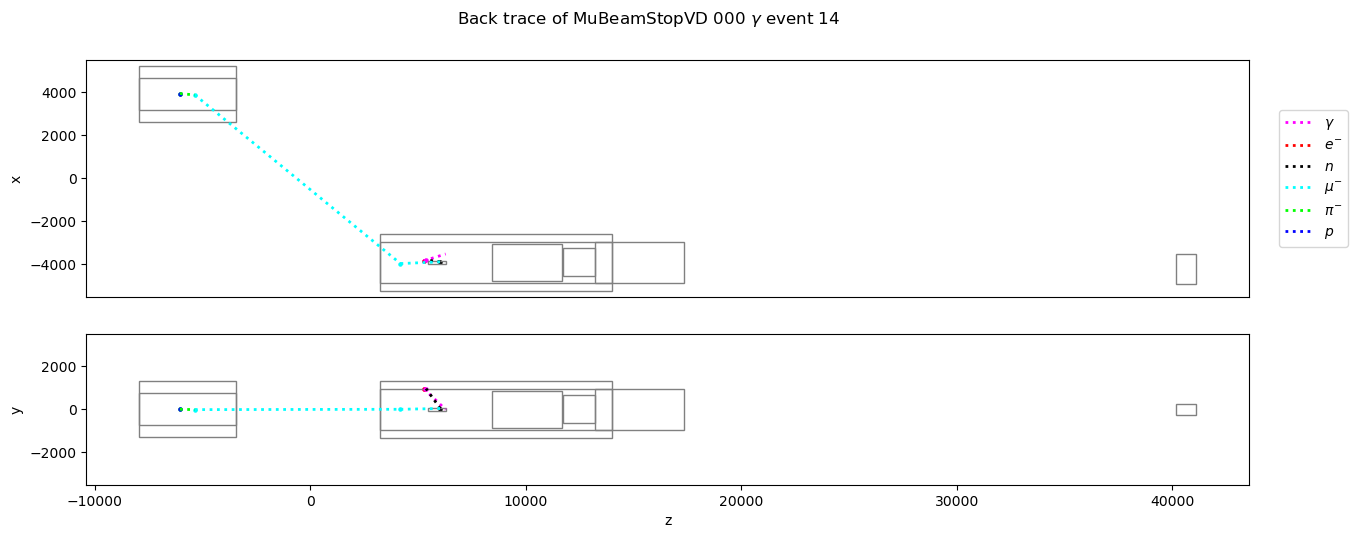

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                        68.035834
creationCode                    16
index                           15
pdgId                           22
px                       -4.593869
py                       21.590956
pz                      -64.355278
startpx                  34.823149
startpy                   9.480808
startpz                -228.043258
starttime              518102.0625
startx                -3826.523702
starty                  947.234517
startz                 5266.575048
time                 518110.398279
virtualdetectorId               10
x                     -3335.693879
y                       -79.111819
z                      6276.019996
weight                           1
r                       573.786134
Name: 2, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3826.522732,947.189959,5267.280993,-4.993951,518102.062500,-3827.576388,947.547660,5265.602916,-0.000000,518102.062500,13
1,22,-3787.519516,959.748677,5365.435754,-7.055440,518101.718750,-3826.522732,947.189959,5267.280993,-7.055440,518102.062500,35
2,2112,-3876.600504,36.290637,6026.582432,4.400261,1086.659546,-3787.519516,959.748677,5365.435754,-0.006847,518101.718750,115
3,13,-3957.195149,0.511161,4179.000000,35.630756,226.540298,-3876.600504,36.290637,6026.582432,0.000000,247.924210,56
4,13,3866.303099,-15.110252,-5360.611171,20.904200,55.463570,-3950.870251,-9.731639,4194.946475,35.657627,226.711502,14
5,-211,3931.934676,-0.915471,-6058.427028,45.795208,47.623795,3866.303099,-15.110252,-5360.611171,51.472637,55.463570,101
6,2212,3932.012053,-0.915422,-6058.116690,-8624.851562,47.622723,3931.934676,-0.915471,-6058.427028,-8624.124023,47.623795,56


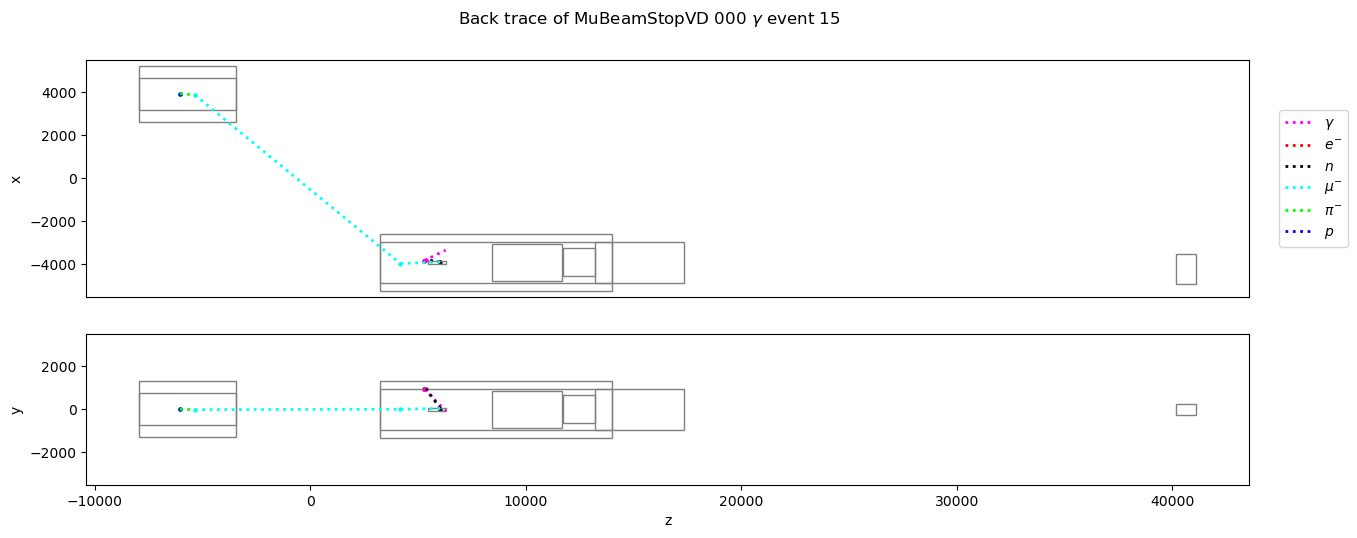

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                        55.433032
creationCode                    16
index                           16
pdgId                           22
px                      -21.396852
py                       16.310739
pz                       48.466025
startpx                  34.823149
startpy                   9.480808
startpz                -228.043258
starttime              518102.0625
startx                -3826.523702
starty                  947.234517
startz                 5266.575048
time                 518115.383961
virtualdetectorId               10
x                     -3683.979047
y                       377.271243
z                      6275.999996
weight                           1
r                       436.741125
Name: 3, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,11,-3826.522732,947.189959,5267.280993,-4.993951,518102.062500,-3827.576388,947.547660,5265.602916,-0.000000,518102.062500,13
1,22,-3787.519516,959.748677,5365.435754,-7.055440,518101.718750,-3826.522732,947.189959,5267.280993,-7.055440,518102.062500,35
2,2112,-3876.600504,36.290637,6026.582432,4.400261,1086.659546,-3787.519516,959.748677,5365.435754,-0.006847,518101.718750,115
3,13,-3957.195149,0.511161,4179.000000,35.630756,226.540298,-3876.600504,36.290637,6026.582432,0.000000,247.924210,56
4,13,3866.303099,-15.110252,-5360.611171,20.904200,55.463570,-3950.870251,-9.731639,4194.946475,35.657627,226.711502,14
5,-211,3931.934676,-0.915471,-6058.427028,45.795208,47.623795,3866.303099,-15.110252,-5360.611171,51.472637,55.463570,101
6,2212,3932.012053,-0.915422,-6058.116690,-8624.851562,47.622723,3931.934676,-0.915471,-6058.427028,-8624.124023,47.623795,56


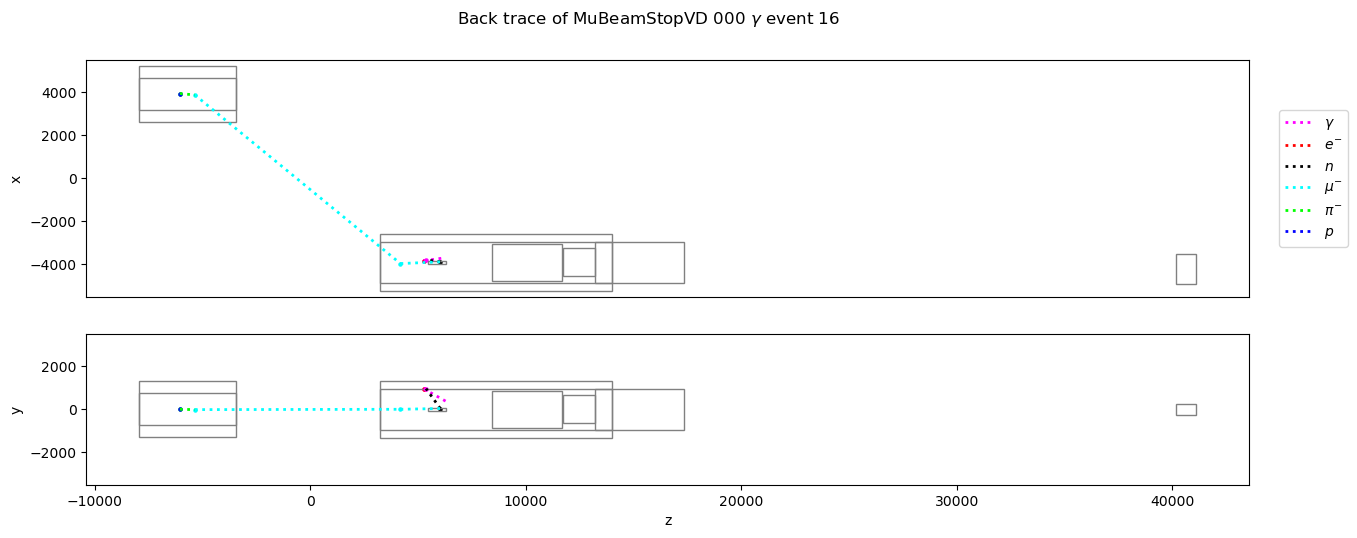

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                        71.852287
creationCode                    35
index                           73
pdgId                           22
px                        41.59357
py                       53.452004
pz                      -23.991859
startpx                  -8.088803
startpy                  -0.136434
startpz                 -79.630986
starttime               514155.875
startx                -3684.034687
starty                 -572.937963
startz                 6505.307812
time                 514157.514745
virtualdetectorId               10
x                     -3469.030257
y                        -283.8244
z                      6276.019996
weight                           1
r                       519.379406
Name: 4, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3932.750646,-2.058007,6159.844785,3.435921,599.598572,-3684.034687,-572.937963,6505.307812,-0.000179,514155.875000,115
1,13,-3882.250877,12.285383,4179.000000,40.983673,106.688377,-3932.750646,-2.058007,6159.844785,0.000000,128.057205,56
2,13,3907.236548,-0.749208,-5490.174194,43.326252,-27.984867,-3880.142695,17.836002,4198.092931,40.982929,106.865608,14
3,-211,3905.592869,-0.319669,-6151.300755,55.335648,-37.636581,3907.236548,-0.749208,-5490.174194,32.846199,-27.984867,101
4,2212,3929.312051,-0.637640,-6057.443504,-8624.851562,-37.961327,3905.592869,-0.319669,-6151.300755,-8472.873047,-37.636581,56


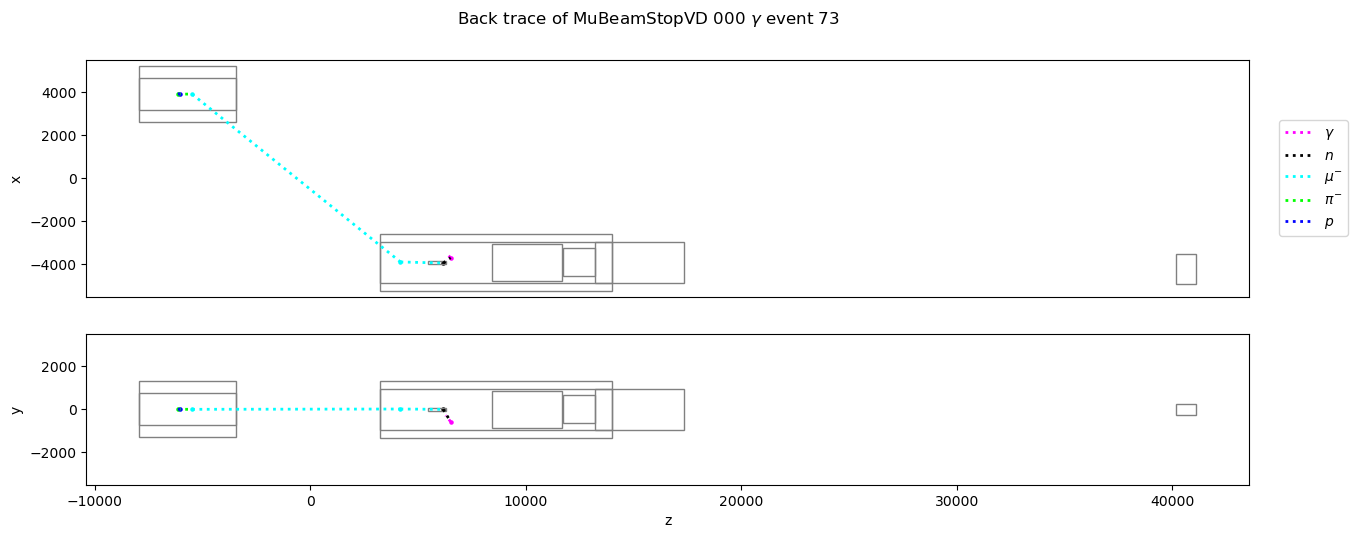

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      109.372165
creationCode                   97
index                         174
pdgId                          22
px                      35.422144
py                      84.022191
pz                      60.397133
startpx               -794.745207
startpy                211.547241
startpz                -199.71928
starttime              609.284729
startx                -3204.82491
starty                 645.317705
startz                4463.246521
time                    617.41736
virtualdetectorId              10
x                    -3798.555449
y                     -517.846403
z                     6275.999996
weight                          1
r                      528.472753
Name: 5, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3909.508475,-43.161802,5915.405655,-63.138004,517.401855,-3204.824910,645.317705,4463.246521,-45.911503,609.284729,115
1,13,-3922.119835,-58.882471,4179.000000,32.593414,154.282410,-3909.508475,-43.161802,5915.405655,0.000000,175.263504,56
2,13,3904.412216,-16.415404,-4037.639380,35.481766,4.750370,-3915.501938,-67.086106,4195.973279,32.618011,154.477615,14
3,-211,3923.209520,0.415856,-6088.707407,102.622971,-8.948345,3904.412216,-16.415404,-4037.639380,85.936234,4.750370,101
4,2212,3930.869571,0.398058,-6057.831837,-8624.851562,-9.055050,3923.209520,0.415856,-6088.707407,-8582.955078,-8.948345,56


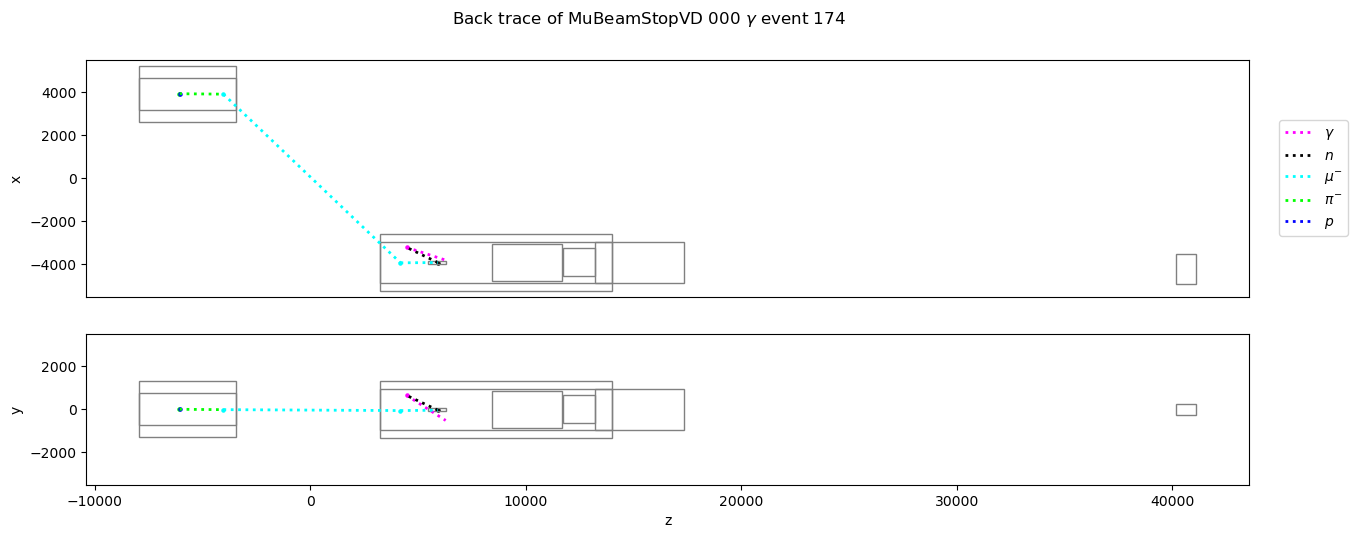

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      216.027127
creationCode                   97
index                         175
pdgId                          22
px                     -52.320068
py                    -174.087535
pz                     116.721292
startpx                400.020123
startpy               -557.286739
startpz               -496.814251
starttime              566.360229
startx               -3911.626256
starty                 954.732668
startz                6372.703758
time                   570.821755
virtualdetectorId              10
x                    -3697.863124
y                        4.994857
z                     6275.999996
weight                          1
r                      206.197382
Name: 6, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3921.209317,960.584482,6378.443597,-26.299864,565.674927,-3911.626256,954.732668,6372.703758,-26.299864,566.360229,97
1,2112,-3909.508475,-43.161802,5915.405655,30.150097,517.401855,-3921.209317,960.584482,6378.443597,30.150097,565.674927,115
2,13,-3922.119835,-58.882471,4179.000000,32.593414,154.282410,-3909.508475,-43.161802,5915.405655,0.000000,175.263504,56
3,13,3904.412216,-16.415404,-4037.639380,35.481766,4.750370,-3915.501938,-67.086106,4195.973279,32.618011,154.477615,14
4,-211,3923.209520,0.415856,-6088.707407,102.622971,-8.948345,3904.412216,-16.415404,-4037.639380,85.936234,4.750370,101
5,2212,3930.869571,0.398058,-6057.831837,-8624.851562,-9.055050,3923.209520,0.415856,-6088.707407,-8582.955078,-8.948345,56


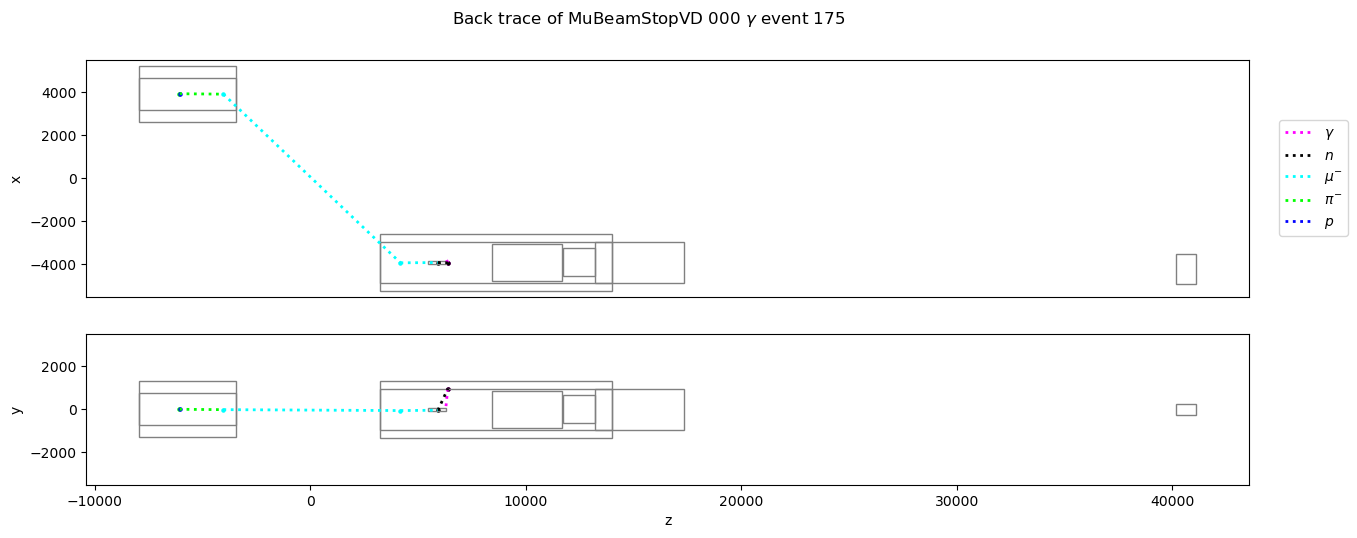

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      101.705752
creationCode                    2
index                         176
pdgId                          22
px                      11.164853
py                      -77.07241
pz                     -65.415974
startpx                 67.227401
startpy               -270.891905
startpz                -428.03964
starttime              521.337708
startx               -3634.268553
starty                 917.006759
startz                5289.383867
time                   529.905399
virtualdetectorId              10
x                    -4385.513868
y                      137.576791
z                     6276.019996
weight                          1
r                      500.782367
Name: 7, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,-11,-3635.780683,915.733603,5289.867676,-2.702569,521.328430,-3634.268553,917.006759,5289.383867,0.000000,521.337708,13
1,22,-3909.508475,-43.161802,5915.405655,-3.706436,517.401855,-3635.780683,915.733603,5289.867676,-3.706436,521.328430,115
2,13,-3922.119835,-58.882471,4179.000000,32.593414,154.282410,-3909.508475,-43.161802,5915.405655,0.000000,175.263504,56
3,13,3904.412216,-16.415404,-4037.639380,35.481766,4.750370,-3915.501938,-67.086106,4195.973279,32.618011,154.477615,14
4,-211,3923.209520,0.415856,-6088.707407,102.622971,-8.948345,3904.412216,-16.415404,-4037.639380,85.936234,4.750370,101
5,2212,3930.869571,0.398058,-6057.831837,-8624.851562,-9.055050,3923.209520,0.415856,-6088.707407,-8582.955078,-8.948345,56


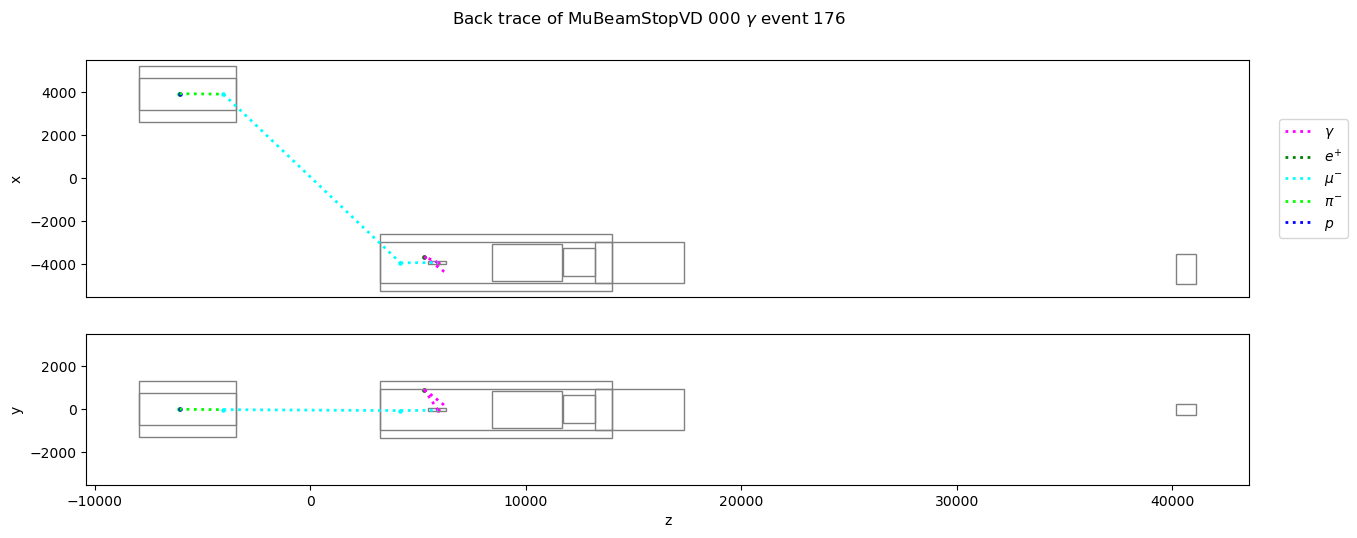

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                        8.786398
creationCode                   35
index                         216
pdgId                          22
px                       2.964655
py                       -3.28538
pz                      -7.590645
startpx                  2.964655
startpy                  -3.28538
startpz                 -7.590645
starttime            77693.835938
startx               -4490.441422
starty                 135.188752
startz                  6553.7906
time                 77694.905742
virtualdetectorId              10
x                    -4381.953393
y                       14.964184
z                     6276.019996
weight                          1
r                      478.187592
Name: 8, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3876.727394,28.348759,5693.222984,-25.180210,2191.582764,-4490.441422,135.188752,6553.790600,0.006222,77693.835938,115
1,13,-3816.992528,-31.804997,4179.000000,18.347338,294.174530,-3876.727394,28.348759,5693.222984,0.000000,323.756775,56
2,13,3935.486795,-30.413518,-3549.512944,22.938688,41.989670,-3802.656323,-24.423094,4190.709742,18.380466,294.408966,14
3,-211,3925.112319,0.139736,-6068.404730,79.633797,21.601810,3935.486795,-30.413518,-3549.512944,67.860336,41.989670,14
4,3122,3926.782174,-0.897657,-6070.083136,144.736176,21.557802,3925.112319,0.139736,-6068.404730,144.736176,21.601810,14
5,3212,3926.782174,-0.897657,-6070.083136,109.692757,21.557802,3926.782174,-0.897657,-6070.083136,109.692757,21.557802,94
6,130,3927.558356,-1.110058,-6069.854424,-60.477936,21.550932,3926.782174,-0.897657,-6070.083136,-60.477936,21.557802,101
7,2212,3930.571540,-1.093809,-6057.757530,-8624.851562,21.509117,3927.558356,-1.110058,-6069.854424,-8609.021484,21.550932,56


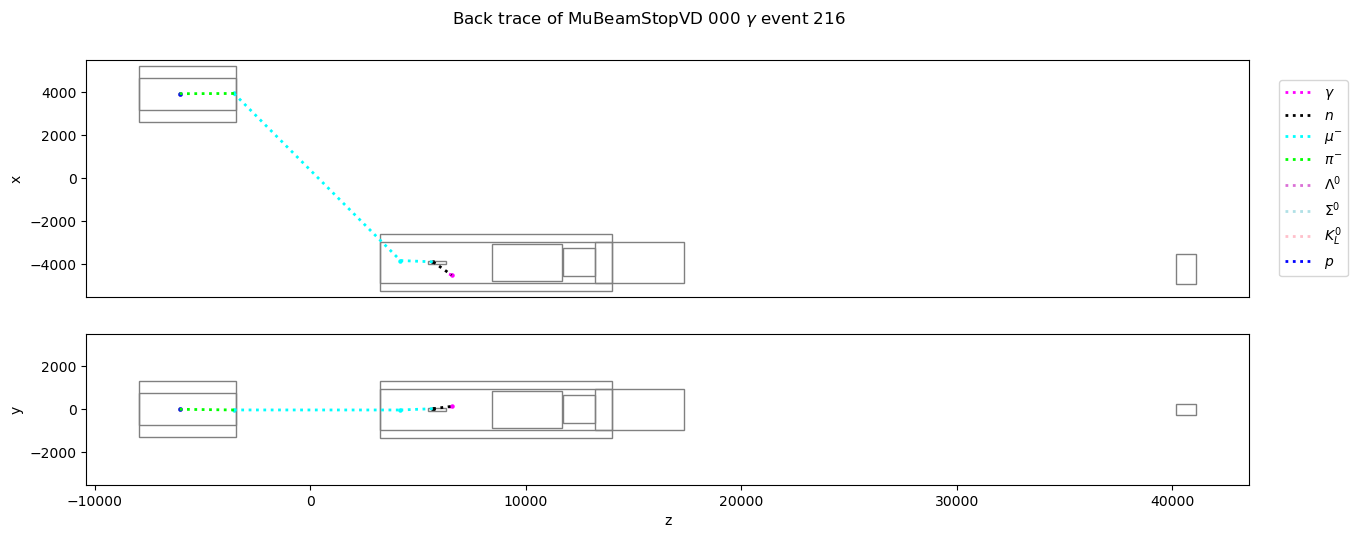

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                       90.454308
creationCode                   35
index                         217
pdgId                          22
px                      62.665058
py                     -55.324624
pz                     -34.558045
startpx                -77.125594
startpy                -75.770989
startpz                -19.380821
starttime            77693.835938
startx               -4490.441422
starty                 135.188752
startz                  6553.7906
time                 77696.295878
virtualdetectorId              10
x                    -4008.074055
y                     -317.997006
z                     6276.019996
weight                          1
r                      334.594538
Name: 9, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3876.727394,28.348759,5693.222984,-25.180210,2191.582764,-4490.441422,135.188752,6553.790600,0.006222,77693.835938,115
1,13,-3816.992528,-31.804997,4179.000000,18.347338,294.174530,-3876.727394,28.348759,5693.222984,0.000000,323.756775,56
2,13,3935.486795,-30.413518,-3549.512944,22.938688,41.989670,-3802.656323,-24.423094,4190.709742,18.380466,294.408966,14
3,-211,3925.112319,0.139736,-6068.404730,79.633797,21.601810,3935.486795,-30.413518,-3549.512944,67.860336,41.989670,14
4,3122,3926.782174,-0.897657,-6070.083136,144.736176,21.557802,3925.112319,0.139736,-6068.404730,144.736176,21.601810,14
5,3212,3926.782174,-0.897657,-6070.083136,109.692757,21.557802,3926.782174,-0.897657,-6070.083136,109.692757,21.557802,94
6,130,3927.558356,-1.110058,-6069.854424,-60.477936,21.550932,3926.782174,-0.897657,-6070.083136,-60.477936,21.557802,101
7,2212,3930.571540,-1.093809,-6057.757530,-8624.851562,21.509117,3927.558356,-1.110058,-6069.854424,-8609.021484,21.550932,56


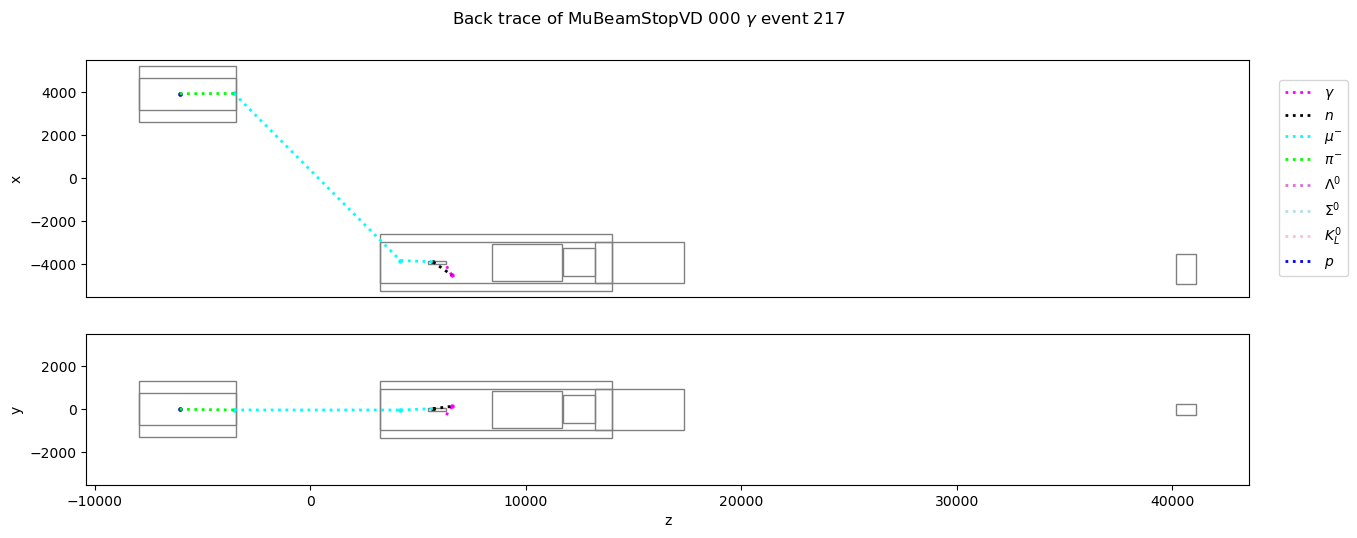

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                        1.069989
creationCode                   97
index                          42
pdgId                        2112
px                     749.191353
py                     279.352406
pz                     1171.03544
startpx               1646.388173
startpy              10804.776192
startpz              36127.609253
starttime              823.118713
startx                -4798.79777
starty                 339.623734
startz                4111.397916
time                  3692.509034
virtualdetectorId              10
x                    -3871.671034
y                       26.098355
z                     6275.999996
weight                          1
r                         41.5486
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3854.534463,27.291481,5648.795310,-41.536358,723.795715,-4798.797770,339.623734,4111.397916,-51.804226,823.118713,115
1,13,-3878.932765,22.237306,4179.000000,29.735569,110.778496,-3854.534463,27.291481,5648.795310,0.000000,129.497864,56
2,13,3948.725982,36.326045,-4168.087852,31.425934,-53.437889,-3873.916040,16.573126,4197.497182,29.731178,111.007675,14
3,-211,3916.315145,0.016561,-6125.119083,88.813545,-69.517616,3948.725982,36.326045,-4168.087852,64.797935,-53.437889,100
4,-211,3916.312259,-0.092969,-6124.623735,-1100.238037,-69.519325,3916.315145,0.016561,-6125.119083,-1098.450562,-69.517616,101
5,2212,3932.381911,-0.425008,-6058.208906,-8624.851562,-69.748535,3916.312259,-0.092969,-6124.623735,-8547.789062,-69.519325,56


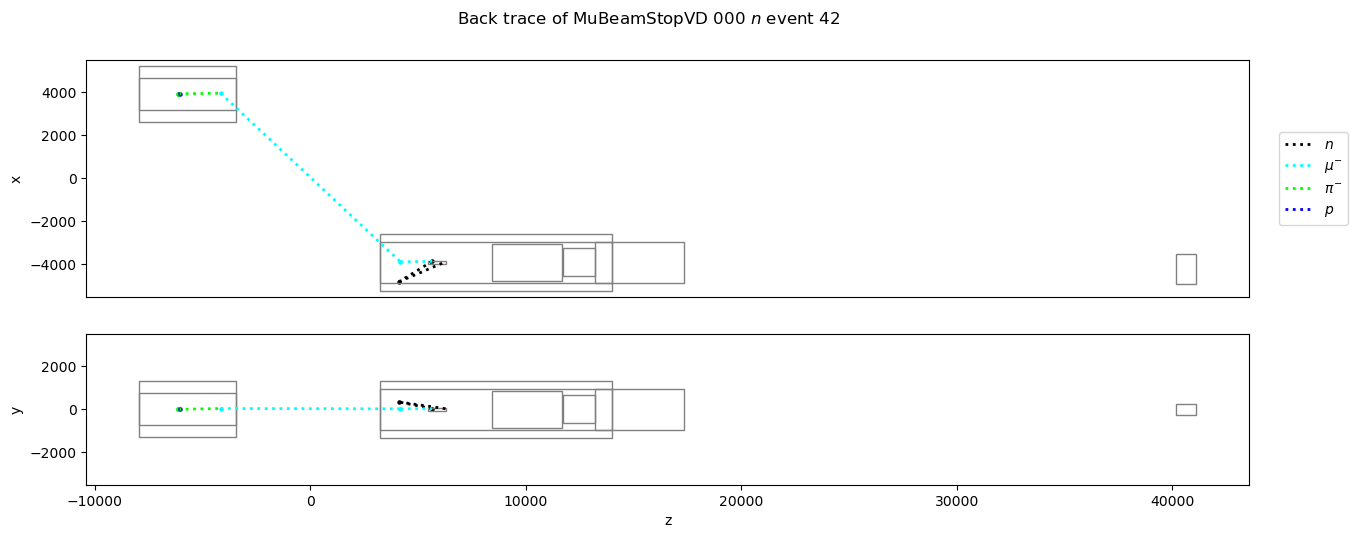

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                          0.00015
creationCode                    97
index                           44
pdgId                         2112
px                      -16.165462
py                       -0.325857
pz                        4.551787
startpx               -3019.316673
startpy               25970.003128
startpz               33585.796356
starttime               388.985565
startx                -4007.008068
starty                 -237.808749
startz                 4107.058023
time                 674090.414008
virtualdetectorId               10
x                     -3538.921351
y                      -131.258713
z                      6275.999996
weight                           1
r                       387.957819
Name: 1, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3928.575526,20.672532,5515.411173,-106.399345,346.669067,-4007.008068,-237.808749,4107.058023,-84.436241,388.985565,115
1,13,-3937.708091,35.909282,4179.000000,20.804247,277.440918,-3928.575526,20.672532,5515.411173,-0.000000,300.922791,56
2,13,3882.451796,21.054605,-4915.259390,30.641985,62.114708,-3940.715428,29.823352,4197.785349,20.819738,277.765961,14
3,-211,3911.789235,-0.862491,-6140.862508,86.524208,51.409195,3882.451796,21.054605,-4915.259390,61.165199,62.114708,99
4,211,3911.839136,-1.000690,-6140.283652,-1322.586426,51.407192,3911.789235,-0.862491,-6140.862508,-1319.786011,51.409195,101
5,2212,3932.342448,-1.259453,-6058.199067,-8624.851562,51.123379,3911.839136,-1.000690,-6140.283652,-8498.413086,51.407192,56


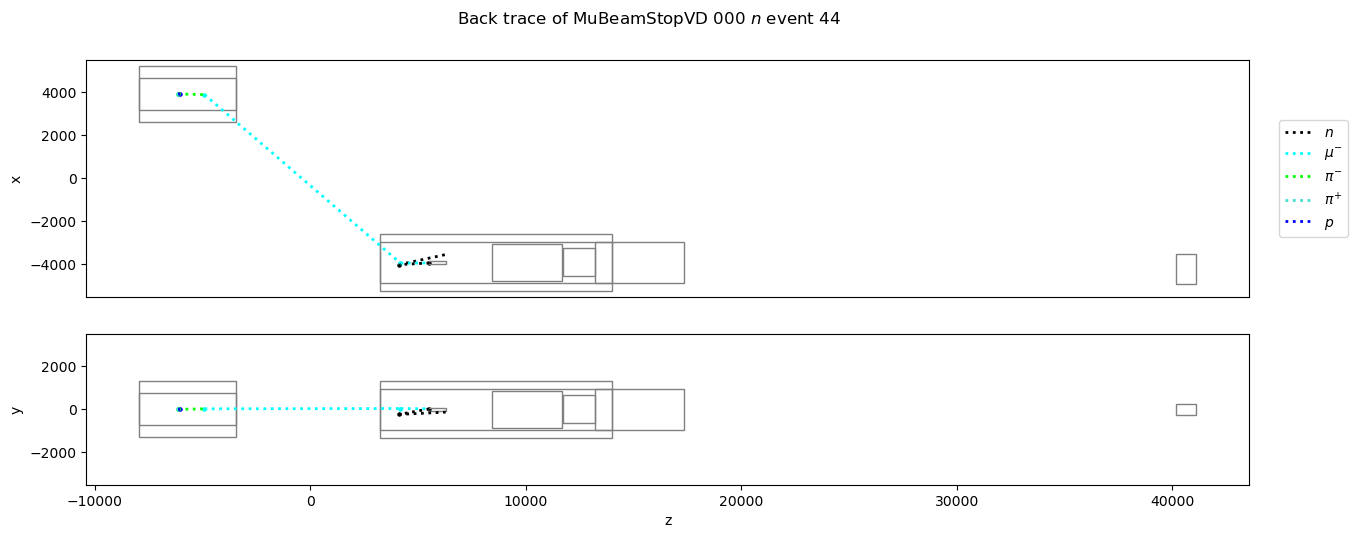

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     1054.612701
creationCode                   97
index                         165
pdgId                        2112
px                   41092.838784
py                  -11442.137034
pz                  -12779.805683
startpx              41092.838287
startpy             -11442.136765
startpz             -12779.806137
starttime             1926.552002
startx               -4830.987558
starty                 275.844606
startz                6547.713813
time                  1993.255553
virtualdetectorId              10
x                    -3957.369405
y                       32.589116
z                     6276.019996
weight                          1
r                       62.532743
Name: 2, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3952.796273,-11.443419,6026.531534,52.310989,1895.127075,-4830.987558,275.844606,6547.713813,52.310989,1926.552002,115
1,13,-3936.422582,-42.737284,4179.000000,34.626980,193.522995,-3952.796273,-11.443419,6026.531534,-0.000000,214.803680,56
2,13,3873.611511,16.488055,-5426.294512,30.288143,31.182943,-3930.463828,-34.239140,4196.075020,34.619858,193.709167,14
3,-211,3918.141773,1.154627,-6105.586032,72.914467,25.022890,3873.611511,16.488055,-5426.294512,64.684860,31.182943,101
4,2212,3930.217391,0.829775,-6057.669230,-8624.851562,24.857132,3918.141773,1.154627,-6105.586032,-8547.768555,25.022890,56


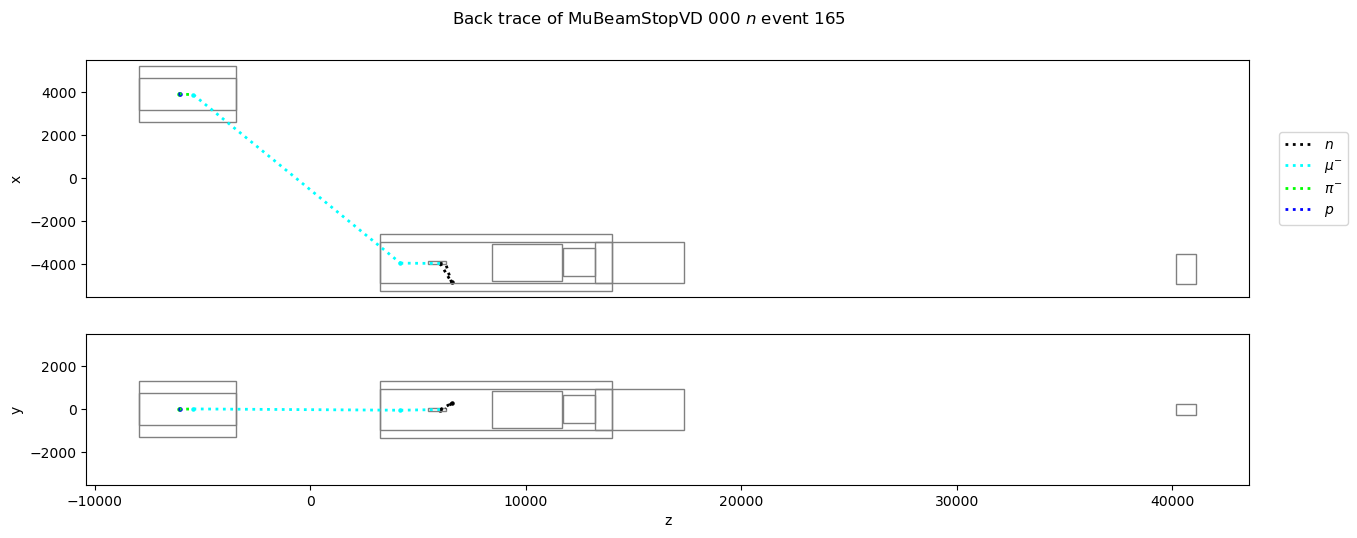

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                     2830.392046
creationCode                   97
index                         348
pdgId                        2112
px                   55400.016853
py                   40376.250555
pz                   -25045.64406
startpx              23716.262817
startpy             -17659.101486
startpz             -67622.886658
starttime              964.648071
startx               -4525.577896
starty                -731.422722
startz                6775.508587
time                  1025.723991
virtualdetectorId              10
x                    -3458.771661
y                       35.517298
z                     6276.019996
weight                          1
r                      446.642757
Name: 3, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3859.761026,24.048437,5737.633797,77.094147,922.181274,-4525.577896,-731.422722,6775.508587,77.094147,964.648071,115
1,13,-3876.457119,-17.551840,4179.000000,20.930300,299.777313,-3859.761026,24.048437,5737.633797,0.000000,328.034515,56
2,13,3801.665760,-64.882731,-2238.667328,26.081284,33.206451,-3861.671521,-12.922349,4191.554252,20.940657,299.998962,14
3,-211,3916.155748,-0.300649,-6119.612829,36.220329,-9.979511,3801.665760,-64.882731,-2238.667328,54.994823,33.206451,101
4,2212,3931.384630,-0.894139,-6057.960256,-8624.851562,-10.192545,3916.155748,-0.300649,-6119.612829,-8556.623047,-9.979511,56


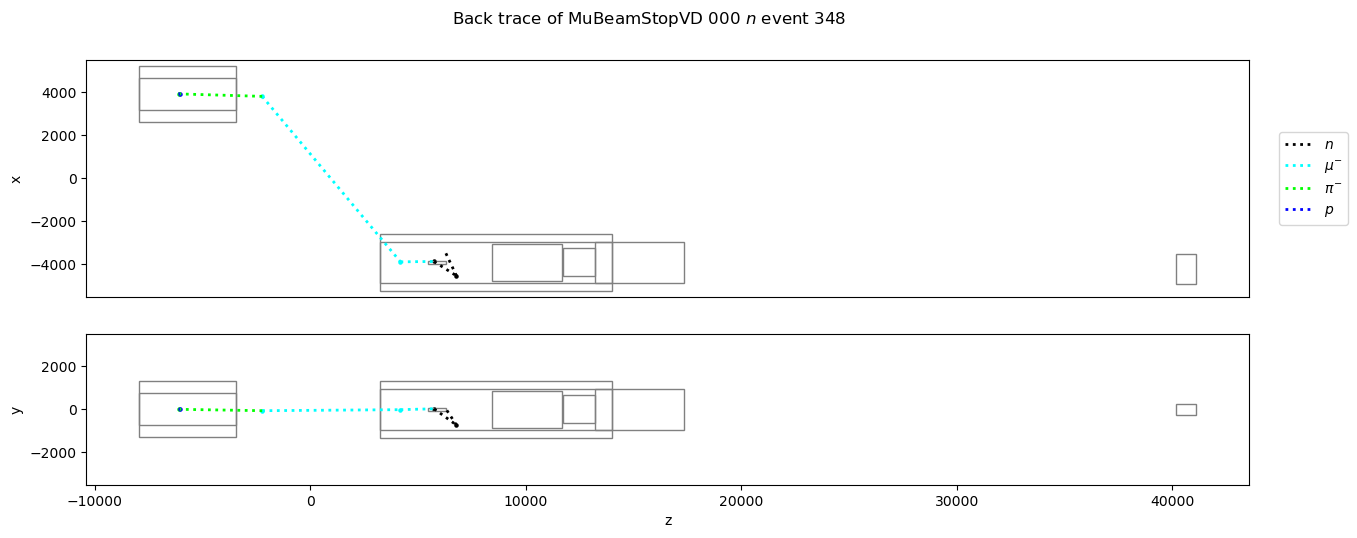

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      464.518723
creationCode                   97
index                         462
pdgId                        2112
px                  -12797.835473
py                   23819.513431
pz                  -11914.418483
startpx               3291.617632
startpy              -4363.500118
startpz              30926.845551
starttime             1132.170288
startx               -3418.312674
starty                -351.911237
startz                4693.724959
time                   1478.13534
virtualdetectorId              10
x                    -3766.885743
y                      422.968467
z                     6276.019996
weight                          1
r                      444.637654
Name: 4, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3938.136530,-29.502065,5493.264991,-41.162518,1071.202026,-3418.312674,-351.911237,4693.724959,-41.162518,1132.170288,115
1,13,-3967.366340,-1.072443,4179.000000,16.856586,258.599335,-3938.136530,-29.502065,5493.264991,0.000000,286.028198,56
2,13,3851.106822,-26.768981,-6174.330948,17.585556,-40.511894,-3966.937340,-13.493632,4194.554319,16.894005,258.930969,14
3,-211,3870.054624,-37.613120,-6241.234469,10.273434,-43.568661,3851.106822,-26.768981,-6174.330948,10.271441,-40.511894,14
4,3122,3904.004183,2.053983,-6165.060873,-533.963013,-44.182457,3870.054624,-37.613120,-6241.234469,-533.963013,-43.568661,101
5,2212,3931.272826,1.575137,-6057.932380,-8624.851562,-44.553288,3904.004183,2.053983,-6165.060873,-8467.569336,-44.182457,56


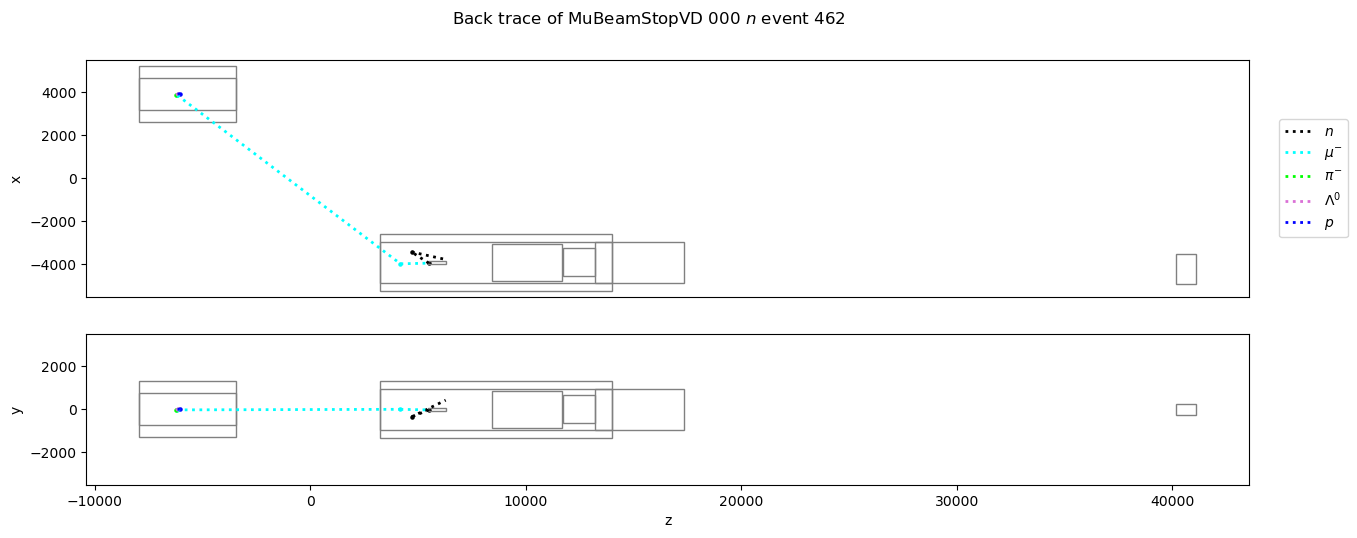

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                        0.002485
creationCode                   97
index                         463
pdgId                        2112
px                     -40.079801
py                     -14.705406
pz                      53.356055
startpx               25157.94754
startpy             -13798.991203
startpz              -29305.56488
starttime             1118.416992
startx               -2962.299489
starty                 166.941965
startz                5359.964351
time                 33834.932472
virtualdetectorId              10
x                    -3763.708409
y                      -98.306785
z                     6275.999996
weight                          1
r                       171.30661
Name: 5, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3938.136530,-29.502065,5493.264991,-8.870634,1071.202026,-2962.299489,166.941965,5359.964351,-8.870634,1118.416992,115
1,13,-3967.366340,-1.072443,4179.000000,16.856586,258.599335,-3938.136530,-29.502065,5493.264991,0.000000,286.028198,56
2,13,3851.106822,-26.768981,-6174.330948,17.585556,-40.511894,-3966.937340,-13.493632,4194.554319,16.894005,258.930969,14
3,-211,3870.054624,-37.613120,-6241.234469,10.273434,-43.568661,3851.106822,-26.768981,-6174.330948,10.271441,-40.511894,14
4,3122,3904.004183,2.053983,-6165.060873,-533.963013,-44.182457,3870.054624,-37.613120,-6241.234469,-533.963013,-43.568661,101
5,2212,3931.272826,1.575137,-6057.932380,-8624.851562,-44.553288,3904.004183,2.053983,-6165.060873,-8467.569336,-44.182457,56


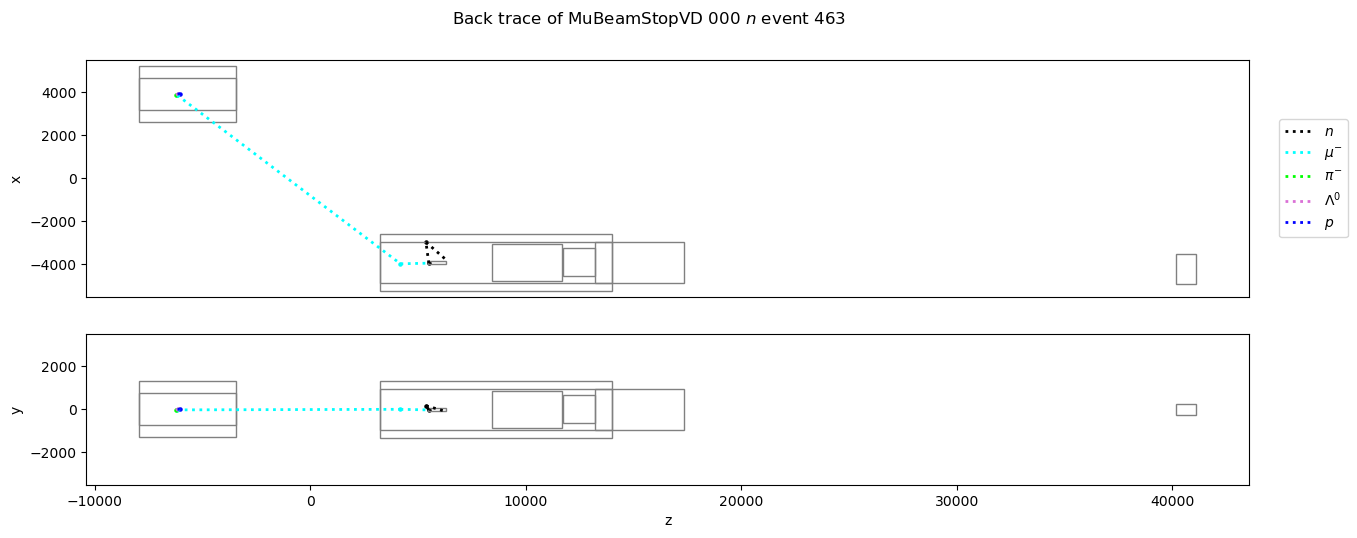

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      185.558824
creationCode                   97
index                         486
pdgId                        2112
px                   15214.189757
py                    -736.277695
pz                   10803.242323
startpx              -10002.20108
startpy             -34865.222931
startpz               9414.747238
starttime              368.354919
startx               -4610.578607
starty                 837.278093
startz                6330.167138
time                   518.446524
virtualdetectorId              10
x                    -4325.426578
y                      283.987792
z                     6275.999996
weight                          1
r                      508.182474
Name: 6, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3951.698984,11.468128,5804.301563,37.175690,323.848053,-4610.578607,837.278093,6330.167138,37.175690,368.354919,115
1,13,-3880.817286,41.882064,4179.000000,30.398882,199.911316,-3951.698984,11.468128,5804.301563,0.000000,221.038681,56
2,13,3878.875394,-15.003298,-3406.390150,30.418329,38.760197,-3887.023455,52.270117,4194.890075,30.408497,200.107224,14
3,-211,3919.075121,0.091888,-6104.752596,32.948467,17.936506,3878.875394,-15.003298,-3406.390150,75.014870,38.760197,101
4,2212,3930.659991,0.020704,-6057.779583,-8624.851562,17.774216,3919.075121,0.091888,-6104.752596,-8533.651367,17.936506,56


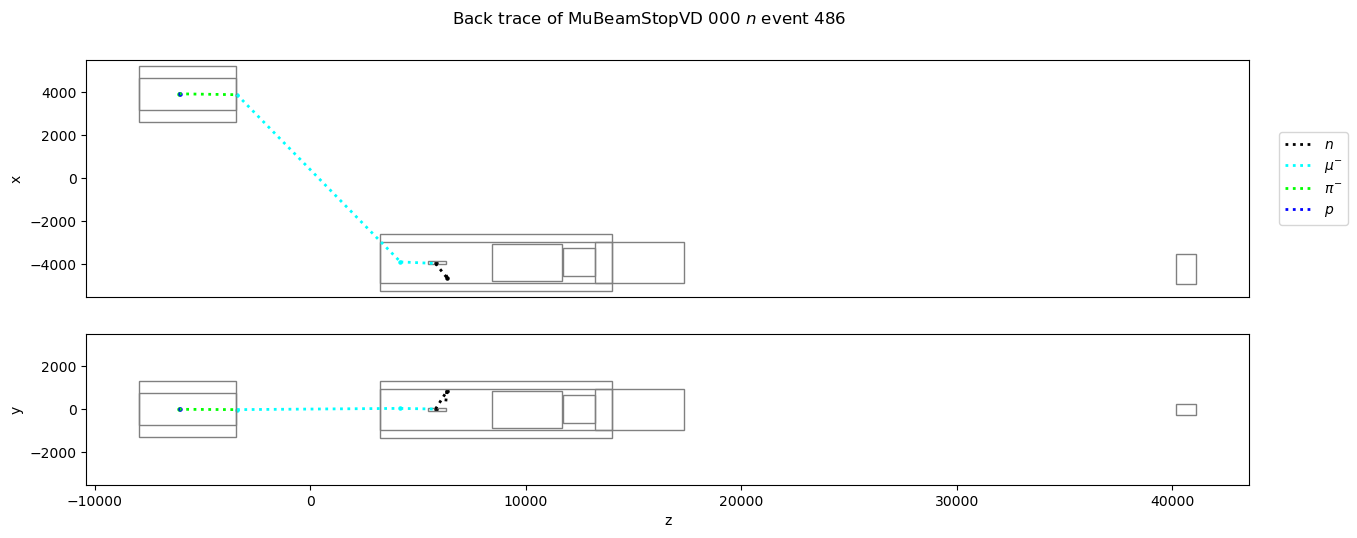

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                          0.00004
creationCode                    97
index                          537
pdgId                         2112
px                        1.593755
py                       -8.107674
pz                        2.733172
startpx              -14239.152908
startpy              -10147.045135
startpz              -48759.983063
starttime               928.683533
startx                -5140.040139
starty                  -76.306838
startz                 6315.746135
time                 230352.517942
virtualdetectorId               10
x                     -3865.814359
y                        37.273954
z                      6275.999996
weight                           1
r                        53.361885
Name: 7, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3917.162647,59.461843,5715.400387,64.424591,899.123718,-5140.040139,-76.306838,6315.746135,64.424591,928.683533,115
1,13,-3929.368540,33.242426,4179.000000,23.010302,299.086365,-3917.162647,59.461843,5715.400387,0.000000,325.177521,56
2,13,3918.212605,42.880300,-6049.209787,4.210802,37.307789,-3916.400163,35.440271,4193.999360,22.992485,299.325684,14
3,-211,3917.049059,-0.262080,-6108.314006,25.377926,34.909931,3918.212605,42.880300,-6049.209787,7.322977,37.307789,101
4,2212,3929.860791,-0.428367,-6057.580320,-8624.851562,34.734409,3917.049059,-0.262080,-6108.314006,-8539.384766,34.909931,56


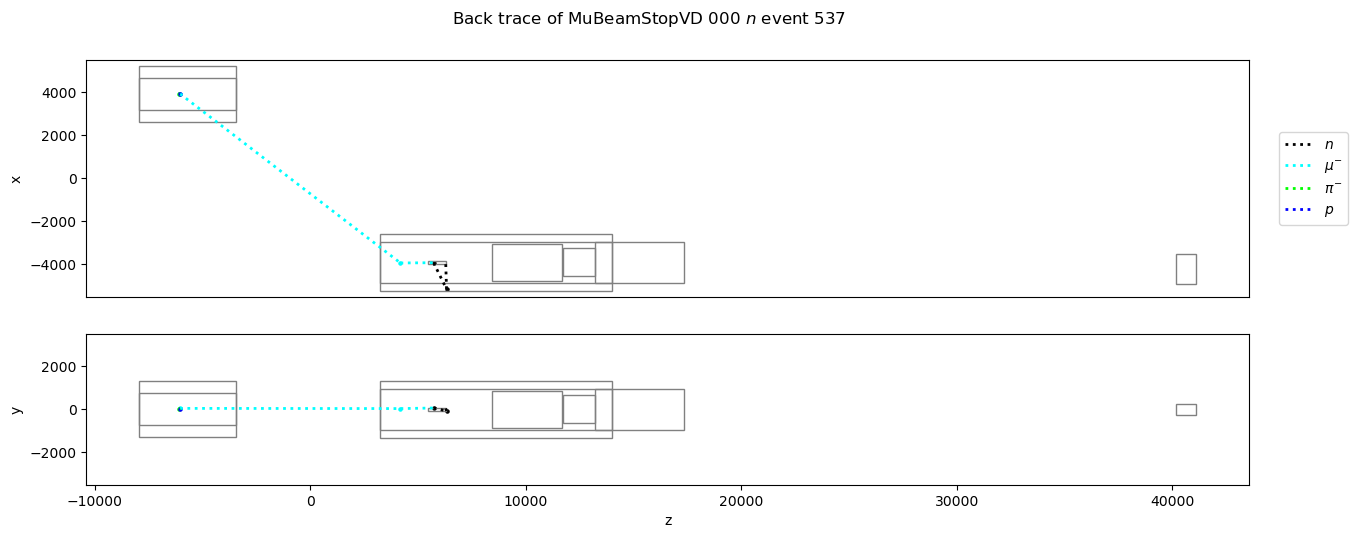

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                        4.616451
creationCode                   97
index                         641
pdgId                        2112
px                   -1435.894061
py                      40.541157
pz                    2571.283736
startpx              14241.737366
startpy              61108.089447
startpz                -888.88216
starttime             3469.372559
startx               -4733.830099
starty                 492.188977
startz                5227.717655
time                  4325.058104
virtualdetectorId              10
x                    -3680.898344
y                       -130.7907
z                     6275.999996
weight                          1
r                      258.612753
Name: 8, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3911.815236,51.069538,5515.418356,-42.796082,3448.053467,-4733.830099,492.188977,5227.717655,-42.796082,3469.372559,115
1,13,-3937.860958,2.257141,4179.000000,15.990455,409.195709,-3911.815236,51.069538,5515.418356,0.000000,438.550385,56
2,13,3934.477729,8.182116,-5674.084827,7.679485,76.030098,-3928.508108,-8.720947,4192.704650,16.011576,409.504822,14
3,-211,3907.484811,-1.537974,-6158.408992,30.453260,56.789539,3934.477729,8.182116,-5674.084827,14.027199,76.030098,100
4,-211,3913.790605,-0.836014,-6120.303412,-848.091919,56.658844,3907.484811,-1.537974,-6158.408992,-784.383850,56.789539,101
5,2212,3929.344089,-0.849146,-6057.451492,-8624.851562,56.441654,3913.790605,-0.836014,-6120.303412,-8532.767578,56.658844,56


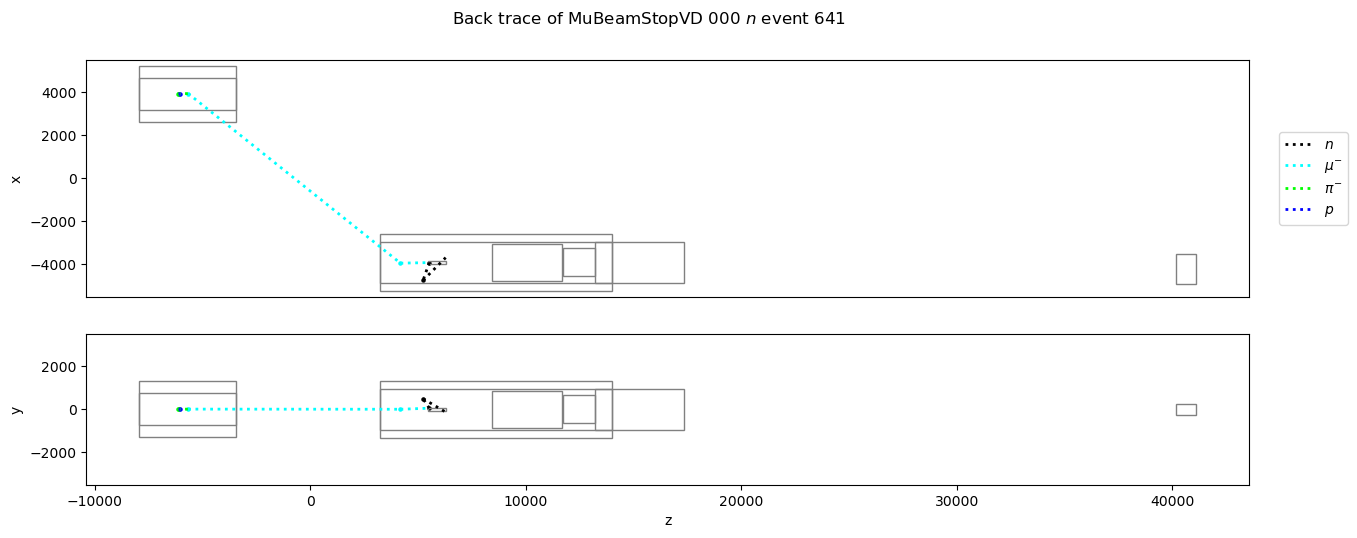

------------------------------------------------------------------------------


tag                   MuBeamStopVD
fileno                           0
E                         0.000034
creationCode                    97
index                          705
pdgId                         2112
px                        5.353816
py                        4.933889
pz                       -3.404764
startpx               11235.602379
startpy               -6317.606926
startpz               44584.472656
starttime              2311.053711
startx                 -4862.68637
starty                  -24.331348
startz                 4864.559418
time                 175108.546938
virtualdetectorId               10
x                     -4181.665323
y                      -164.478135
z                      6276.019996
weight                           1
r                       322.724478
Name: 9, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-4867.405014,-83.207603,4882.867135,-18.486652,2307.943359,-4862.686370,-24.331348,4864.559418,-18.486652,2311.053711,97
1,2112,-3869.311410,51.740965,6070.982789,-96.572540,2269.035156,-4867.405014,-83.207603,4882.867135,-96.215652,2307.943359,115
2,13,-3903.743746,46.558419,4179.000000,44.783390,114.563736,-3869.311410,51.740965,6070.982789,0.000000,132.835419,56
3,13,3514.946476,94.648890,-1452.356338,35.258907,22.535450,-3902.801388,43.356369,4198.717971,44.784294,114.732643,14
4,-211,3914.135820,0.462400,-6121.302164,99.222351,-12.833367,3514.946476,94.648890,-1452.356338,60.781338,22.535450,101
5,2212,3929.855728,0.606419,-6057.579058,-8624.851562,-13.053535,3914.135820,0.462400,-6121.302164,-8507.713867,-12.833367,56


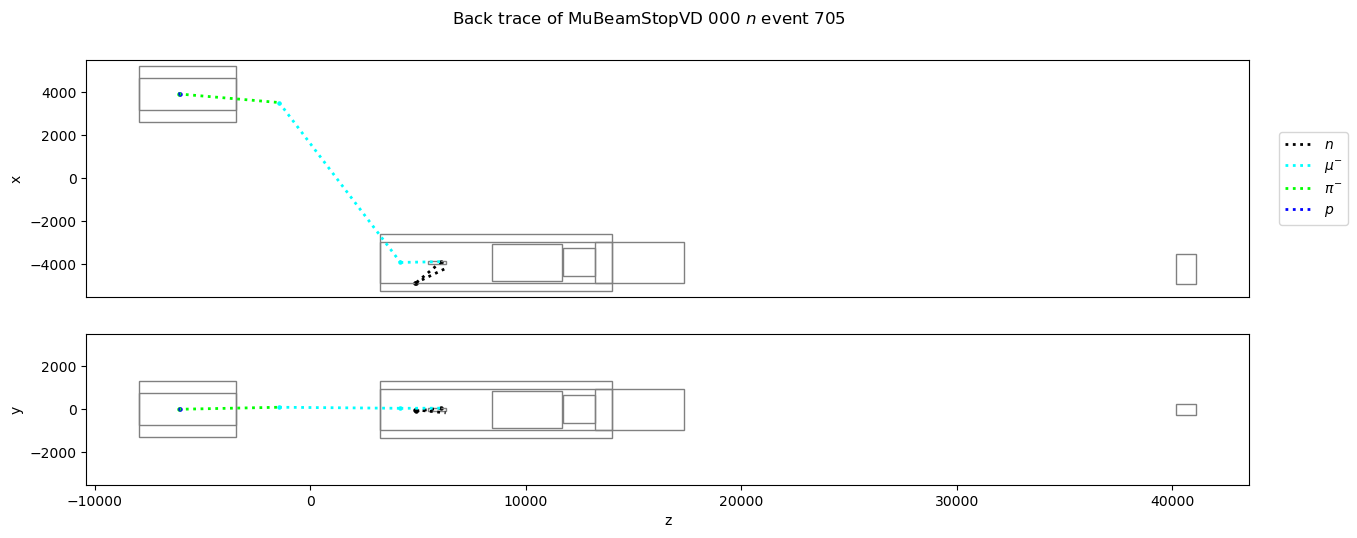

------------------------------------------------------------------------------


tag                  MuBeamStopVD
fileno                          0
E                      460.414902
creationCode                   58
index                       81840
pdgId                        2212
px                  -13348.677963
py                  -16749.319249
pz                   20136.383301
startpx              23863.868713
startpy             -23167.402267
startpz              19767.877579
starttime             4091.655762
startx               -3619.025623
starty                -134.049921
startz                4229.995282
time                  4456.804165
virtualdetectorId              10
x                    -3569.031692
y                     -226.636509
z                     6275.999996
weight                          1
r                      404.435254
Name: 0, dtype: object

,pdgId,startx,starty,startz,startpz,startGlobalTime,endx,endy,endz,endpz,endGlobalTime,creationCode
0,2112,-3663.904452,-180.729097,4160.099724,-1.432891,4079.531250,-2953.144088,-119.153400,5094.503827,0.001514,748088.875000,97
1,2112,-3699.338713,-425.567757,3983.937595,40.303612,4065.703613,-3663.904452,-180.729097,4160.099724,37.637672,4079.531250,97
2,2112,-4245.183980,1018.899920,4835.976368,-41.017162,4000.335449,-3699.338713,-425.567757,3983.937595,-41.017162,4065.703613,97
3,2112,-3870.131556,-37.044201,5870.989698,-78.490326,3958.696289,-4245.183980,1018.899920,4835.976368,-78.490326,4000.335449,115
4,13,-3868.623078,11.990828,4179.000000,24.355335,239.398117,-3870.131556,-37.044201,5870.989698,0.000000,264.872498,56
5,13,3928.798563,-3.216196,-5597.007429,12.032767,0.296824,-3882.388411,8.993238,4193.131973,24.359869,239.613205,14
6,-211,3926.922755,0.691202,-6073.425603,43.381199,-5.322889,3928.798563,-3.216196,-5597.007429,50.408215,0.296824,101
7,2212,3930.788120,0.662933,-6057.811529,-8624.851562,-5.376843,3926.922755,0.691202,-6073.425603,-8607.455078,-5.322889,56


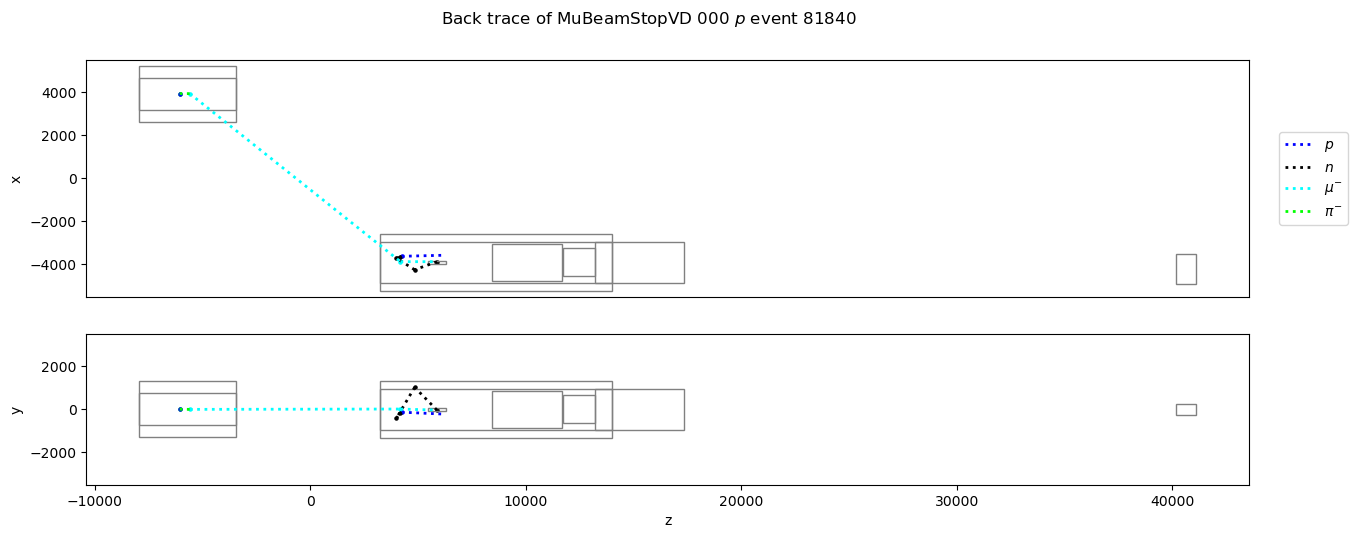

In [20]:
# looking for startz out of stopping target
for pdgId in list_of_pdgId:
    mydfp = df_by_pdgid[pdgId][0].query("startz>6300 or startz<5400").reset_index(drop=True)
    for ii in range(0, min(len(mydfp),10)):
        print('------------------------------------------------------------------------------')
        dfp_ = mydfp.iloc[ii]
        fileno, index = dfp_['fileno'], dfp_['index']

        rdfg_ = rdf_genealogy[fileno].Filter("index==%i"%index)
        dfg_ = pd.DataFrame(rdfg_.AsNumpy(columns = ["pdgId", 
                                                     "startx", "starty", "startz", "startpz", "startGlobalTime", 
                                                     "endx", "endy", "endz", "endpz", "endGlobalTime", "creationCode"]))
        
        display(dfp_)
        display(dfg_)
        fig, ax_top, ax_side = plot_utils.draw_particle_event_backtrace(dfp_, dfg_, tag, fileno, index)
        plt.show()